# Breast Cancer Survival Analysis
## METABRIC Dataset - Comprehensive Survival Analysis Pipeline

## 1. Introduction and Clinical Objective

### Clinical Context
Breast cancer is the most common cancer among women worldwide. Survival analysis is critical for understanding patient prognosis, treatment effectiveness, and identifying risk factors associated with survival outcomes.

### Dataset
The METABRIC (Molecular Taxonomy of Breast Cancer International Consortium) dataset contains clinical and molecular data from breast cancer patients, including:
- Clinical variables (age, tumor characteristics, treatment history)
- Molecular subtypes (PAM50 classification)
- Survival outcomes (overall survival and relapse-free survival)

### Clinical Objectives
1. **Prognostic Modeling**: Develop models to predict overall survival in breast cancer patients
2. **Risk Stratification**: Identify patient subgroups with distinct survival patterns
3. **Feature Importance**: Understand which clinical and molecular factors most strongly influence survival
4. **Treatment Insights**: Evaluate associations between treatment modalities and survival outcomes

### Outcome Definition
- Overall Survival (OS)
  - Duration: Time from diagnosis to death (in months)
  - Event: Death from any cause (Deceased) or censoring (Living)
  

### Clinical Relevance
- Help clinicians make informed treatment decisions
- Enable personalized risk assessment
- Support resource allocation and patient counseling
- Provide insights for clinical trial design

### Methods Overview
- Survival analysis using Kaplan-Meier estimation for descriptive statistics
- Cox proportional hazards models for multivariable analysis
- Machine learning approaches (Decision Trees, Random Forests) for prediction
- Group-aware splitting to ensure fair evaluation across patient subgroups
- Leakage controls to prevent data leakage and ensure clinically meaningful predictions


# 2. Setup and Reproducibility


Create conda environment with all necessary packages installed by running these lines on your terminal: 

```conda env create --name bc-survival --file environment.yml```

```conda activate bc-survival```

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import math
import platform, sys
import joblib
import subprocess
import random
import numpy as np
import pandas as pd
print(f"Python {platform.python_version()}")
print("pandas", pd.__version__, "numpy", np.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from utils import km_by_group


# Survival modeling
import lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter, NelsonAalenFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import restricted_mean_survival_time,  median_survival_times
from lifelines.plotting import add_at_risk_counts


# Scikit-learn core utilities
import sklearn
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibrationDisplay, calibration_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GroupShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay, 
    precision_recall_fscore_support,
    confusion_matrix,
    precision_score,
    recall_score
)



# Scikit-survival for advanced metrics
try:
    from sksurv.metrics import cumulative_dynamic_auc, integrated_brier_score, brier_score
    from sksurv.nonparametric import cumulative_incidence_competing_risks
    from sklearn.isotonic import IsotonicRegression
    from sksurv.util import Surv
    SKSURV_AVAILABLE = True
except ImportError as e:
    print("scikit-survival not available. Some time-dependent metrics will be skipped.")
    print(f"Import error: {e}")
    SKSURV_AVAILABLE = False



# Global configuration for reproducibility
RANDOM_STATE = 42
SEED = 42
np.random.seed(RANDOM_STATE)

# Matplotlib defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

# Display versions for reproducibility
def _get_ver(mod):
    return getattr(mod, "__version__", "n/a")

# print("=" * 60)
# print("ENVIRONMENT AND VERSION INFORMATION")
# print("=" * 60)
# print(f"Python              : {sys.version.split()[0]}")
# print(f"numpy               : {_get_ver(np)}")
# print(f"pandas              : {_get_ver(pd)}")
# print(f"lifelines           : {_get_ver(lifelines)}")
# print(f"scikit-learn        : {_get_ver(sklearn)}")
# print(f"scikit-survival     : {'available' if SKSURV_AVAILABLE else 'not available'}")
# print(f"Random State        : {RANDOM_STATE}")
# print("=" * 60)

# Pandas display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 50)

# Set sklearn to return DataFrames where possible
set_config(transform_output="pandas")


# 3.0 Load data, Cohort Definition, Variable Validation

## Dataset Description

The dataset includes detailed clinical, molecular, and treatment-related information for breast cancer patients.  


### Common Columns

- **Patient ID:** Unique patient identifier. *(Categorical variable)*
- **Age at Diagnosis:** Age of the patient when first diagnosed with breast cancer. *(Numerical variable)*
- **Type of Breast Surgery:** Type of breast surgery the patient underwent. *(Categorical variable)*
- **Cancer Type:** General type of cancer. *(Categorical variable)*
- **Cancer Type Detailed:** Histological subtype of the cancer. *(Categorical variable)*
- **Cellularity:** Proportion of cancer within the residual tumor bed. *(Categorical variable)*
- **Chemotherapy:** Indicates whether the patient received chemotherapy. *(Categorical variable)*
- **Pam50 + Claudin-low subtype:** Molecular classification based on the PAM50 gene signature and Claudin-low subtype. *(Categorical variable)*
- **Cohort:** Specific group or population of patients included in the study, often categorized by shared characteristics or treatment protocols. *(Numerical variable)*
- **ER Status measured by IHC:** Estrogen receptor (ER) expression status measured by immunohistochemistry. *(Categorical variable)*
- **ER Status:** Whether the tumor is positive or negative for estrogen receptors. *(Categorical variable)*
- **Neoplasm Histologic Grade:** Grade of the tumor based on how abnormal cancer cells appear under a microscope (indicator of aggressiveness). *(Numerical variable)*
- **HER2 status measured by SNP6:** HER2 receptor status measured using SNP6 technology. *(Categorical variable)*
- **HER2 Status:** Whether HER2 receptors are overexpressed in the tumor (positive/negative). *(Categorical variable)*
- **Tumor Other Histologic Subtype:** Additional histological classification of the tumor. *(Categorical variable)*
- **Hormone Therapy:** Indicates whether the patient received hormone therapy. *(Categorical variable)*
- **Inferred Menopausal State:** Patient’s menopausal status inferred from clinical data. *(Categorical variable)*
- **Integrative Cluster:** Tumor classification based on integrative molecular analysis. *(Categorical variable)*
- **Primary Tumor Laterality:** Side of the body (left/right breast) where the primary tumor is located. *(Categorical variable)*
- **Lymph nodes examined positive:** Number of lymph nodes that tested positive for cancer. *(Numerical variable)*
- **Mutation Count:** Total number of genetic mutations identified in the tumor. *(Numerical variable)*
- **Nottingham Prognostic Index:** Prognostic score assessing breast cancer outcome based on tumor histology and clinical features. *(Numerical variable)*
- **Oncotree Code:** Standardized code classifying tumor types according to the Oncotree system. *(Categorical variable)*
- **PR Status:** Progesterone receptor status of the tumor (positive/negative). *(Categorical variable)*
- **Radio Therapy:** Indicates whether the patient received radiation therapy. *(Categorical variable)*
- **Sex:** Gender of the patient. *(Categorical variable)*
- **3-Gene Classifier Subtype:** Tumor subtype based on the expression of three specific genes. *(Categorical variable)*
- **Tumor Size:** Size of the tumor (in centimeters). *(Numerical variable)*
- **Tumor Stage:** Stage of the tumor, representing the extent of cancer spread. *(Numerical variable)*



### Durations and Events (Survival Information)

- **Patient's Vital Status:** Indicates whether the patient is alive or deceased. *(Categorical variable)*
- **Relapse Free Status (Months):** Duration (in months) that a patient remained free from cancer recurrence after initial treatment. *(Numerical variable)*
- **Relapse Free Status:** Whether the patient experienced a relapse or remained cancer-free. *(Categorical variable)*
- **Overall Survival (Months):** Total number of months a patient survived after breast cancer diagnosis. *(Numerical variable)*
- **Overall Survival Status:** Indicates whether the patient is alive or deceased at the time of follow-up. *(Categorical variable)*



## 3.1 Load METABRIC Dataset

In [2]:
DATA_PATH = "data/Breast Cancer METABRIC.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Error: The data file was not found at '{DATA_PATH}'. "
    )

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()


,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,Positive,3.0,Neutral,Negative,Ductal/NST,Yes,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Ductal/NST,Yes,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,Positive,2.0,Neutral,Negative,Mixed,Yes,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,Positive,3.0,Neutral,Negative,Mixed,Yes,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


## 3.2 Define Survival Variables and Validate Outcomes

In [3]:
# Standardize survival variable names
# Primary outcome: Overall Survival (OS)
OS_DURATION_COL = "Overall Survival (Months)"
OS_STATUS_COL = "Overall Survival Status"
OS_PATIENT_ID = "Patient ID"

required_cols = [OS_DURATION_COL, OS_STATUS_COL, OS_PATIENT_ID]
missing_cols = [col for col in required_cols if col not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


# Create standardized survival variables
df = df_raw.copy()

# Convert survival status to binary event indicator
# "Deceased" = 1 (event occurred), "Living" = 0 (censored)
print("Overall Survival Status value counts:")
print(df[OS_STATUS_COL].value_counts())

# Create event indicator
df["event_os"] = (df[OS_STATUS_COL] == "Deceased").astype(int)
df["duration_os"] = df[OS_DURATION_COL].astype(float)

# Secondary outcome: Relapse-Free Survival (if available)
if "Relapse Free Status" in df.columns and "Relapse Free Status (Months)" in df.columns:
    RFS_STATUS_COL = "Relapse Free Status"
    RFS_DURATION_COL = "Relapse Free Status (Months)"
    df["event_rfs"] = (df[RFS_STATUS_COL] == "Recurred").astype(int)
    df["duration_rfs"] = df[RFS_DURATION_COL].astype(float)
    print("\nRelapse Free Status value counts:")
    print(df[RFS_STATUS_COL].value_counts())

print(f"\nSurvival variables created:")
print(f"- event_os: {df['event_os'].sum()} events out of {len(df)} patients ({df['event_os'].mean()*100:.1f}%)")
if "event_rfs" in df.columns:
    print(f"- event_rfs: {df['event_rfs'].sum()} events out of {df['duration_rfs'].notna().sum()} patients")


Overall Survival Status value counts:
Overall Survival Status
Deceased    1144
Living       837
Name: count, dtype: int64

Relapse Free Status value counts:
Relapse Free Status
Not Recurred    1486
Recurred        1002
Name: count, dtype: int64

Survival variables created:
- event_os: 1144 events out of 2509 patients (45.6%)
- event_rfs: 1002 events out of 2388 patients


## 3.3 Data Cleaning and Cohort Definition

This section removes rows with missing or invalid survival outcomes, along with removes redundant and non-predictive columns. 


In [4]:
df_raw['Sex'].unique()

array(['Female'], dtype=object)

In [5]:
df_metabric = df.copy()

# Columns to remove (redundant features and identifiers)
# NOTE: Outcome columns will be removed later in Section 4 for leakage control
columns_to_remove = [
    'Patient ID',                    # Identifier - not predictive (but keep for now, will remove in Section 4)
    'ER status measured by IHC',     # Redundant with 'ER Status'
    'HER2 status measured by SNP6',  # Redundant with 'HER2 Status'
    'Sex',                           # Not informative in breast cancer cohort
    'Cancer Type',
    'Cancer Type Detailed',          # Redundant with 'Cancer Type'
    'Tumor Other Histologic Subtype', # High cardinality, redundant information, 
    'Primary Tumor Laterality'
]

# Create df_metabric2 by dropping the specified columns
columns_to_remove_no_id = [col for col in columns_to_remove if col != 'Patient ID']
df_metabric2 = df_metabric.drop(columns=columns_to_remove_no_id)

columns_removed = [col for col in columns_to_remove_no_id if col in df_metabric.columns]
columns_not_found = [col for col in columns_to_remove_no_id if col not in df_metabric.columns]

print(f"\nColumns to remove: {len(columns_to_remove_no_id)}")
print(f"Columns found and removed: {len(columns_removed)}")
if columns_not_found:
    print(f"Columns not found in dataset: {len(columns_not_found)}")
    for col in columns_not_found:
        print(f"  - {col} (may have been removed earlier)")

if columns_removed:
    print(f"\nRemoved {len(columns_removed)} columns:")
    for col in columns_removed:
        n_unique = df_metabric[col].nunique()
        n_missing = df_metabric[col].isnull().sum()
        print(f"  - {col:40s} ({n_unique} unique values, {n_missing} missing)")
    
    # Store shapes
    n_cols_before = len(df_metabric.columns)
    n_cols_after = len(df_metabric2.columns)
    n_rows = len(df_metabric2)
    
    print(f"\n✓ Removed {n_cols_before - n_cols_after} columns")
    print(f"  df_metabric:  {n_cols_before} columns, {len(df_metabric)} rows")
    print(f"  df_metabric2: {n_cols_after} columns, {n_rows} rows")
    
    # Verify survival variables still present
    if 'event_os' in df_metabric2.columns and 'duration_os' in df_metabric2.columns:
        print(f"\n✓ Survival variables (event_os, duration_os) preserved in df_metabric2")
    else:
        print(f"\n WARNING: Survival variables may have been removed!")
    
    if 'Patient ID' in df_metabric2.columns:
        print(f"\n✓ Patient ID preserved (will be removed in Section 4 for leakage control)")
else:
    print("\n✓ No columns to remove (all specified columns were already removed or not present)")
    df_metabric2 = df_metabric.copy()

# Update df to use df_metabric2 for consistency in rest of notebook
df = df_metabric2.copy()



Columns to remove: 7
Columns found and removed: 7

Removed 7 columns:
  - ER status measured by IHC                (2 unique values, 83 missing)
  - HER2 status measured by SNP6             (4 unique values, 529 missing)
  - Sex                                      (1 unique values, 0 missing)
  - Cancer Type                              (2 unique values, 0 missing)
  - Cancer Type Detailed                     (8 unique values, 0 missing)
  - Tumor Other Histologic Subtype           (8 unique values, 135 missing)
  - Primary Tumor Laterality                 (2 unique values, 639 missing)

✓ Removed 7 columns
  df_metabric:  38 columns, 2509 rows
  df_metabric2: 31 columns, 2509 rows

✓ Survival variables (event_os, duration_os) preserved in df_metabric2

✓ Patient ID preserved (will be removed in Section 4 for leakage control)


In [6]:
# Keep track of original size
n_original = len(df)

# Remove rows with missing survival outcomes (cannot analyze without outcome)
print("Removing rows with missing survival outcomes...")
df = df.dropna(subset=["duration_os", "event_os"]).copy()
print(f"  Removed {n_original - len(df)} rows with missing outcomes")

# Remove rows with non-positive survival times (must be > 0)
n_before = len(df)
df = df[df["duration_os"] > 0].copy()
if len(df) < n_before:
    print(f"  Removed {n_before - len(df)} rows with non-positive survival times")

# Validate event indicator is binary
assert df["event_os"].isin([0, 1]).all(), "Event indicator must be 0 or 1"

print("\n" + "="*60)
print("SURVIVAL OUTCOME SUMMARY")
print("="*60)
print(f"Duration (months) - Median: {df['duration_os'].median():.1f}, Mean: {df['duration_os'].mean():.1f}")
print(f"Duration (months) - Min: {df['duration_os'].min():.1f}, Max: {df['duration_os'].max():.1f}")
print(f"IQR: [{df['duration_os'].quantile(0.25):.1f}, {df['duration_os'].quantile(0.75):.1f}]")
print(f"Events: {df['event_os'].sum()} ({df['event_os'].mean()*100:.1f}%)")
print(f"Censored: {(df['event_os']==0).sum()} ({(df['event_os']==0).mean()*100:.1f}%)")


Removing rows with missing survival outcomes...
  Removed 528 rows with missing outcomes
  Removed 1 rows with non-positive survival times

SURVIVAL OUTCOME SUMMARY
Duration (months) - Median: 116.5, Mean: 125.3
Duration (months) - Min: 0.1, Max: 355.2
IQR: [60.9, 185.1]
Events: 1144 (57.8%)
Censored: 836 (42.2%)


# 4.0 Preprocessing, Group-Aware Data Splitting for Modeling, Pipeline Creation


- **Leakage control**: Remove outcome columns and identifiers from features
- **Train/validation/test splits**: Create stratified splits (60/20/20) for model evaluation
- **Preprocessing pipeline**: Build and fit preprocessing (imputation, encoding, scaling) on training data only
- **Data transformation**: Apply preprocessing to all splits without leakage



## 4.1 Leakage Control Strategy

**Leakage controls implemented:**


**Variables to EXCLUDE:**
- `Patient ID` (identifier, may use for grouping)
- `Overall Survival (Months)` (direct outcome)
- `Overall Survival Status` (direct outcome)
- `Relapse Free Status (Months)` (if using OS as outcome)
- `Relapse Free Status` (if using OS as outcome)
- `Patient's Vital Status` (likely redundant with OS status)
- Any variables derived from outcomes or measured post-treatment


In [7]:
# Columns that directly contain outcome information (LEAKAGE)
OUTCOME_COLS = [
    "Overall Survival (Months)",
    "Overall Survival Status", 
    "Relapse Free Status (Months)",
    "Relapse Free Status",
    "Patient's Vital Status"
]

# Standardized outcome columns we created (also need to be excluded!)
STANDARDIZED_OUTCOME_COLS = [
    "duration_os",      # Duration for Overall Survival - OUTCOME!
    "duration_rfs",     # Duration for Relapse-Free Survival - OUTCOME!
    "event_os",         # Event indicator for OS - OUTCOME! (but we keep it in y)
    "event_rfs"         # Event indicator for RFS - OUTCOME!
]

# Identifier column (keep for grouping but exclude from features)
ID_COL = "Patient ID"

# Combine all columns to drop (original + standardized outcome columns)
cols_to_drop = []
cols_to_drop.extend([col for col in OUTCOME_COLS + [ID_COL] if col in df.columns])
cols_to_drop.extend([col for col in STANDARDIZED_OUTCOME_COLS if col in df.columns])

print("Columns to exclude from features (leakage control):")
print("\nOriginal outcome columns:")
for col in OUTCOME_COLS:
    if col in df.columns:
        print(f"  - {col}")

print("\nStandardized outcome columns (created in cell 7):")
for col in STANDARDIZED_OUTCOME_COLS:
    if col in df.columns:
        print(f"  - {col}")

if ID_COL in df.columns:
    print(f"\nIdentifier column:")
    print(f"  - {ID_COL}")

# Create X (features) and y (outcome) dataframes
# Note: event_os and duration_os are kept in y but removed from X
X = df.drop(columns=cols_to_drop, errors='ignore').copy()
y_cols_to_keep = []
if "duration_os" in df.columns: y_cols_to_keep.extend(["duration_os", "event_os"])
if "duration_rfs" in df.columns: y_cols_to_keep.extend(["duration_rfs", "event_rfs"])
# y = df[["duration_os", "event_os"]].copy()
y = df[y_cols_to_keep].copy()


print(f"\n✓ Removed {len(cols_to_drop)} outcome/identifier columns from features")

# Also store patient IDs for group-aware splitting if needed
patient_ids = df[ID_COL].values if ID_COL in df.columns else None

print(f"\nFeature matrix shape: {X.shape}")
print(f"Outcome matrix shape: {y.shape}")



Columns to exclude from features (leakage control):

Original outcome columns:
  - Overall Survival (Months)
  - Overall Survival Status
  - Relapse Free Status (Months)
  - Relapse Free Status
  - Patient's Vital Status

Standardized outcome columns (created in cell 7):
  - duration_os
  - duration_rfs
  - event_os
  - event_rfs

Identifier column:
  - Patient ID

✓ Removed 10 outcome/identifier columns from features

Feature matrix shape: (1980, 21)
Outcome matrix shape: (1980, 4)


## 4.2 Create stratified train, validation, and test splits 

In [8]:
def make_splits(X: pd.DataFrame, y: pd.Series, seed: int = 42):
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    train_val_idx, test_idx = next(sss1.split(X, y))
    X_train_val, X_test = X.iloc[train_val_idx], X.iloc[test_idx]
    y_train_val, y_test = y.iloc[train_val_idx], y.iloc[test_idx]

    # Split train vs validation 75:25 within the remaining 80 percent to yield 60:20:20 overall
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, val_idx = next(sss2.split(X_train_val, y_train_val))

    idx_train = X_train_val.index[train_idx]
    idx_val = X_train_val.index[val_idx]
    idx_test = X_test.index

    return idx_train, idx_val, idx_test

# Create splits using event_os for stratification
idx_train, idx_val, idx_test = make_splits(X, y["event_os"], seed=SEED)

print("Split sizes",
      "train", len(idx_train),
      "val", len(idx_val),
      "test", len(idx_test))

# Materialize split datasets
X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

# Display split information
print(f"Train set:      {len(X_train):4d} samples ({len(X_train)/len(X)*100:5.1f}%)")
print(f"Validation set: {len(X_val):4d} samples ({len(X_val)/len(X)*100:5.1f}%)")
print(f"Test set:       {len(X_test):4d} samples ({len(X_test)/len(X)*100:5.1f}%)")
print(f"Total:          {len(X):4d} samples")

print("\n" + "="*60)
print("EVENT RATES ACROSS SPLITS")
print("="*60)
event_rate_train = y_train["event_os"].mean()
event_rate_val = y_val["event_os"].mean()
event_rate_test = y_test["event_os"].mean()
print(f"Train:      {event_rate_train*100:5.1f}% ({y_train['event_os'].sum():3d} events)")
print(f"Validation: {event_rate_val*100:5.1f}% ({y_val['event_os'].sum():3d} events)")
print(f"Test:       {event_rate_test*100:5.1f}% ({y_test['event_os'].sum():3d} events)")


Split sizes train 1188 val 396 test 396
Train set:      1188 samples ( 60.0%)
Validation set:  396 samples ( 20.0%)
Test set:        396 samples ( 20.0%)
Total:          1980 samples

EVENT RATES ACROSS SPLITS
Train:       57.7% (686 events)
Validation:  57.8% (229 events)
Test:        57.8% (229 events)


## 4.3 Feature Type Detection and Preprocessing Pipeline

1. **Feature Type Detection**
   - Automatically identifies which features are categorical (discrete categories) vs numeric (continuous numbers)
   - Categorical features: text/object types or integers with few unique values
   - Numeric features: continuous variables like age, tumor size, mutation count

2. **Preprocessing Pipeline Construction**
   - Creates separate transformation pipelines for categorical and numeric features
   - **Numeric pipeline**: Imputes missing values with median → Standardizes (z-score normalization)
   - **Categorical pipeline**: Imputes missing values with most frequent category → One-hot encodes

3. **Leakage Prevention**
   - Pipeline is fitted on training data
   - Validation and test sets are transformed using parameters learned from training


In [9]:
# Feature Type Detection and Preprocessing Pipeline

def detect_feature_types(X):
    # Identify categorical columns (object type or with few unique values)
    cat_cols = []
    num_cols = []
    
    for col in X.columns:
        if X[col].dtype == 'object':
            cat_cols.append(col)
        elif X[col].dtype in ['int64', 'float64']:
            # Consider low-cardinality integer columns as categorical if they have few unique values
            n_unique = X[col].nunique()
            if n_unique <= 10 and n_unique < len(X) * 0.05:  # Less than 5% unique values
                cat_cols.append(col)
            else:
                num_cols.append(col)
        else:
            # Default to numeric for other types
            num_cols.append(col)
    
    return cat_cols, num_cols


# Detect feature types from training data
cat_cols, num_cols = detect_feature_types(X_train)

print("="*60)
print("FEATURE TYPE DETECTION")
print("="*60)
print(f"Categorical features: {len(cat_cols)}")
print(f"Numeric features:     {len(num_cols)}")

if len(cat_cols) > 0:
    print(f"\nCategorical features (first 10):")
    for col in cat_cols[:10]:
        n_unique = X_train[col].nunique()
        n_missing = X_train[col].isnull().sum()
        print(f"  {col:40s} - {n_unique:3d} unique values, {n_missing:4d} missing")

if len(num_cols) > 0:
    print(f"\nNumeric features (first 10):")
    for col in num_cols[:10]:
        n_missing = X_train[col].isnull().sum()
        mean_val = X_train[col].mean()
        print(f"  {col:40s} - {n_missing:4d} missing, mean={mean_val:.2f}")



# Build Consolidated Preprocessing Pipeline

# Numeric feature pipeline
# - Impute missing values with median (fit on train only)
# - Standardize to zero mean and unit variance (fit on train only)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical feature pipeline
# - Impute missing values with most frequent category (fit on train only)
# - One-hot encode (fit on train only, ignore unknown categories at transform time)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False))
])

# Combined preprocessor
# This ensures all transformations are fit on training data only
# and applied consistently to validation and test sets
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop',  # Drop any columns not explicitly handled
    verbose_feature_names_out=False  # Keep original feature names where possible
)


# Fit preprocessor on training data only
preprocessor.fit(X_train)

# Transform all splits
X_train_transformed = preprocessor.transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

print(f"\nTransformed feature dimensions:")
print(f"  Train:      {X_train_transformed.shape}")
print(f"  Validation: {X_val_transformed.shape}")
print(f"  Test:       {X_test_transformed.shape}")

# Create transformed DataFrames for convenience
# Convert to DataFrame if not already (when set_config is used)
if hasattr(X_train_transformed, 'columns'):
    Xt_train = X_train_transformed
    Xt_val = X_val_transformed
    Xt_test = X_test_transformed
else:
    # Convert numpy arrays to DataFrames with feature names
    try:
        feature_names = preprocessor.get_feature_names_out()
        Xt_train = pd.DataFrame(X_train_transformed, 
                                index=X_train.index, 
                                columns=feature_names)
        Xt_val = pd.DataFrame(X_val_transformed, 
                             index=X_val.index, 
                             columns=feature_names)
        Xt_test = pd.DataFrame(X_test_transformed, 
                               index=X_test.index, 
                               columns=feature_names)
    except:
        # Fallback if feature names not available
        Xt_train = pd.DataFrame(X_train_transformed, index=X_train.index)
        Xt_val = pd.DataFrame(X_val_transformed, index=X_val.index)
        Xt_test = pd.DataFrame(X_test_transformed, index=X_test.index)

print(f"Transformed DataFrames created:")
print(f"  Xt_train: {Xt_train.shape}")
print(f"  Xt_val:   {Xt_val.shape}")
print(f"  Xt_test:  {Xt_test.shape}")



FEATURE TYPE DETECTION
Categorical features: 16
Numeric features:     5

Categorical features (first 10):
  Type of Breast Surgery                   -   2 unique values,   16 missing
  Cellularity                              -   3 unique values,   36 missing
  Chemotherapy                             -   2 unique values,    1 missing
  Pam50 + Claudin-low subtype              -   7 unique values,    1 missing
  Cohort                                   -   5 unique values,    0 missing
  ER Status                                -   2 unique values,    0 missing
  Neoplasm Histologic Grade                -   3 unique values,   50 missing
  HER2 Status                              -   2 unique values,    1 missing
  Hormone Therapy                          -   2 unique values,    1 missing
  Inferred Menopausal State                -   2 unique values,    1 missing

Numeric features (first 10):
  Age at Diagnosis                         -    0 missing, mean=60.99
  Lymph nodes examined p

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1980 entries, 0 to 1984
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Patient ID                     1980 non-null   object 
 1   Age at Diagnosis               1980 non-null   float64
 2   Type of Breast Surgery         1955 non-null   object 
 3   Cellularity                    1916 non-null   object 
 4   Chemotherapy                   1979 non-null   object 
 5   Pam50 + Claudin-low subtype    1979 non-null   object 
 6   Cohort                         1980 non-null   float64
 7   ER Status                      1980 non-null   object 
 8   Neoplasm Histologic Grade      1893 non-null   float64
 9   HER2 Status                    1979 non-null   object 
 10  Hormone Therapy                1979 non-null   object 
 11  Inferred Menopausal State      1979 non-null   object 
 12  Integrative Cluster            1979 non-null   object

# 5.0 Exploratory Data Analysis 

### 5.1 Data Distribution Analysis


Feature types:
  Numeric features: 8
  Categorical features: 15

NUMERIC FEATURE DISTRIBUTIONS


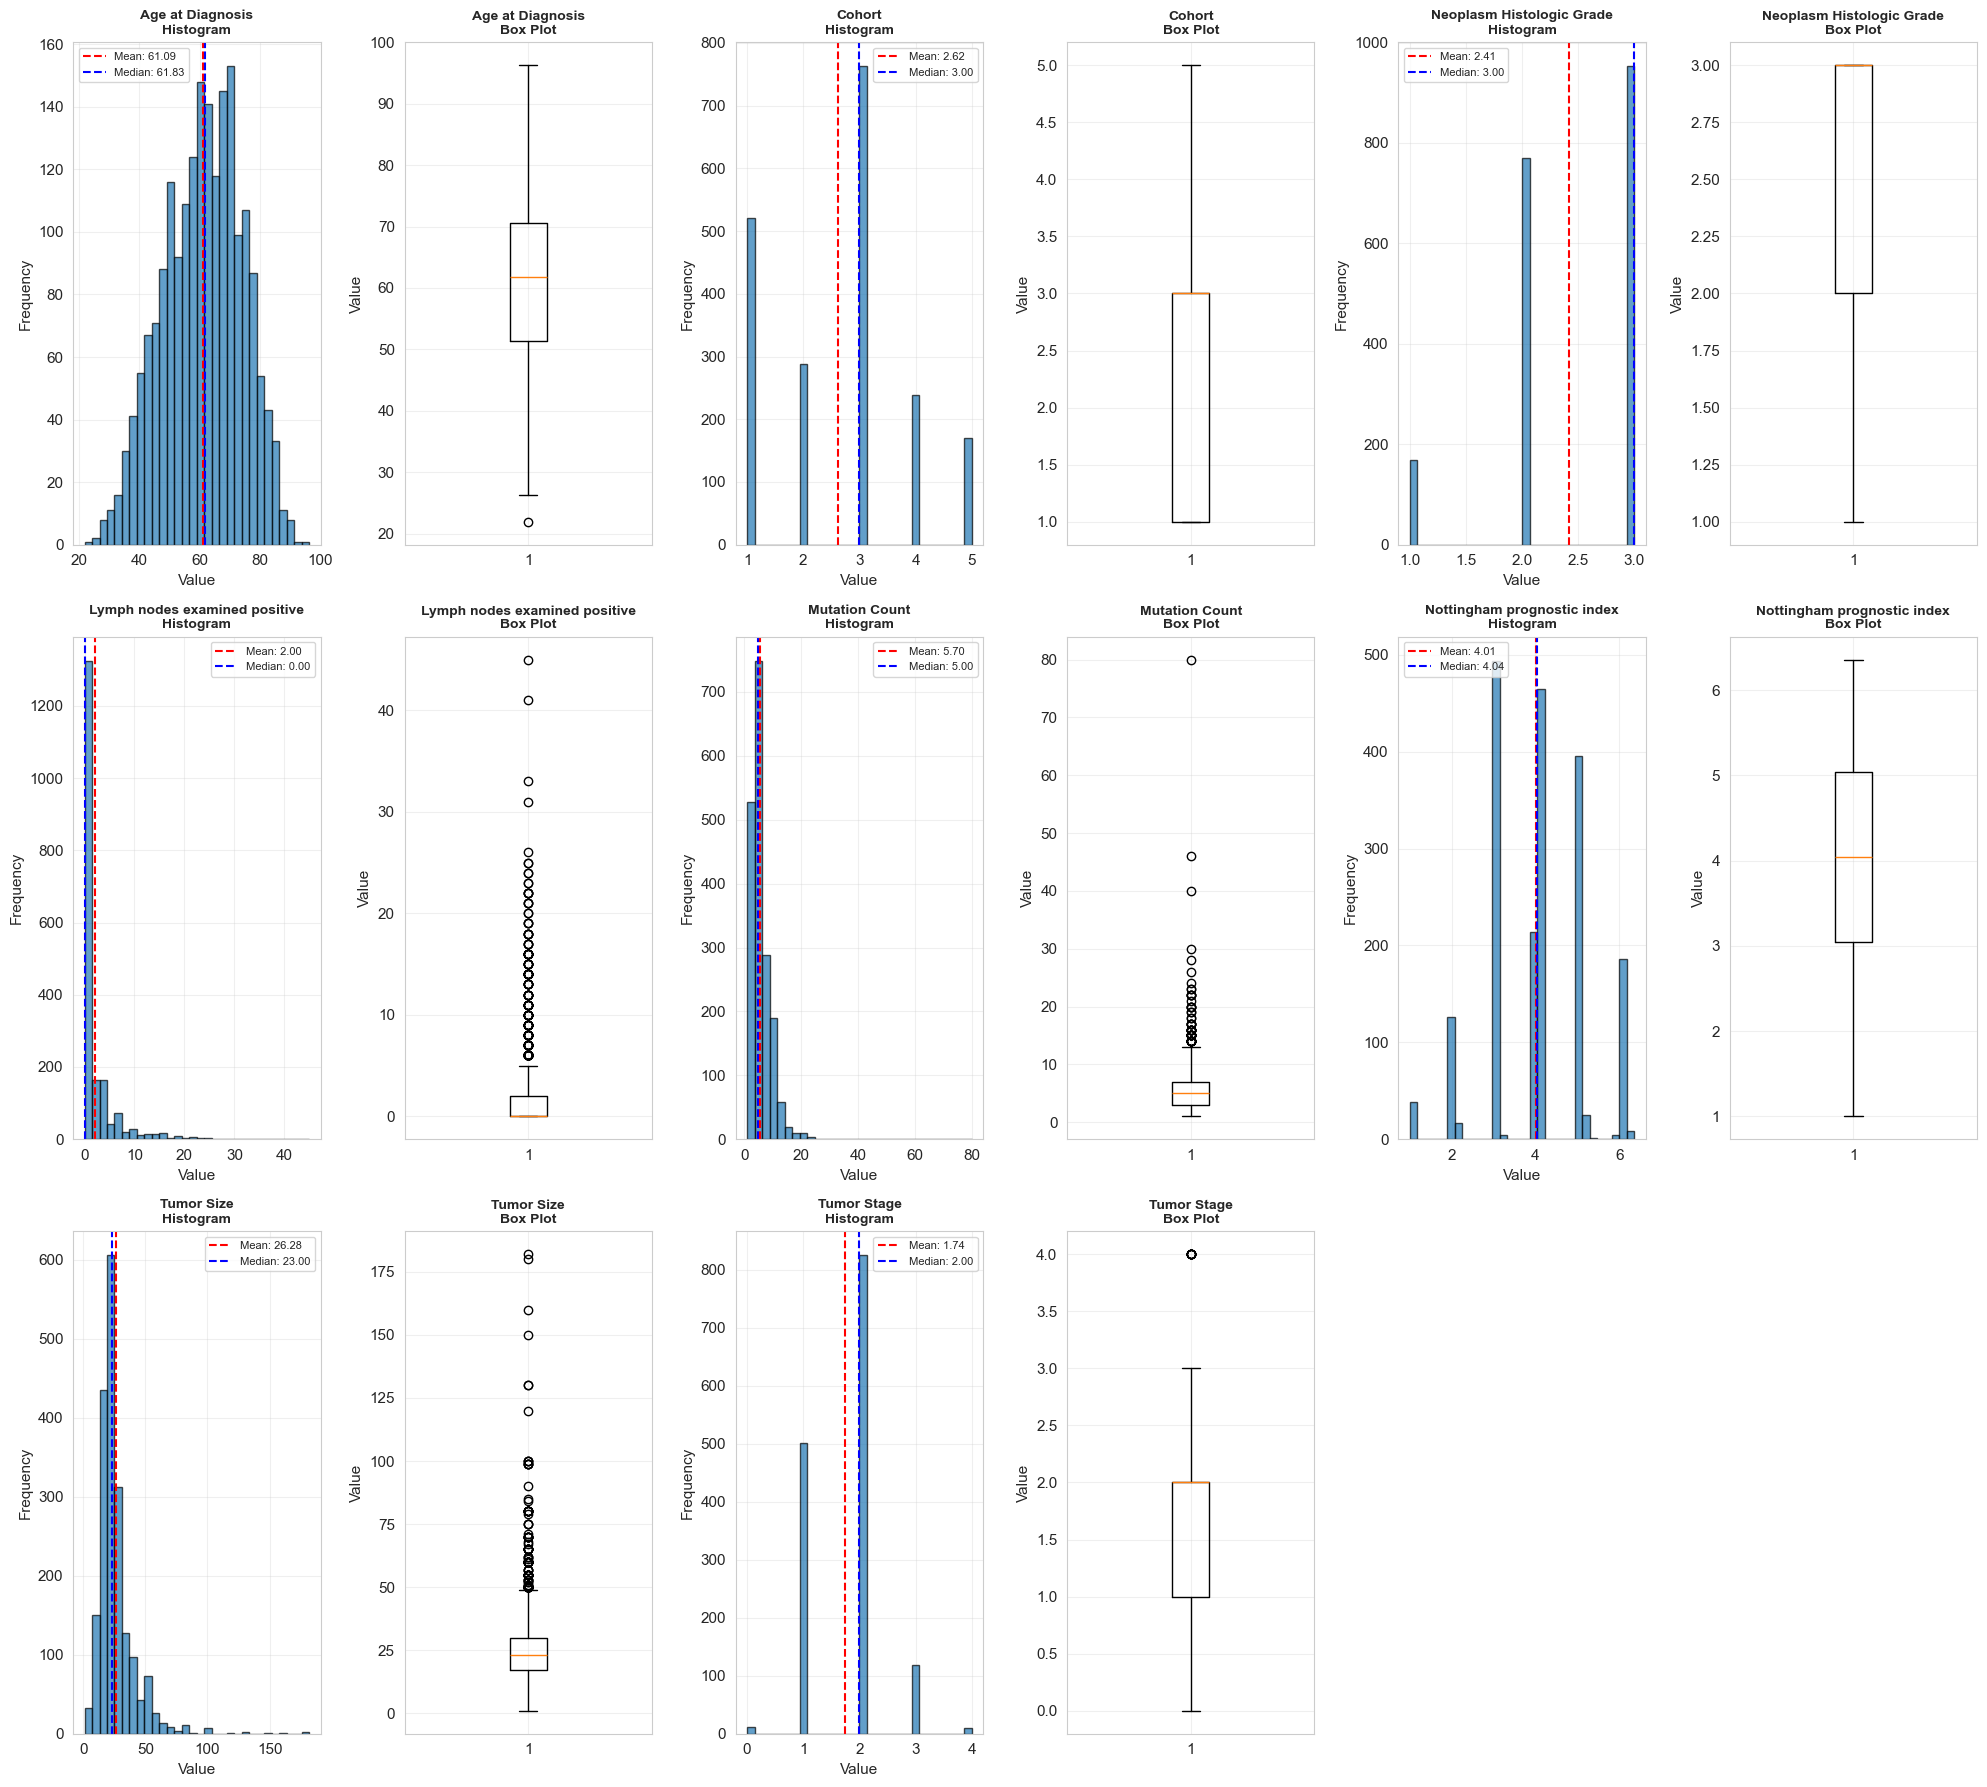


Summary Statistics for Numeric Features:
                                count       mean        std    min      25%     50%      75%     max
Age at Diagnosis               1980.0  61.091869  12.951157  21.93  51.4425  61.825  70.6025   96.29
Cohort                         1980.0   2.620202   1.232127   1.00   1.0000   3.000   3.0000    5.00
Neoplasm Histologic Grade      1893.0   2.414157   0.649158   1.00   2.0000   3.000   3.0000    3.00
Lymph nodes examined positive  1904.0   2.002101   4.079993   0.00   0.0000   0.000   2.0000   45.00
Mutation Count                 1859.0   5.699839   4.057877   1.00   3.0000   5.000   7.0000   80.00
Nottingham prognostic index    1979.0   4.012482   1.160818   1.00   3.0440   4.042   5.0400    6.36
Tumor Size                     1955.0  26.275581  15.379858   1.00  17.0000  23.000  30.0000  182.00
Tumor Stage                    1466.0   1.736016   0.642541   0.00   1.0000   2.000   2.0000    4.00

SKEWNESS ANALYSIS
                      Feature 

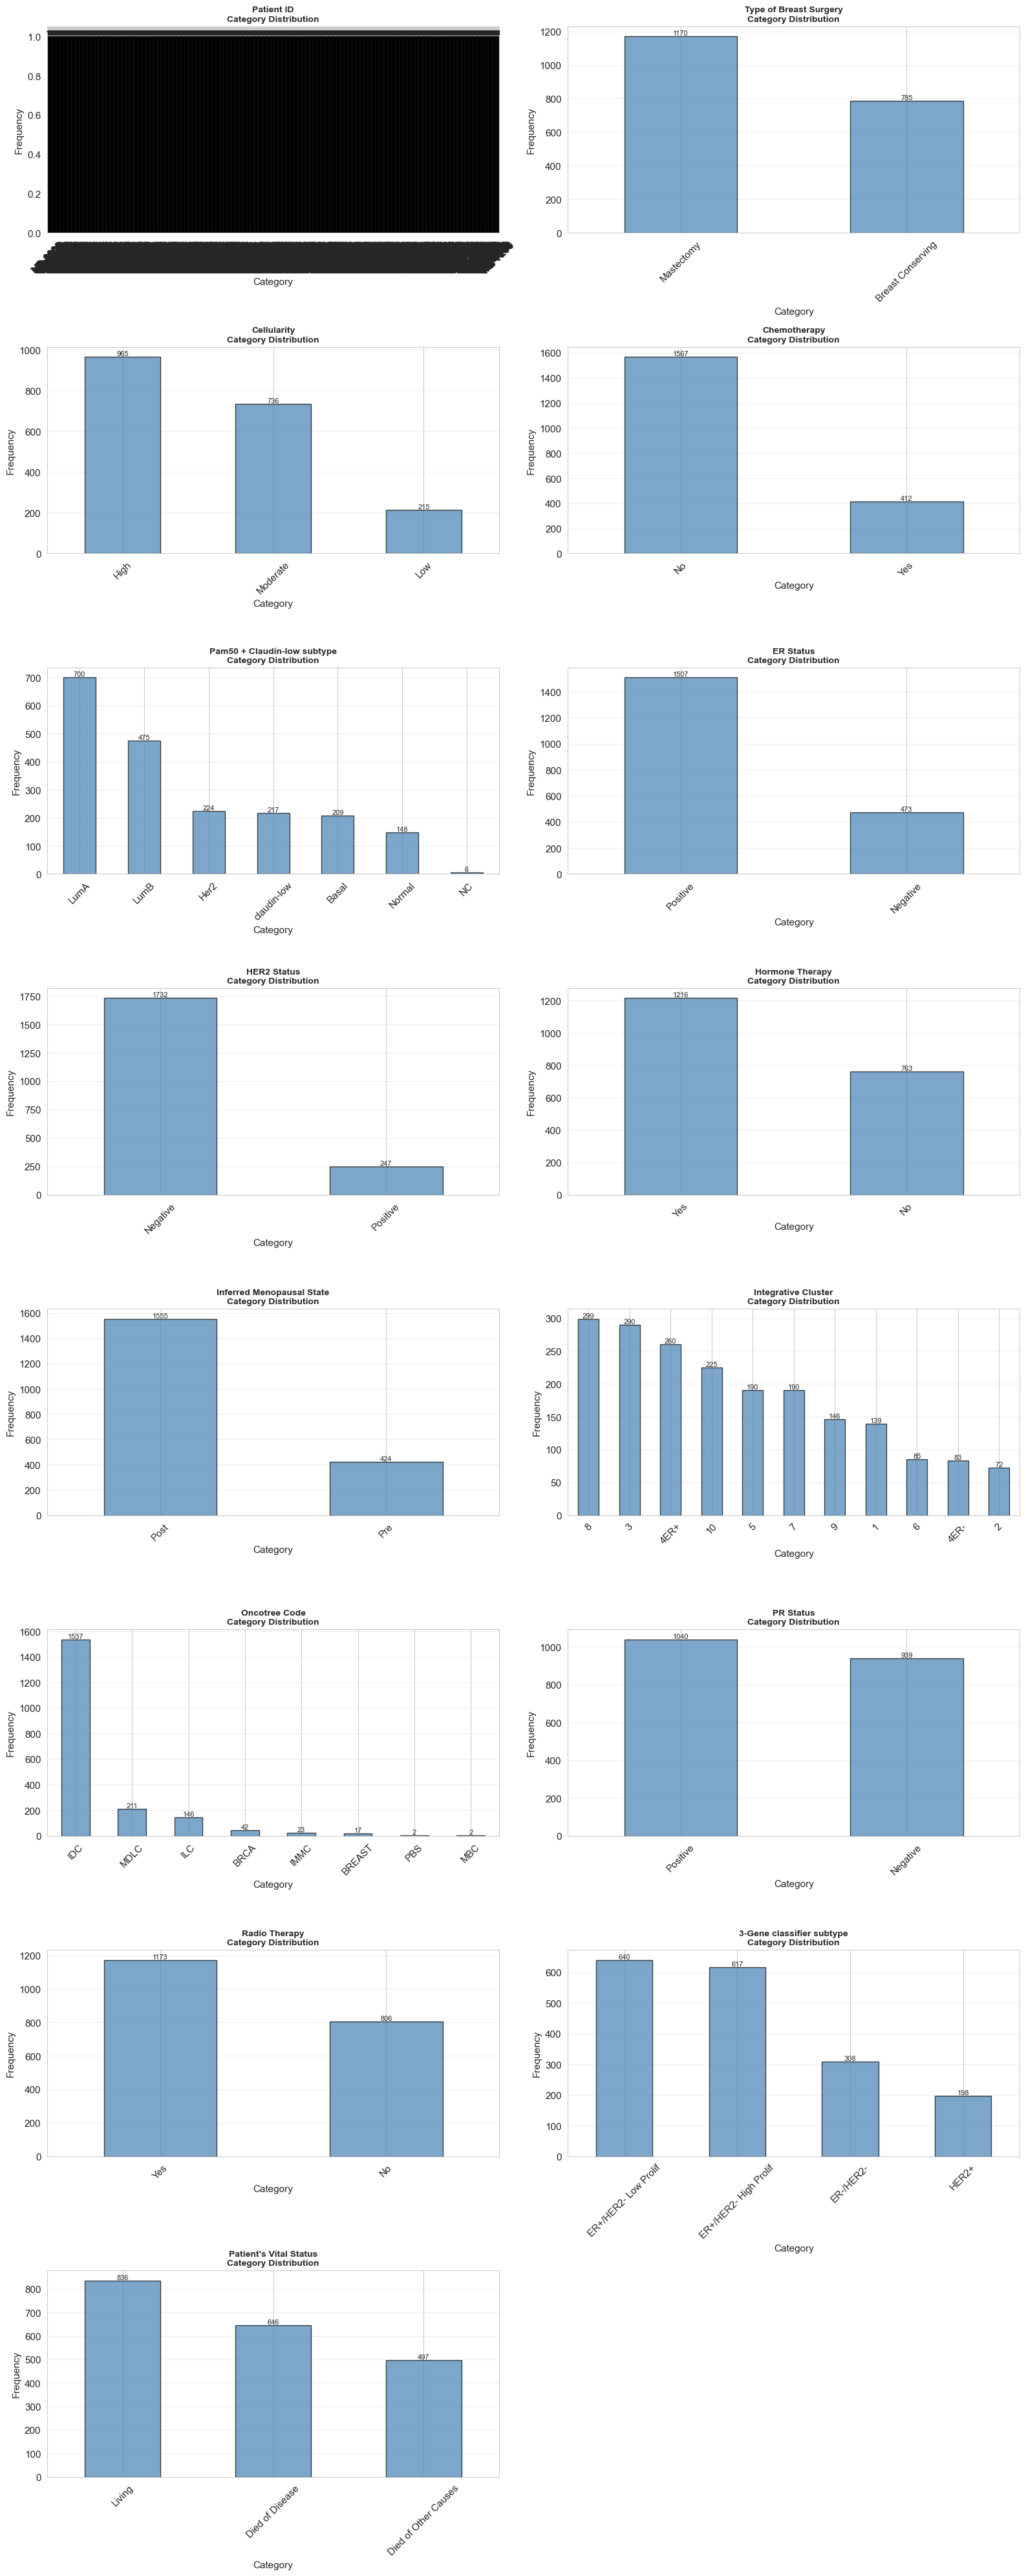


Categorical Feature Summary:

Patient ID:
  Unique values: 1980
  Missing values: 0 (0.00%)
  Most common: MB-0000 (1 occurrences, 0.05%)

Type of Breast Surgery:
  Unique values: 2
  Missing values: 25 (1.26%)
  Most common: Mastectomy (1170 occurrences, 59.09%)
  Value counts:
    Mastectomy: 1170 (59.09%)
    Breast Conserving: 785 (39.65%)

Cellularity:
  Unique values: 3
  Missing values: 64 (3.23%)
  Most common: High (965 occurrences, 48.74%)
  Value counts:
    High: 965 (48.74%)
    Moderate: 736 (37.17%)
    Low: 215 (10.86%)

Chemotherapy:
  Unique values: 2
  Missing values: 1 (0.05%)
  Most common: No (1567 occurrences, 79.14%)
  Value counts:
    No: 1567 (79.14%)
    Yes: 412 (20.81%)

Pam50 + Claudin-low subtype:
  Unique values: 7
  Missing values: 1 (0.05%)
  Most common: LumA (700 occurrences, 35.35%)
  Value counts:
    LumA: 700 (35.35%)
    LumB: 475 (23.99%)
    Her2: 224 (11.31%)
    claudin-low: 217 (10.96%)
    Basal: 209 (10.56%)
    Normal: 148 (7.47%)
    

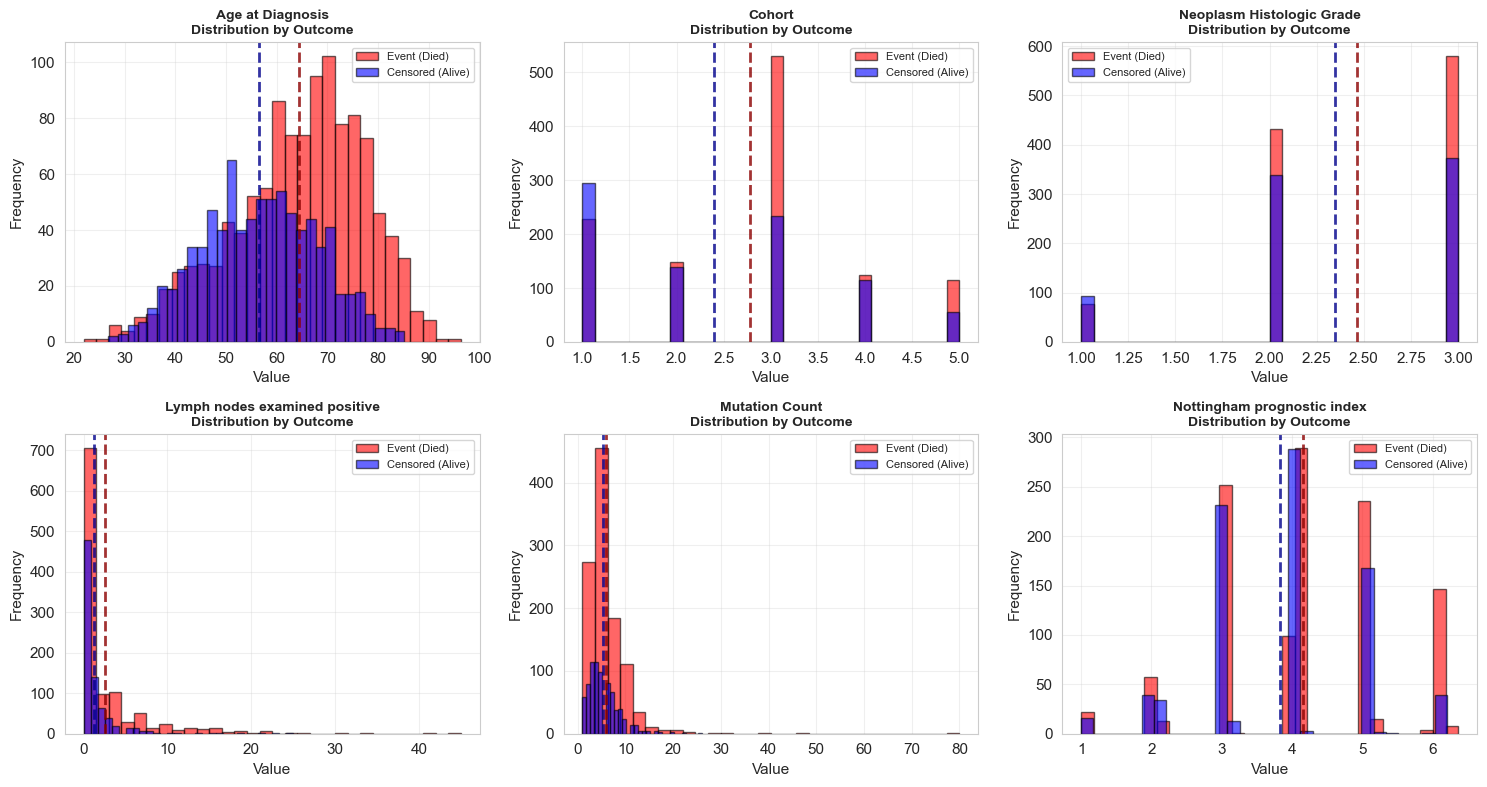


Statistical Comparison (Event vs Censored):
                      Feature  Event_Mean  Censored_Mean  Difference  Difference_%      P_Value Significant
             Age at Diagnosis   64.443645      56.505227    7.938418     14.048997 3.464594e-45         Yes
                   Tumor Size   28.419140      23.351838    5.067302     21.699800 4.309704e-19         Yes
  Nottingham prognostic index    4.152299       3.821321    0.330978      8.661360 8.104370e-15         Yes
                  Tumor Stage    1.845687       1.595645    0.250041     15.670217 5.577285e-13         Yes
Lymph nodes examined positive    2.571558       1.216250    1.355308    111.433338 1.180244e-12         Yes
                       Cohort    2.782343       2.398325    0.384017     16.011893 5.441317e-12         Yes
               Mutation Count    5.963269       5.327273    0.635996     11.938498 2.046976e-04         Yes
    Neoplasm Histologic Grade    2.462741       2.348635    0.114106      4.858407 4.082106

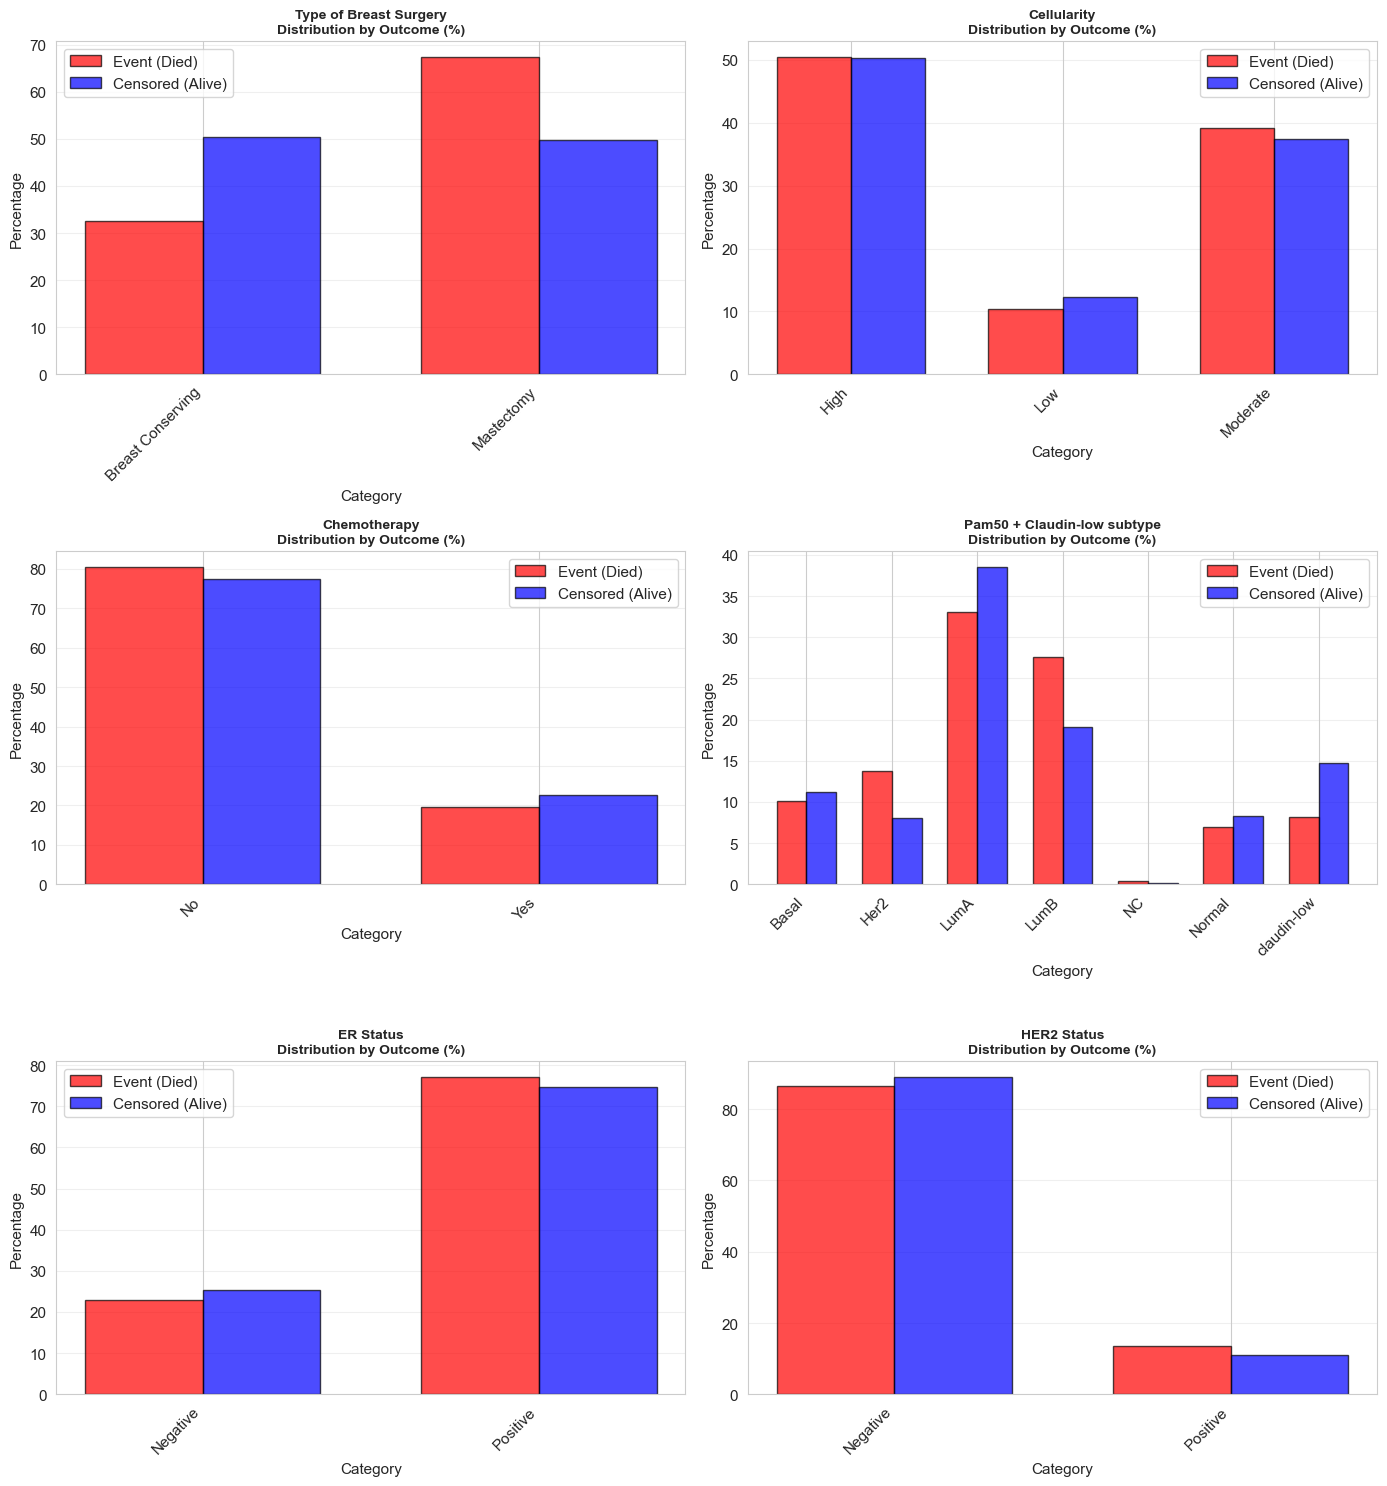


Statistical Comparison (Event vs Censored):
                    Feature  Chi2_Statistic      P_Value Significant
     Type of Breast Surgery       61.559227 4.296235e-15         Yes
Pam50 + Claudin-low subtype       54.228066 6.635756e-10         Yes
                HER2 Status        2.658642 1.029886e-01          No
               Chemotherapy        2.625715 1.051451e-01          No
                  ER Status        1.325386 2.496277e-01          No
                Cellularity        1.917550 3.833623e-01          No

✓ 2 out of 6 categorical features show statistically significant differences (p < 0.05)


In [11]:
# Exclude outcome columns for feature analysis (both original and transformed)
# This prevents data leakage in EDA
outcome_cols = [
    # Transformed outcome columns
    'event_os', 'duration_os', 'event_rfs', 'duration_rfs',
    # Original outcome columns (to prevent leakage)
    'Overall Survival (Months)', 'Overall Survival Status',
    'Relapse Free Status (Months)', 'Relapse Free Status'
]
feature_df = df.drop(columns=[col for col in outcome_cols if col in df.columns], errors='ignore')

numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = feature_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFeature types:")
print(f"  Numeric features: {len(numeric_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")

# Numeric Feature Distributions
print("\n" + "="*60)
print("NUMERIC FEATURE DISTRIBUTIONS")
print("="*60)

if len(numeric_cols) > 0:
    # Calculate number of rows and columns for subplots
    n_numeric = len(numeric_cols)
    n_cols = 3
    n_rows = (n_numeric + n_cols - 1) // n_cols
    
    # Create histograms and box plots for numeric features
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(20, 6 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        ax_hist = axes[idx * 2]
        feature_df[col].hist(bins=30, ax=ax_hist, edgecolor='black', alpha=0.7)
        ax_hist.set_title(f'{col}\nHistogram', fontsize=10, fontweight='bold')
        ax_hist.set_xlabel('Value')
        ax_hist.set_ylabel('Frequency')
        ax_hist.grid(True, alpha=0.3)
        
        # Add mean and median lines
        mean_val = feature_df[col].mean()
        median_val = feature_df[col].median()
        ax_hist.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        ax_hist.axvline(median_val, color='blue', linestyle='--', label=f'Median: {median_val:.2f}')
        ax_hist.legend(fontsize=8)
        
        ax_box = axes[idx * 2 + 1]
        data_for_boxplot = feature_df[col].dropna().values
        ax_box.boxplot(data_for_boxplot, vert=True)
        ax_box.set_title(f'{col}\nBox Plot', fontsize=10, fontweight='bold')
        ax_box.set_ylabel('Value')
        ax_box.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numeric_cols) * 2, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics for numeric features
    print("\nSummary Statistics for Numeric Features:")
    print("="*60)
    numeric_summary = feature_df[numeric_cols].describe()
    print(numeric_summary.T.to_string())
    
    # Check for skewed distributions
    print("\n" + "="*60)
    print("SKEWNESS ANALYSIS")
    print("="*60)
    from scipy.stats import skew
    
    skewness_results = []
    for col in numeric_cols:
        if feature_df[col].notna().sum() > 0:
            skew_val = skew(feature_df[col].dropna())
            skewness_results.append({
                'Feature': col,
                'Skewness': skew_val,
                'Interpretation': 'Highly skewed' if abs(skew_val) > 1 else 'Moderately skewed' if abs(skew_val) > 0.5 else 'Approximately normal'
            })
    
    if skewness_results:
        skew_df = pd.DataFrame(skewness_results)
        skew_df = skew_df.sort_values('Skewness', key=abs, ascending=False)
        print(skew_df.to_string(index=False))
        
        # Flag highly skewed features
        highly_skewed = skew_df[skew_df['Skewness'].abs() > 1]
        if len(highly_skewed) > 0:
            print(f"\n⚠ {len(highly_skewed)} features are highly skewed (|skewness| > 1)")
            print("Consider log transformation or other normalization methods.")
else:
    print("No numeric features found.")

# Categorical Feature Distributions
print("\n" + "="*60)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("="*60)

if len(categorical_cols) > 0:
    # Calculate number of rows and columns for subplots
    n_categorical = len(categorical_cols)
    n_cols = 2
    n_rows = (n_categorical + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1) if n_categorical > 1 else axes.reshape(1, 1)
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols):
        ax = axes[idx]
        value_counts = feature_df[col].value_counts()
        
        value_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}\nCategory Distribution', fontsize=10, fontweight='bold')
        ax.set_xlabel('Category')
        ax.set_ylabel('Frequency')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add count labels on bars
        for i, v in enumerate(value_counts.values):
            ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Summary for categorical features
    print("\nCategorical Feature Summary:")
    print("="*60)
    for col in categorical_cols:
        n_unique = feature_df[col].nunique()
        n_missing = feature_df[col].isnull().sum()
        most_common = feature_df[col].mode().iloc[0] if len(feature_df[col].mode()) > 0 else 'N/A'
        most_common_count = feature_df[col].value_counts().iloc[0] if len(feature_df[col].value_counts()) > 0 else 0
        most_common_pct = (most_common_count / len(feature_df)) * 100
        
        print(f"\n{col}:")
        print(f"  Unique values: {n_unique}")
        print(f"  Missing values: {n_missing} ({n_missing/len(feature_df)*100:.2f}%)")
        print(f"  Most common: {most_common} ({most_common_count} occurrences, {most_common_pct:.2f}%)")
        
        # Show value counts for features with few categories
        if n_unique <= 10:
            print(f"  Value counts:")
            for val, count in feature_df[col].value_counts().head(10).items():
                pct = (count / len(feature_df)) * 100
                print(f"    {val}: {count} ({pct:.2f}%)")
else:
    print("No categorical features found.")


# Distribution by Outcome (Event vs Censored)
print("\n" + "="*60)
print("DISTRIBUTION BY OUTCOME (Event vs Censored)")
print("="*60)
print("Comparing feature distributions between patients who died (event=1) and those who are still alive (event=0)")

if 'event_os' in df.columns:
    event_group = df[df['event_os'] == 1]
    censored_group = df[df['event_os'] == 0]
    
    print(f"\nGroup sizes:")
    print(f"  Event (died): {len(event_group)} patients")
    print(f"  Censored (alive): {len(censored_group)} patients")
    
    # Compare numeric features by outcome
    if len(numeric_cols) > 0:
        print("\n" + "="*60)
        print("NUMERIC FEATURES: COMPARISON BY OUTCOME")
        print("="*60)
        
        # Select top numeric features for visualization (if too many)
        n_features_to_plot = min(6, len(numeric_cols))
        key_numeric = numeric_cols[:n_features_to_plot]
        
        # Create comparison plots (single row layout)
        n_cols_plot = min(3, n_features_to_plot)
        n_rows_plot = (n_features_to_plot + n_cols_plot - 1) // n_cols_plot
        fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
        if n_rows_plot == 1:
            axes = axes.reshape(1, -1) if n_cols_plot > 1 else axes.reshape(1, 1)
        axes = axes.flatten()
        
        for idx, col in enumerate(key_numeric):
            ax = axes[idx]
            
            # Create overlapping histograms
            event_group[col].dropna().hist(bins=30, ax=ax, alpha=0.6, label='Event (Died)', color='red', edgecolor='black')
            censored_group[col].dropna().hist(bins=30, ax=ax, alpha=0.6, label='Censored (Alive)', color='blue', edgecolor='black')
            ax.set_title(f'{col}\nDistribution by Outcome', fontsize=10, fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add mean lines
            event_mean = event_group[col].mean()
            censored_mean = censored_group[col].mean()
            ax.axvline(event_mean, color='darkred', linestyle='--', linewidth=2, alpha=0.8)
            ax.axvline(censored_mean, color='darkblue', linestyle='--', linewidth=2, alpha=0.8)
        
        # Hide unused subplots
        for idx in range(len(key_numeric), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Statistical comparison for numeric features
        print("\nStatistical Comparison (Event vs Censored):")
        print("="*60)
        comparison_results = []
        
        for col in numeric_cols:
            event_values = event_group[col].dropna()
            censored_values = censored_group[col].dropna()
            
            if len(event_values) > 0 and len(censored_values) > 0:
                from scipy.stats import mannwhitneyu
                
                event_mean = event_values.mean()
                censored_mean = censored_values.mean()
                mean_diff = event_mean - censored_mean
                mean_diff_pct = (mean_diff / censored_mean * 100) if censored_mean != 0 else 0
                
                # Mann-Whitney U test (non-parametric)
                try:
                    statistic, p_value = mannwhitneyu(event_values, censored_values, alternative='two-sided')
                    comparison_results.append({
                        'Feature': col,
                        'Event_Mean': event_mean,
                        'Censored_Mean': censored_mean,
                        'Difference': mean_diff,
                        'Difference_%': mean_diff_pct,
                        'P_Value': p_value,
                        'Significant': 'Yes' if p_value < 0.05 else 'No'
                    })
                except:
                    pass
        
        if comparison_results:
            comparison_df = pd.DataFrame(comparison_results)
            comparison_df = comparison_df.sort_values('P_Value')
            print(comparison_df.to_string(index=False))
            
            # Count significant differences
            n_significant = (comparison_df['P_Value'] < 0.05).sum()
            print(f"\n✓ {n_significant} out of {len(comparison_df)} numeric features show statistically significant differences (p < 0.05)")
    
    # Compare categorical features by outcome
    if len(categorical_cols) > 0:
        print("\n" + "="*60)
        print("CATEGORICAL FEATURES: COMPARISON BY OUTCOME")
        print("="*60)
        
        # Select categorical features with reasonable number of categories
        key_categorical = [col for col in categorical_cols if df[col].nunique() <= 10][:6]
        
        if len(key_categorical) > 0:
            # Create comparison plots
            n_cols = 2
            n_rows = (len(key_categorical) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
            if n_rows == 1:
                axes = axes.reshape(1, -1) if len(key_categorical) > 1 else axes.reshape(1, 1)
            axes = axes.flatten()
            
            for idx, col in enumerate(key_categorical):
                ax = axes[idx]
                
                # Create grouped bar chart
                event_counts = event_group[col].value_counts(normalize=True) * 100
                censored_counts = censored_group[col].value_counts(normalize=True) * 100
                
                # Get all categories
                all_categories = sorted(set(event_counts.index) | set(censored_counts.index))
                
                x = np.arange(len(all_categories))
                width = 0.35
                
                event_values = [event_counts.get(cat, 0) for cat in all_categories]
                censored_values = [censored_counts.get(cat, 0) for cat in all_categories]
                
                ax.bar(x - width/2, event_values, width, label='Event (Died)', color='red', alpha=0.7, edgecolor='black')
                ax.bar(x + width/2, censored_values, width, label='Censored (Alive)', color='blue', alpha=0.7, edgecolor='black')
                
                ax.set_title(f'{col}\nDistribution by Outcome (%)', fontsize=10, fontweight='bold')
                ax.set_xlabel('Category')
                ax.set_ylabel('Percentage')
                ax.set_xticks(x)
                ax.set_xticklabels(all_categories, rotation=45, ha='right')
                ax.legend()
                ax.grid(True, alpha=0.3, axis='y')
            
            # Hide unused subplots
            for idx in range(len(key_categorical), len(axes)):
                axes[idx].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Statistical comparison for categorical features (Chi-square test)
            print("\nStatistical Comparison (Event vs Censored):")
            print("="*60)
            from scipy.stats import chi2_contingency
            
            cat_comparison_results = []
            for col in key_categorical:
                # Create contingency table
                contingency = pd.crosstab(df[col], df['event_os'])
                
                if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                    try:
                        chi2, p_value, dof, expected = chi2_contingency(contingency)
                        cat_comparison_results.append({
                            'Feature': col,
                            'Chi2_Statistic': chi2,
                            'P_Value': p_value,
                            'Significant': 'Yes' if p_value < 0.05 else 'No'
                        })
                    except:
                        pass
            
            if cat_comparison_results:
                cat_comparison_df = pd.DataFrame(cat_comparison_results)
                cat_comparison_df = cat_comparison_df.sort_values('P_Value')
                print(cat_comparison_df.to_string(index=False))
                
                n_significant_cat = (cat_comparison_df['P_Value'] < 0.05).sum()
                print(f"\n✓ {n_significant_cat} out of {len(cat_comparison_df)} categorical features show statistically significant differences (p < 0.05)")


### 5.2 Survival Outcome Exploration

**Purpose**: Explore survival outcomes (duration and events) to understand the data structure before Kaplan-Meier analysis.

**What we'll examine:**
- **Survival time distributions**: Histograms and summary statistics for `duration_os`
- **Censoring patterns**: Event vs censored counts and percentages
- **Event rates**: Overall event rate and event rates over time
- **Survival time by outcome**: Compare survival times between event and censored groups
- **Baseline validation**: Verify survival variables are correctly formatted for KM analysis





OVERALL SURVIVAL SUMMARY
Total patients: 1980
Events (died): 1144 (57.8%)
Censored (alive): 836 (42.2%)

Survival Time (duration_os) Statistics:
  Mean: 125.3 months
  Median: 116.5 months
  Min: 0.1 months
  Max: 355.2 months
  IQR: [60.9, 185.1] months

SURVIVAL TIME DISTRIBUTION


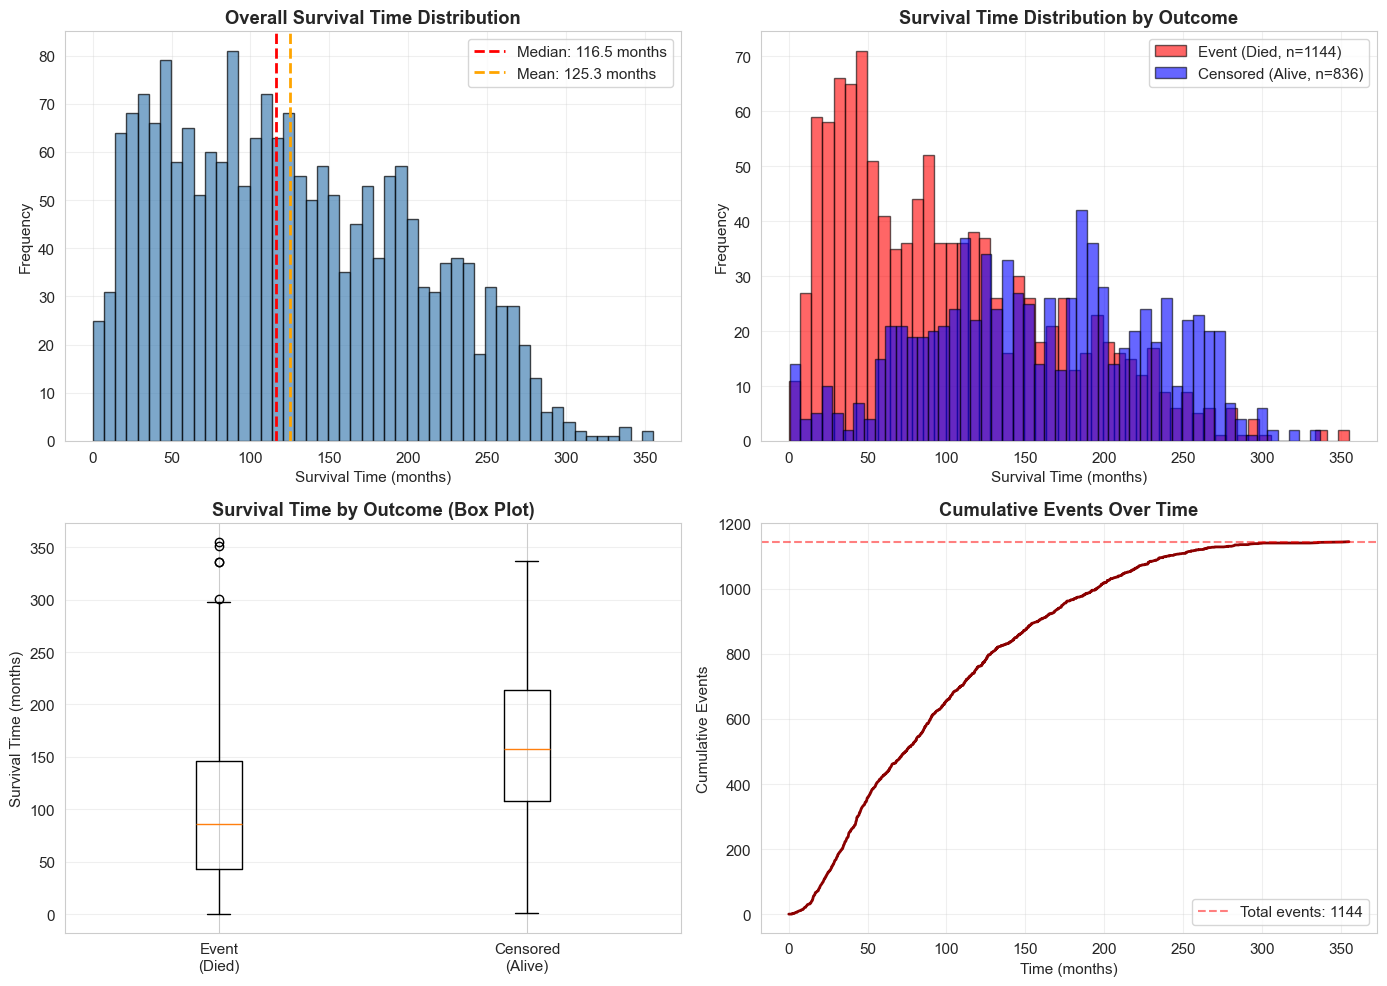


SURVIVAL TIME STATISTICS BY OUTCOME
       Event (Died)  Censored (Alive)  Difference
count   1144.000000        836.000000  308.000000
mean     100.443007        159.332656  -58.889649
std       69.617136         71.256736   -1.639599
min        0.100000          0.766667   -0.666667
25%       42.850000        108.016667  -65.166667
50%       86.066667        157.883333  -71.816667
75%      145.808333        214.100000  -68.291667
max      355.200000        337.033333   18.166667

Mann-Whitney U test (Event vs Censored):
  Statistic: 259502.00
  P-value: 7.63e-68
  Interpretation: Significant difference (p < 0.05)

EVENT RATE BY TIME PERIODS
 Time Period  Patients  Events  Event Rate (%)
 0-12 months        45      30       66.666667
12-24 months       103      90       87.378641
24-36 months       114     103       90.350877
36-60 months       228     204       89.473684
  60+ months      1490     717       48.120805

CENSORING PATTERN ANALYSIS
Censored patients (n=836):
  Mean cens

In [12]:
# 3.5.3 Survival Outcome Exploration

# Verify survival variables exist
if 'event_os' not in df.columns or 'duration_os' not in df.columns:
    raise ValueError("Survival variables (event_os, duration_os) not found in dataframe")

# 1. Overall Survival Summary
print("\n" + "="*60)
print("OVERALL SURVIVAL SUMMARY")
print("="*60)

n_total = len(df)
n_events = df['event_os'].sum()
n_censored = (df['event_os'] == 0).sum()
event_rate = df['event_os'].mean() * 100
censoring_rate = (1 - df['event_os'].mean()) * 100

print(f"Total patients: {n_total}")
print(f"Events (died): {n_events} ({event_rate:.1f}%)")
print(f"Censored (alive): {n_censored} ({censoring_rate:.1f}%)")

# Survival time statistics
print(f"\nSurvival Time (duration_os) Statistics:")
print(f"  Mean: {df['duration_os'].mean():.1f} months")
print(f"  Median: {df['duration_os'].median():.1f} months")
print(f"  Min: {df['duration_os'].min():.1f} months")
print(f"  Max: {df['duration_os'].max():.1f} months")
print(f"  IQR: [{df['duration_os'].quantile(0.25):.1f}, {df['duration_os'].quantile(0.75):.1f}] months")

# 2. Survival Time Distribution Visualization
print("\n" + "="*60)
print("SURVIVAL TIME DISTRIBUTION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall histogram
ax1 = axes[0, 0]
df['duration_os'].hist(bins=50, ax=ax1, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['duration_os'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["duration_os"].median():.1f} months')
ax1.axvline(df['duration_os'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {df["duration_os"].mean():.1f} months')
ax1.set_xlabel('Survival Time (months)')
ax1.set_ylabel('Frequency')
ax1.set_title('Overall Survival Time Distribution', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribution by outcome
ax2 = axes[0, 1]
event_times = df[df['event_os'] == 1]['duration_os']
censored_times = df[df['event_os'] == 0]['duration_os']
ax2.hist(event_times, bins=50, alpha=0.6, label=f'Event (Died, n={len(event_times)})', color='red', edgecolor='black')
ax2.hist(censored_times, bins=50, alpha=0.6, label=f'Censored (Alive, n={len(censored_times)})', color='blue', edgecolor='black')
ax2.set_xlabel('Survival Time (months)')
ax2.set_ylabel('Frequency')
ax2.set_title('Survival Time Distribution by Outcome', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Box plot by outcome
ax3 = axes[1, 0]
event_data = [event_times.values, censored_times.values]
ax3.boxplot(event_data, labels=['Event\n(Died)', 'Censored\n(Alive)'], vert=True)
ax3.set_ylabel('Survival Time (months)')
ax3.set_title('Survival Time by Outcome (Box Plot)', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Cumulative events over time
ax4 = axes[1, 1]
# Sort by survival time
df_sorted = df.sort_values('duration_os')
cumulative_events = df_sorted['event_os'].cumsum()
ax4.plot(df_sorted['duration_os'], cumulative_events, linewidth=2, color='darkred')
ax4.set_xlabel('Time (months)')
ax4.set_ylabel('Cumulative Events')
ax4.set_title('Cumulative Events Over Time', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axhline(n_events, color='red', linestyle='--', alpha=0.5, label=f'Total events: {n_events}')
ax4.legend()

plt.tight_layout()
plt.show()

# 3. Survival Time Statistics by Outcome
print("\n" + "="*60)
print("SURVIVAL TIME STATISTICS BY OUTCOME")
print("="*60)

event_stats = event_times.describe()
censored_stats = censored_times.describe()

comparison_df = pd.DataFrame({
    'Event (Died)': event_stats,
    'Censored (Alive)': censored_stats
})
comparison_df['Difference'] = comparison_df['Event (Died)'] - comparison_df['Censored (Alive)']

print(comparison_df.to_string())

# Statistical test
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(event_times, censored_times, alternative='two-sided')
print(f"\nMann-Whitney U test (Event vs Censored):")
print(f"  Statistic: {statistic:.2f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Interpretation: {'Significant difference' if p_value < 0.05 else 'No significant difference'} (p < 0.05)")

# 4. Event Rate Over Time
print("\n" + "="*60)
print("EVENT RATE BY TIME PERIODS")
print("="*60)

# Define time periods (in months)
time_periods = [
    (0, 12, "0-12 months"),
    (12, 24, "12-24 months"),
    (24, 36, "24-36 months"),
    (36, 60, "36-60 months"),
    (60, float('inf'), "60+ months")
]

period_stats = []
for start, end, label in time_periods:
    if end == float('inf'):
        period_df = df[(df['duration_os'] >= start)]
    else:
        period_df = df[(df['duration_os'] >= start) & (df['duration_os'] < end)]
    
    if len(period_df) > 0:
        n_in_period = len(period_df)
        n_events_in_period = period_df['event_os'].sum()
        event_rate_period = (n_events_in_period / n_in_period) * 100
        
        period_stats.append({
            'Time Period': label,
            'Patients': n_in_period,
            'Events': n_events_in_period,
            'Event Rate (%)': event_rate_period
        })

if period_stats:
    period_df = pd.DataFrame(period_stats)
    print(period_df.to_string(index=False))

# 5. Censoring Pattern Analysis
print("\n" + "="*60)
print("CENSORING PATTERN ANALYSIS")
print("="*60)

# Analyze when censoring occurs
censored_df = df[df['event_os'] == 0]
event_df = df[df['event_os'] == 1]

print(f"Censored patients (n={len(censored_df)}):")
print(f"  Mean censoring time: {censored_df['duration_os'].mean():.1f} months")
print(f"  Median censoring time: {censored_df['duration_os'].median():.1f} months")
print(f"  Min censoring time: {censored_df['duration_os'].min():.1f} months")
print(f"  Max censoring time: {censored_df['duration_os'].max():.1f} months")

print(f"\nEvent patients (n={len(event_df)}):")
print(f"  Mean event time: {event_df['duration_os'].mean():.1f} months")
print(f"  Median event time: {event_df['duration_os'].median():.1f} months")
print(f"  Min event time: {event_df['duration_os'].min():.1f} months")
print(f"  Max event time: {event_df['duration_os'].max():.1f} months")

# Check for immediate events (duration = 0 or very small)
immediate_events = df[(df['event_os'] == 1) & (df['duration_os'] <= 0.1)]
if len(immediate_events) > 0:
    print(f"\nWarning: {len(immediate_events)} patients have events at time <= 0.1 months")
    print("  These may need special handling in KM analysis")

# 6. Validation Checks
print("\n" + "="*60)
print("VALIDATION CHECKS FOR KM ANALYSIS")
print("="*60)

# Check for negative survival times
negative_times = df[df['duration_os'] < 0]
if len(negative_times) > 0:
    print(f"Warning: {len(negative_times)} patients have negative survival times")
else:
    print("✓ All survival times are non-negative")

# Check for zero survival times with events
zero_events = df[(df['duration_os'] == 0) & (df['event_os'] == 1)]
if len(zero_events) > 0:
    print(f"Warning: {len(zero_events)} patients have events at time 0")
    print("  Consider handling these carefully in KM analysis")
else:
    print("✓ No events at time 0")

# Check event indicator is binary
if df['event_os'].isin([0, 1]).all():
    print("✓ Event indicator is binary (0 or 1)")
else:
    print(f"Warning: Event indicator contains values other than 0 or 1")
    print(f"  Unique values: {df['event_os'].unique()}")

# Check for missing survival data
missing_duration = df['duration_os'].isnull().sum()
missing_event = df['event_os'].isnull().sum()
if missing_duration == 0 and missing_event == 0:
    print("✓ No missing survival data")
else:
    print(f"Warning: Missing duration: {missing_duration}, Missing event: {missing_event}")

# 7. Key Survival Metrics for KM
print("\n" + "="*60)
print("KEY SURVIVAL METRICS (For KM Analysis)")
print("="*60)

# Calculate potential survival probabilities at key time points (rough estimates)
time_points = [6, 12, 24, 36, 60]  # months
print("\nEstimated survival probabilities at key time points:")
print("(These will be calculated more precisely using KM)")
for t in time_points:
    # Rough estimate: proportion of patients who survived beyond time t
    survived_beyond_t = len(df[(df['duration_os'] > t) | ((df['duration_os'] <= t) & (df['event_os'] == 0))])
    survival_prob = survived_beyond_t / n_total
    print(f"  S({t} months) ≈ {survival_prob:.3f} ({survived_beyond_t}/{n_total} patients)")

# Median survival estimate
median_estimate = df['duration_os'].median()
print(f"\nMedian survival time (approximate): {median_estimate:.1f} months")
print("(Exact median will be calculated using KM)")

print(f"  Total patients: {n_total}")
print(f"  Events: {n_events} ({event_rate:.1f}%)")
print(f"  Censored: {n_censored} ({censoring_rate:.1f}%)")
print(f"\nNote: KM analysis will use the FULL dataset (df), not train/test splits")


### 5.3 Missing Data Analysis

MISSING DATA ANALYSIS (Full Dataset)

Total features (excluding outcomes): 23
Features with missing data: 18
Total missing values: 1139
Total cells: 45540
Missing percentage: 2.50%

FEATURES WITH MISSING DATA
                      Feature  Missing_Count  Missing_Percent Data_Type  Unique_Values
                  Tumor Stage            514        25.959596   float64              5
    3-Gene classifier subtype            217        10.959596    object              4
               Mutation Count            121         6.111111   float64             30
    Neoplasm Histologic Grade             87         4.393939   float64              3
Lymph nodes examined positive             76         3.838384   float64             31
                  Cellularity             64         3.232323    object              3
       Type of Breast Surgery             25         1.262626    object              2
                   Tumor Size             25         1.262626   float64            112
        

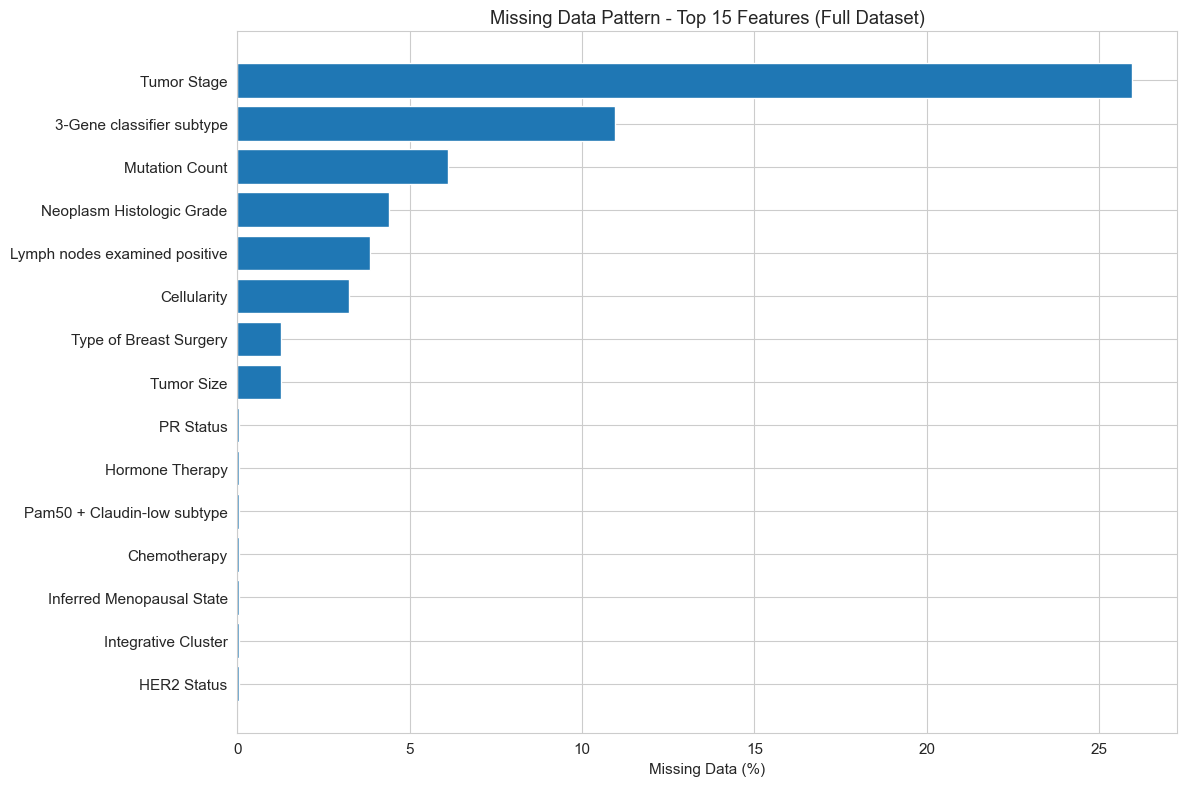


MISSING DATA BY OUTCOME (Informative Missingness Check)
                      Feature  Missing_Event_%  Missing_Censored_%  Difference_%
                  Tumor Stage        28.059441           23.086124      4.973316
    3-Gene classifier subtype        12.325175            9.090909      3.234266
               Mutation Count         4.807692            7.894737      3.087045
                  Cellularity         2.622378            4.066986      1.444608
    Neoplasm Histologic Grade         4.982517            3.588517      1.394001
Lymph nodes examined positive         3.496503            4.306220      0.809717
       Type of Breast Surgery         1.486014            0.956938      0.529076
                   Tumor Size         1.398601            1.076555      0.322046
                    PR Status         0.087413            0.000000      0.087413
              Hormone Therapy         0.087413            0.000000      0.087413

✓ Missing data appears balanced across outcomes


In [13]:
print("="*60)
print("MISSING DATA ANALYSIS (Full Dataset)")
print("="*60)

# Exclude outcome columns from missing data analysis (both original and transformed)
# prevents data leakage in EDA
outcome_cols = [
    # Transformed outcome columns
    'event_os', 'duration_os', 'event_rfs', 'duration_rfs',
    # Original outcome columns (to prevent leakage)
    'Overall Survival (Months)', 'Overall Survival Status',
    'Relapse Free Status (Months)', 'Relapse Free Status'
]
feature_df = df.drop(columns=[col for col in outcome_cols if col in df.columns], errors='ignore')

# Calculate missing data statistics for features only (excluding outcomes)
missing_stats = pd.DataFrame({
    'Feature': feature_df.columns,
    'Missing_Count': feature_df.isnull().sum(),
    'Missing_Percent': (feature_df.isnull().sum() / len(feature_df) * 100),
    'Data_Type': feature_df.dtypes,
    'Unique_Values': [feature_df[col].nunique() for col in feature_df.columns]
})

# Sort by missing percentage
missing_stats = missing_stats.sort_values('Missing_Percent', ascending=False)

print(f"\nTotal features (excluding outcomes): {len(feature_df.columns)}")
print(f"Features with missing data: {(missing_stats['Missing_Percent'] > 0).sum()}")
print(f"Total missing values: {missing_stats['Missing_Count'].sum()}")
print(f"Total cells: {len(feature_df) * len(feature_df.columns)}")
print(f"Missing percentage: {(missing_stats['Missing_Count'].sum() / (len(feature_df) * len(feature_df.columns)) * 100):.2f}%")

# Display features with missing data
print("\n" + "="*60)
print("FEATURES WITH MISSING DATA")
print("="*60)
features_with_missing = missing_stats[missing_stats['Missing_Percent'] > 0]
if len(features_with_missing) > 0:
    print(features_with_missing.to_string(index=False))
else:
    print("No missing data found!")

# Visualize missing data pattern
if len(features_with_missing) > 0:
    plt.figure(figsize=(12, 8))
    top_missing = features_with_missing.head(15)
    plt.barh(range(len(top_missing)), top_missing['Missing_Percent'].values)
    plt.yticks(range(len(top_missing)), top_missing['Feature'].values)
    plt.xlabel('Missing Data (%)')
    plt.title('Missing Data Pattern - Top 15 Features (Full Dataset)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Check if missingness is related to outcome (informative missingness)
# Note: We use event_os as a grouping variable (not as a feature) to compare missingness
print("\n" + "="*60)
print("MISSING DATA BY OUTCOME (Informative Missingness Check)")
print("="*60)
if len(features_with_missing) > 0:
    missing_by_outcome = []
    # features_with_missing already excludes outcome columns (from feature_df)
    for col in features_with_missing['Feature'].head(10):
        # Use df to access event_os for grouping, but col is from feature_df (no outcome columns)
        missing_event = df.loc[df['event_os'] == 1, col].isnull().mean() * 100
        missing_censored = df.loc[df['event_os'] == 0, col].isnull().mean() * 100
        missing_by_outcome.append({
            'Feature': col,
            'Missing_Event_%': missing_event,
            'Missing_Censored_%': missing_censored,
            'Difference_%': abs(missing_event - missing_censored)
        })
    
    if missing_by_outcome:
        missing_outcome_df = pd.DataFrame(missing_by_outcome)
        missing_outcome_df = missing_outcome_df.sort_values('Difference_%', ascending=False)
        print(missing_outcome_df.to_string(index=False))
        
        # Flag features with differential missingness
        threshold = 5.0  # 5% difference
        differential_missing = missing_outcome_df[missing_outcome_df['Difference_%'] > threshold]
        if len(differential_missing) > 0:
            print(f"\n⚠ WARNING: {len(differential_missing)} features show differential missingness (>5% difference)")
            print("This may indicate informative missingness or potential bias.")
        else:
            print("\n✓ Missing data appears balanced across outcomes")


# 6.0 Kaplan-Meier (KM) Curves

**Purpose**: Estimate survival probabilities and create survival curves using the Kaplan-Meier method.

**What we'll do:**
- **Overall KM curve**: Estimate survival probabilities for the entire cohort
- **Stratified KM curves**: Compare survival across different subgroups (e.g., by tumor stage, treatment)
- **Survival statistics**: Calculate median survival, survival probabilities at key time points
- **Log-rank tests**: Statistically compare survival curves between groups


## 6.1 Kaplan-Meier Curve

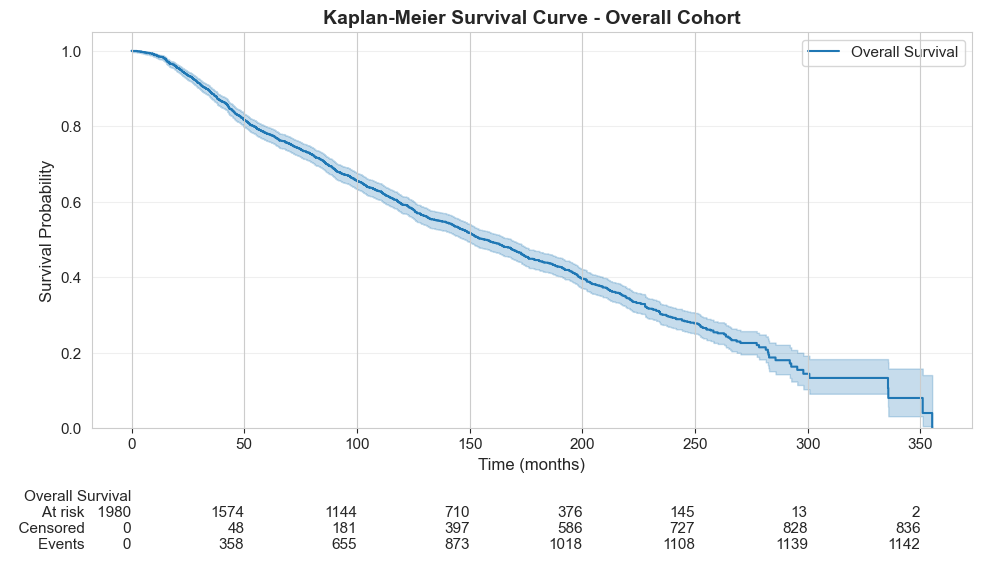


SURVIVAL STATISTICS

Survival probabilities at key time points:


<Figure size 1000x600 with 0 Axes>

  S(6 months) = 0.995
  S(12 months) = 0.985
  S(24 months) = 0.939
  S(36 months) = 0.886
  S(60 months) = 0.780

Total patients: 1980
Events (deaths): 1144 (57.8%)
Censored: 836 (42.2%)


In [14]:
# Fit KM on the full dataset
km = KaplanMeierFitter(label="Overall Survival")

# Ensure survival times are non-negative
df_km = df.copy()
df_km['duration_os'] = df_km['duration_os'].clip(lower=0)
km.fit(durations=df_km['duration_os'], 
       event_observed=df_km['event_os'])

# Plot the survival curve
fig, ax = plt.subplots(figsize=(10, 6))
km.plot_survival_function(ax=ax, ci_show=True)
add_at_risk_counts(km, ax=ax)
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curve - Overall Cohort', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SURVIVAL STATISTICS")
print("="*60)

# Survival probabilities at key time points
time_points = [6, 12, 24, 36, 60]  # months
print(f"\nSurvival probabilities at key time points:")
for t in time_points:
    # survival_prob = km.predict(t)
    survival_prob = float(km.survival_function_at_times(t).values)

    if t <= km.survival_function_.index.max():
        ax.annotate(f"{survival_prob:.2f}",
                        xy=(t, survival_prob),
                        xytext=(0, 8),
                        textcoords="offset points",
                        ha='center',
                        fontsize=9)
        
add_at_risk_counts(km, ax=ax)
plt.tight_layout()
plt.show()
        
for t in time_points:
    # survival_prob = km.predict(t)
    survival_prob = float(km.survival_function_at_times(t).values)
    # Get confidence interval if available
    try:
        ci = km.confidence_interval_
        if t <= ci.index.max():
            ci_lower = ci.loc[ci.index <= t, 'lower_bound'].iloc[-1] #if len(ci.loc[ci.index <= t]) > 0 else None
            ci_upper = ci.loc[ci.index <= t, 'upper_bound'].iloc[-1] #if len(ci.loc[ci.index <= t]) > 0 else None
            if ci_lower is not None and ci_upper is not None:
                print(f"  S({t} months) = {survival_prob:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}])")
            else:
                print(f"  S({t} months) = {survival_prob:.3f}")
        else:
            print(f"  S({t} months) = {survival_prob:.3f}")
    except:
        print(f"  S({t} months) = {survival_prob:.3f}")

print(f"\nTotal patients: {len(df_km)}")
print(f"Events (deaths): {df_km['event_os'].sum()} ({df_km['event_os'].mean()*100:.1f}%)")
print(f"Censored: {(df_km['event_os'] == 0).sum()} ({(df_km['event_os'] == 0).mean()*100:.1f}%)")
# display(km.survival_function_.head())




In the early phase (0-6 months), the survival probability is very high at 0.995, reflecting few deaths in the early months. Over the course of 12-24 months, the rates are between 0.93-0.98 and between 36-60 months the survival probability drops more to .78-0.886. Early survival is high and mortality is gradually accumulating over years. CI remains narrow between short-medium term phases, losing stability onces less patient data is avaliable. 

The patient event (death)/censoring (patient losing contact, information is incomplete)  follows the same patterns as other long-term, retrospective cancer datasets as many patients survived beyong the observation time. Deaths = 1144 (57.8%), Censored = 836 (42.2%) means the KM prediction is remaining robust despite the slight instability towards the end (where the CI bands widen). The CI bands widen significnatly around 250-300 months, which is expected due to the at-risk population shrinking and estimates become less reliable. 

**Overall, this curve shows how long patients survive after a Breast Cancer Diagnosis, slowing decreasing as patients pass away. Short-term survival is excellent, as after 1 year 98-99% survive (early deaths are rare). Medium-term surival, between 2-3 years, remains high between 89-94% surviving. After 5 years, survival drops to 78%, meaning around 4/5 patients survive. Most deaths will occur over months to years instead of immediately after diagnosis, so clinical focus should include long-term follow-ups.**

### 6.1.1 Median Survival Time, RMST

In [15]:
median_survival_time = km.median_survival_time_
print(f"Median survival time: {median_survival_time:.1f} months")

# Restricted Mean Survival Time (RMST)
horizons = [12.0, 24.0, 36.0, 60.0, 120.0]  # months

# for t in horizons:
#     if t in km.survival_function_.index:    #none appear
#         y = km.survival_function_.loc[t].values[0]
#         ax.annotate(f"{y:.2f}", xy=(t, y),
#                     xytext=(0, 10), textcoords="offset points",
#                     ha='center', fontsize=9)
        

rows = []
for t0 in horizons:
    rmst_val = restricted_mean_survival_time(km, t=t0)
    rows.append({"t0 [months]": int(t0), "RMST [months]": round(float(rmst_val), 1)})

rmst_table = pd.DataFrame(rows)
print("\nRestricted Mean Survival Time (RMST):")
print(rmst_table.to_string(index=False))


Median survival time: 156.3 months

Restricted Mean Survival Time (RMST):
 t0 [months]  RMST [months]
          12           11.9
          24           23.5
          36           34.5
          60           54.4
         120           95.7


The Median Survival time of 156.3 months (~13 years) indicates the point within the overall study where half of the patients survived vs died. 

The RMST tells us the average number of months patients in the cohort lived within different periods of time (over first 10 years). At 1 year, the average survival was 11.9 months, proving excellent short term survival. The "time lost" to mortality is minimal across the cohort. After 5 years, the average survival is 54.4 months (out of 60), with a difference of only 5.6 months that represents the average "survival time lost" due to death. At 10 years, the average survival is 95.7 months (out of 120), with the average time lost to mortality increasing to 24.3 months per patient, revealing the cumulative impact of the disease over long term. 


**RMST provides a more nuanced view over median survival, providing insights during milestone time periods.**

## 6.2 Relapse-Free Survival (RFS) Kaplan-Meier Curve


This section analyzes the long-term risk of cancer reaccurance in the cohort of 1980 BC patients. RFS is the percentage of patients who did not experience cancer reaccurance after treatment, allowing us to measure treatment effectiveness and long term prognosis. 

RELAPSE-FREE SURVIVAL (RFS) KAPLAN-MEIER ANALYSIS

RFS data available: 1980 patients
Events (recurrences): 803 (40.6%)
Censored (no recurrence): 1177 (59.4%)


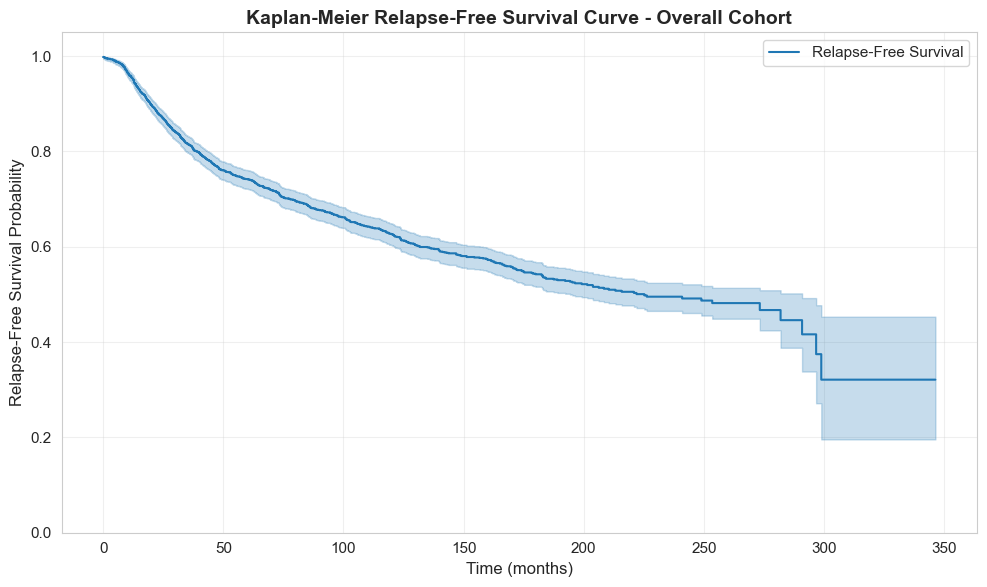

In [16]:
# Check if RFS data is available
if 'event_rfs' in df.columns and 'duration_rfs' in df.columns:
    print("="*60)
    print("RELAPSE-FREE SURVIVAL (RFS) KAPLAN-MEIER ANALYSIS")
    print("="*60)
    
    # Fit KM on RFS data
    km_rfs = KaplanMeierFitter(label="Relapse-Free Survival")
    
    # Ensure survival times are non-negative
    df_rfs = df[df['duration_rfs'].notna()].copy()
    df_rfs['duration_rfs'] = df_rfs['duration_rfs'].clip(lower=0)
    
    print(f"\nRFS data available: {len(df_rfs)} patients")
    print(f"Events (recurrences): {df_rfs['event_rfs'].sum()} ({df_rfs['event_rfs'].mean()*100:.1f}%)")
    print(f"Censored (no recurrence): {(df_rfs['event_rfs'] == 0).sum()} ({(df_rfs['event_rfs'] == 0).mean()*100:.1f}%)")
    
    # Fit the KM estimator
    km_rfs.fit(durations=df_rfs['duration_rfs'], event_observed=df_rfs['event_rfs'])
    
    # Plot the survival curve
    fig, ax = plt.subplots(figsize=(10, 6))
    km_rfs.plot_survival_function(ax=ax, ci_show=True)
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Relapse-Free Survival Probability', fontsize=12)
    ax.set_title('Kaplan-Meier Relapse-Free Survival Curve - Overall Cohort', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    
else:
    print("RFS data not available in the dataset.")
    print("Only Overall Survival (OS) analysis will be performed.")







1-year RFS has a probability of 95.5%, with excellent short term disease control with still very few reaccurances. After 3 years, RFS probability has decreased to 81.3%, after 5 years to 74.2% (over 3/4 of patients are still disease free after inital diagnosis and treatment), and after 10 RFS probability is 62.7%, with a **majority of patients still cancer free**. 

The relapse-free survival curve experences a sharper drop within the first 50 months, from ~1.0 to ~0.78, suggesting a higher risk of relaps during the early stages. Beyond this point, the curve flattens, indicating a slower rate of decline in relapse-free probability over long term. The relapse-free survival curve falls to 0.5 between 200 and 250 months. After 270 months, the probability of remaining relapse-free declines further to around 0.3.

Clinical meaning:
Interventions aimed at reducing recurrence should target earlier time windows (first 5–10 years).

### 6.2.1 Median Relapse-Free Survival Time

In [17]:
median_rfs_time = km_rfs.median_survival_time_
print(f"\nMedian relapse-free survival time: {median_rfs_time:.1f} months")
    
horizons = [12.0, 24.0, 36.0, 60.0, 120.0]  # months
rows = []
for t0 in horizons:
    rmst_val = restricted_mean_survival_time(km_rfs, t=t0)
    rows.append({"t0 [months]": int(t0), "RMST [months]": round(float(rmst_val), 1)})
    
rmst_table_rfs = pd.DataFrame(rows)
print("\nRestricted Mean Relapse-Free Survival Time (RMST):")
print(rmst_table_rfs.to_string(index=False))


Median relapse-free survival time: 225.2 months

Restricted Mean Relapse-Free Survival Time (RMST):
 t0 [months]  RMST [months]
          12           11.8
          24           22.7
          36           32.8
          60           51.3
         120           92.1


The Median RFS time is 225.2 months (~18.8 years), which is an extremely favorable outcome, as 50% of patients have remained relapse free for almost 20 years. For a typical patient in thie cohort, the risk of reaccurance is low enough that it takes almost 2 decades for the cumulative reaccurance rate to reach 50%. 

The RMST provides a deeper look at cancer reaccurance average rates in key time periods. AT 1 year, the average relapse free time is 11.8 months, showing excellent short term disease control. At 5 years, the average relapse free time is 51.3 months (out of 60), with 8.7 months of average survival time lost due to reaccurance in that period. At 10 years, the average relapse free time is 92.1 months (out of 120), with 27.9 months of average survival time lost due to reaccurance. This shows that this cohort has an excellent long-term prognosis, with high relapse-free survival times. While reaccurances do happen, they are not a frequent event for the majority of patients, indicating initial treatment is a long-lasting benefit. 

## 6.3 Cumulative Incidence Curves and Nelson-Aalen Cumulative Hazard


Cumulative Incidence of Death is a direct measure of mortality. It represents the percentage of patients who have passed away by a certain time.

Cumulative Hazard measures the total accumulated risk of death over time, but is less intuitive than probability, its rate of change reveals when the risk is highest.

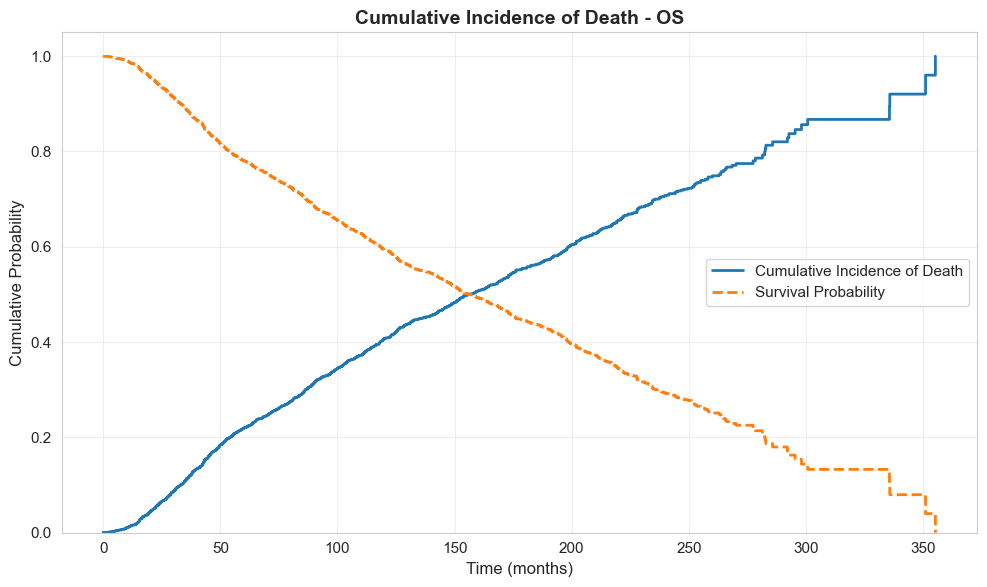

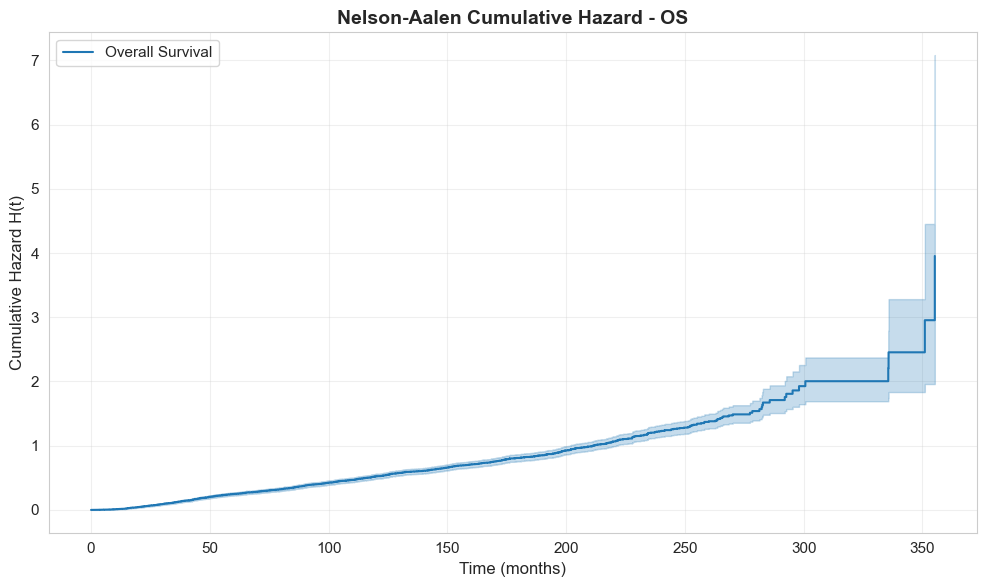

In [18]:
# Cumulative Incidence Curves - OS
# Cumulative incidence = 1 - Survival probability
survival_func = km.survival_function_
survival_probs = survival_func.iloc[:, 0].values
cumulative_incidence = 1 - survival_probs
times = survival_func.index.values

fig, ax = plt.subplots(figsize=(10, 6))
ax.step(times, cumulative_incidence, where='post', label='Cumulative Incidence of Death', linewidth=2)
ax.step(times, survival_probs, where='post', label='Survival Probability', linewidth=2, linestyle='--')
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Cumulative Incidence of Death - OS', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


#  Nelson-Aalen Cumulative Hazard - OS
naf_os = NelsonAalenFitter(label="Overall Survival")
naf_os.fit(durations=df_km['duration_os'], event_observed=df_km['event_os'])

fig, ax = plt.subplots(figsize=(10, 6))
naf_os.plot_cumulative_hazard(ax=ax, ci_show=True)
ax.set_xlabel('Time (months)', fontsize=12)
ax.set_ylabel('Cumulative Hazard H(t)', fontsize=12)
ax.set_title('Nelson-Aalen Cumulative Hazard - OS', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




The Culmulative Incidence of Death (Overall Survival - OS) shows after 1 year, the cumulative risk of death is only 1.5%, indicating excellent short term surival of patients. After 5 years, the risk is 22.0%, meaning the survival rate is 78%, suggesting a favorable meduim term prognosis for the majority of patients. After 10 years, the risk rises to 40.7%, still with a majority of patients surviving. The Median of OS is around 161 months, where the lines intersect on the graph. The very long term outlook, by 300 months (25 years), shows the cumulative indicence of death to be 85.6% and at 350 months (~29 years) it is 92%, common in an aging population. 

The Nelson–Aalen cumulative hazard curve showed a gradual accumulation of mortality risk over time, with a sharp increase in hazard after ~300 months; widening confidence intervals reflect fewer patients remaining in follow-up at later time points. This indicates the risk of death is not decreasing over time for the surviving patients, with the risk accumulation accelerating in later years. While risk of cancer can diminish over time, the overall risk of death remains persistant/gorws, indicating late reaccurance (relapsing years after initial diagnosis) or more likely, competing mortality, as age and corresponding risks increase and become a significant factor of death. 

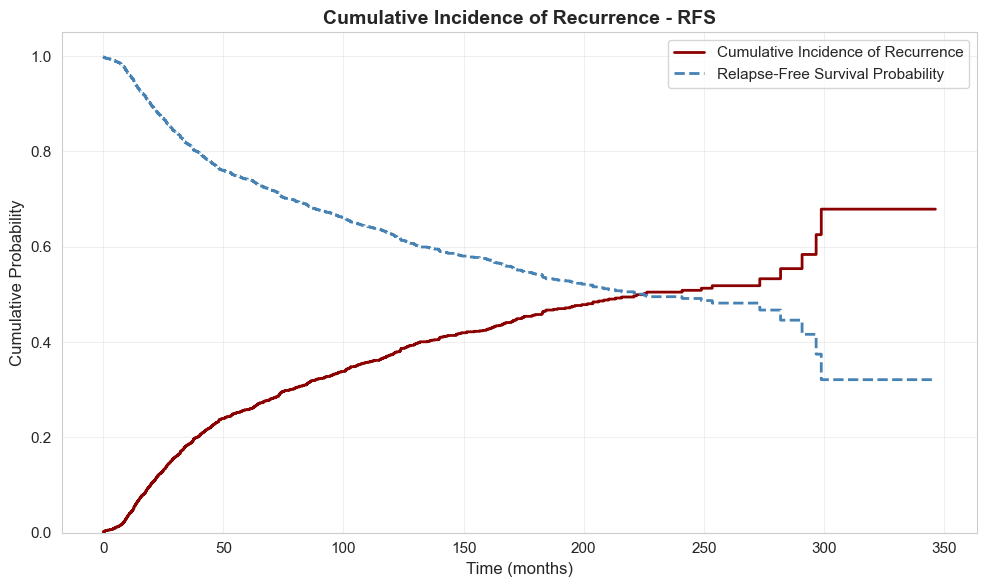

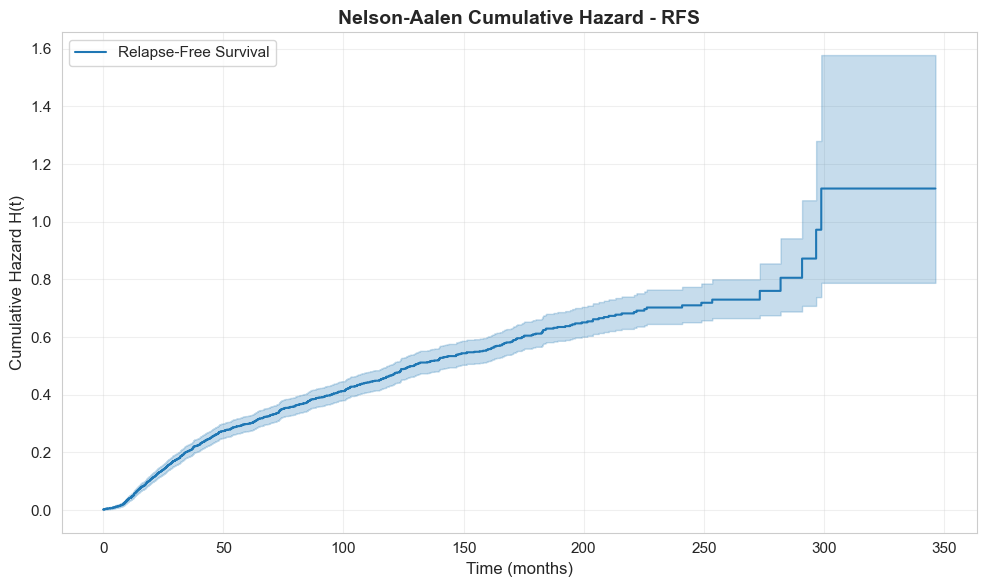

In [19]:
# Cumulative Incidence and Nelson-Aalen - RFS

if 'event_rfs' in df.columns and 'duration_rfs' in df.columns:
    df_rfs = df[df['duration_rfs'].notna()].copy()
    df_rfs['duration_rfs'] = df_rfs['duration_rfs'].clip(lower=0)
    
    # Fit KM for RFS if not already fitted 
    try:
        km_rfs
    except NameError:
        km_rfs = KaplanMeierFitter(label="Relapse-Free Survival")
        km_rfs.fit(durations=df_rfs['duration_rfs'], event_observed=df_rfs['event_rfs'])
    
    # Cumulative Incidence for RFS
    survival_func_rfs = km_rfs.survival_function_
    survival_probs_rfs = survival_func_rfs.iloc[:, 0].values
    cumulative_incidence_rfs = 1 - survival_probs_rfs
    times_rfs = survival_func_rfs.index.values
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.step(times_rfs, cumulative_incidence_rfs, where='post', label='Cumulative Incidence of Recurrence', 
            linewidth=2, color='darkred')
    ax.step(times_rfs, survival_probs_rfs, where='post', label='Relapse-Free Survival Probability', 
            linewidth=2, linestyle='--', color='steelblue')
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Cumulative Probability', fontsize=12)
    ax.set_title('Cumulative Incidence of Recurrence - RFS', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    # Nelson-Aalen for RFS
    naf_rfs = NelsonAalenFitter(label="Relapse-Free Survival")
    naf_rfs.fit(durations=df_rfs['duration_rfs'], event_observed=df_rfs['event_rfs'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    naf_rfs.plot_cumulative_hazard(ax=ax, ci_show=True)
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Cumulative Hazard H(t)', fontsize=12)
    ax.set_title('Nelson-Aalen Cumulative Hazard - RFS', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("RFS data not available.")


Early in follow-up, few relapses occurred, but the rate rose gradually. By about 300 months, the cumulative incidence of recurrence reached ~68%, meaning nearly two-thirds of patients had relapsed. At the same time, relapse-free survival dropped to ~32%. The Nelson–Aalen curve showed a steadily increasing cumulative hazard, indicating that the risk of recurrence continues to build over time and does not level off.

- Clearly shows how recurrence probability builds: ~0 at baseline → ~0.5 around ~220 months → ~0.68 at ~300 months.
- Early-to-mid follow-up is the highest-action window for preventing recurrence; however, risk persists long-term.

## 6.4 Subgroup Comparisons with Log-Rank Tests




In [20]:
#Helper function for subgroup Kaplan-Meier curves with log-rank tests
def km_by_group(df, group_col, time_col='duration_os', event_col='event_os', 
                title=None, min_group_size=5, label_map=None):

    d = df[[group_col, time_col, event_col]].dropna()
    groups = [g for g in sorted(d[group_col].unique()) 
              if len(d[d[group_col] == g]) >= min_group_size]
    
    if len(groups) < 2:
        print(f"Not enough groups (min={min_group_size}) for {group_col}")
        return None, None
    
    # Plot KM curves
    fig, ax = plt.subplots(figsize=(10, 6))
    for g in groups:
        d_g = d[d[group_col] == g]
        label = label_map.get(g, str(g)) if label_map else str(g)
        km = KaplanMeierFitter(label=label)
        km.fit(durations=d_g[time_col], event_observed=d_g[event_col])
        km.plot_survival_function(ax=ax, ci_show=True)
    
    ax.set_xlabel('Time (months)', fontsize=12)
    ax.set_ylabel('Survival Probability', fontsize=12)
    ax.set_title(title or f'Survival by {group_col}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    # Log-rank test
    if len(groups) == 2:
        d1, d2 = d[d[group_col] == groups[0]], d[d[group_col] == groups[1]]
        result = logrank_test(d1[time_col], d2[time_col],
                             event_observed_A=d1[event_col], event_observed_B=d2[event_col])
        test_type = "Log-rank"
    else:
        result = multivariate_logrank_test(d[time_col], groups=d[group_col], 
                                          event_observed=d[event_col])
        test_type = "Multigroup log-rank"
    
    p = result.p_value
    sig = "Highly significant" if p < 0.001 else "Very significant" if p < 0.01 else \
          "Significant" if p < 0.05 else "Not significant"
    print(f"{test_type} test: p = {p:.6f} ({sig})")
    
    return fig, result





### 6.4.1 Estrogen Receptor (ER) Status


ER Status distribution:
ER Status
Positive    1507
Negative     473
Name: count, dtype: int64


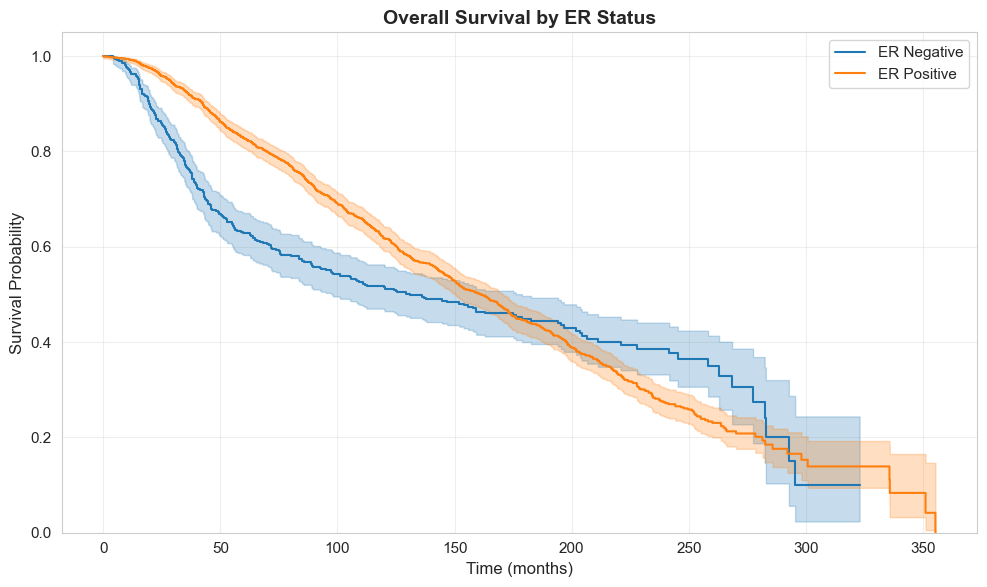

Log-rank test: p = 0.035047 (Significant)


In [21]:
# ER Status Comparison - Overall Survival (OS)
if 'ER Status' in df.columns:
    # Check value counts
    print(f"\nER Status distribution:")
    print(df['ER Status'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Positive': 'ER Positive', 'Negative': 'ER Negative'}
    km_by_group(df, 'ER Status', time_col='duration_os', event_col='event_os',
                title='Overall Survival by ER Status', label_map=label_map)

else:
    print("ER Status column not found in dataset")


Patients with ER-positive tumors had significantly longer median survival (161.1 months) compared with ER-negative patients (130.9 months). This suggests that ER status is a prognostic factor, with ER-positive tumors associated with more favorable outcomes and a clear survival advantage in the medium term. At 60 months (5 years), the survival difference is the most pronounced with a survival rate of 82.8% for ER positive patients and 62.9% for ER negative patients, highlighting the more aggressive nature of ER negative cancer in the inital years after diagnosis. 

Overall, **ER negative tumors** are more aggressive upfront, with a higher mortality rate in the first 5-10 years after diagnosis. Patients who survuve this inital high risk period may have a lower risk of reaccurance later on. **ER positive tumors** are less aggressive and more responsive to endocrine therapy, with a higher medium term survival. However, they carry a low-level risk of late reaccurance around 5-10 years after diagnosis, indicating an ongoing risk combined with mortality from other causes in an aging population. 


### 6.4.2 Human Epidermal growth factor Receptor 2 (HER2) Status


HER2 Status distribution:
HER2 Status
Negative    1732
Positive     247
Name: count, dtype: int64


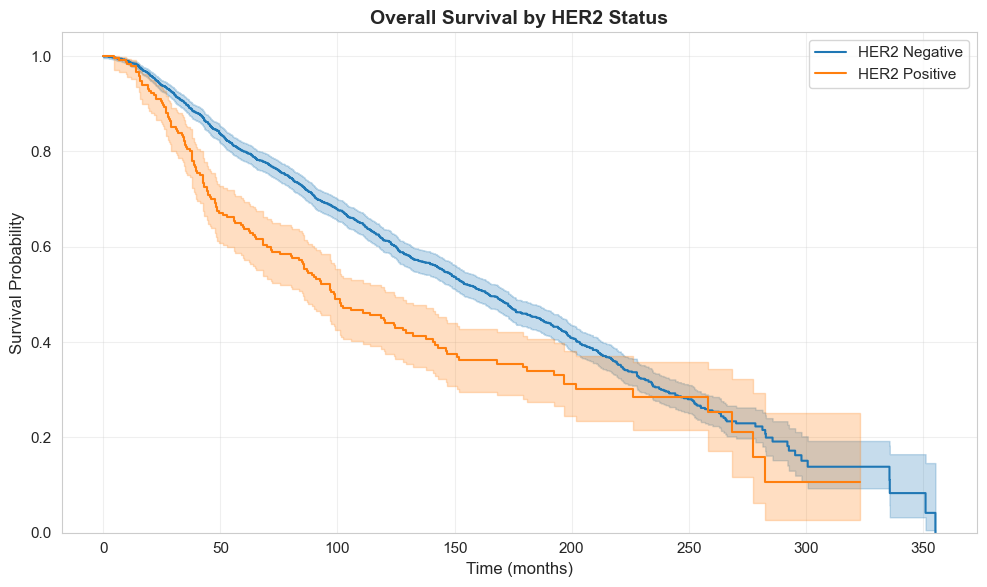

Log-rank test: p = 0.000009 (Highly significant)


In [22]:
# HER2 Status Comparison - Overall Survival (OS)
if 'HER2 Status' in df.columns:
    #Check value counts
    print(f"\nHER2 Status distribution:")
    print(df['HER2 Status'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Positive': 'HER2 Positive', 'Negative': 'HER2 Negative'}
    km_by_group(df, 'HER2 Status', time_col='duration_os', event_col='event_os',
                title='Overall Survival by HER2 Status', label_map=label_map)
    
else:
    print("HER2 Status column not found in dataset")


Overall survival differed significantly by HER2 status (log-rank p = 0.000009). The median survival differed vastly between HER2 Positive patients (survival of 98.7 months, roughly 8.2 years) and HER2 negative patients (survival of 164.6 months, roughly 13.7 years), differing about 5 years. After 5 years from diagnosis, the survival rate for HER2 negative patients is 80% and HER2 positive patients is 64.2%, with a 16% differece in survival. HER2-negative patients demonstrated substantially better survival, with higher survival probability throughout the entire follow-up period. HER2-positive patients showed poorer long-term survival. However, while the curves appear to converge after 20 years, this is due to the small number if patients remaining and is not clinically meaningful. 

### 6.4.3 Progesterone Receptor (PR) Status


PR Status distribution:
PR Status
Positive    1040
Negative     939
Name: count, dtype: int64


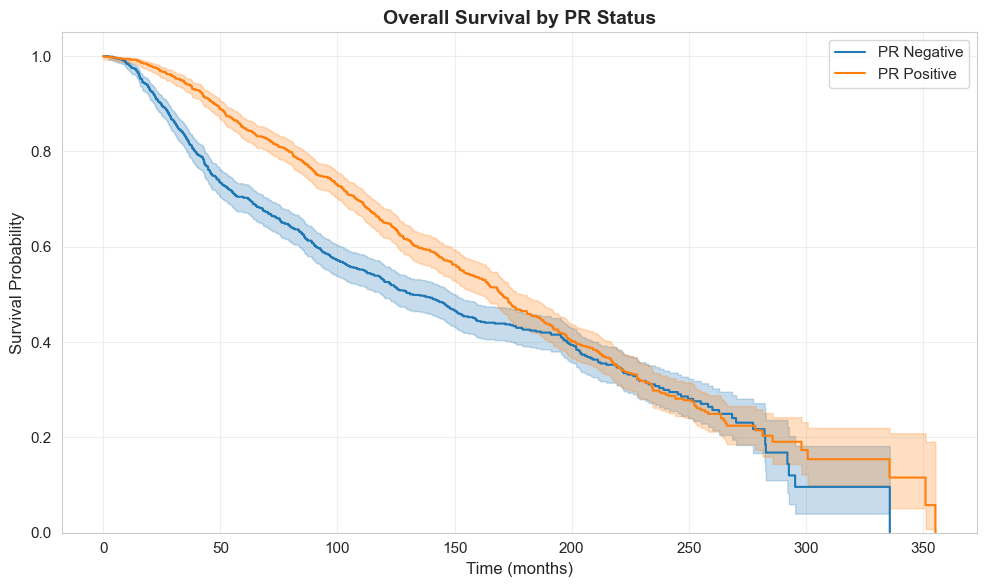

Log-rank test: p = 0.000083 (Highly significant)


In [23]:
# PR Status Comparison - Overall Survival (OS)
if 'PR Status' in df.columns:
    # Check value counts
    print(f"\nPR Status distribution:")
    print(df['PR Status'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Positive': 'PR Positive', 'Negative': 'PR Negative'}
    km_by_group(df, 'PR Status', time_col='duration_os', event_col='event_os',
                title='Overall Survival by PR Status', label_map=label_map)
else:
    print("PR Status column not found in dataset")


Overall survival differed significantly according to PR status (log-rank p = 0.000083). Patients with PR-positive tumors had a consistently higher probability of survival compared with PR-negative patients over the entire observation period. The median survival time for PR positive patients is 170.3 months (roughly 14.2 years) as compared to PR negative patients of 132.2 months (roughly 11 years), with a survival advantage of 3 years. After 60 months (5 years), the survival gap is pronounced, with the survival rate for PR positive patients being 84.9% while PR negative patients being 70.3%, showing the aggressive nature of PR negative cancer in the medium term. 

PR-positive tumors generally indicate that the cancer is hormone-driven and may respond better to hormonal (endocrine) therapy, such as tamoxifen or aromatase inhibitors. This is also often correlated to ER positivity, another tumor type that is sensitive to hormone signaling. 

The convergence of the survival curves aftr 15-20 years is a phenomenon that reveals PR positive tumors ot carry a low level risk of reaccurance in the long term while PR negative tumor patients who survive in the short term have a lower risk of events in the long term. 

### 6.4.4 PAM50 Molecular Subtypes


PAM50 Subtype distribution:
Pam50 + Claudin-low subtype
LumA           700
LumB           475
Her2           224
claudin-low    217
Basal          209
Normal         148
NC               6
Name: count, dtype: int64


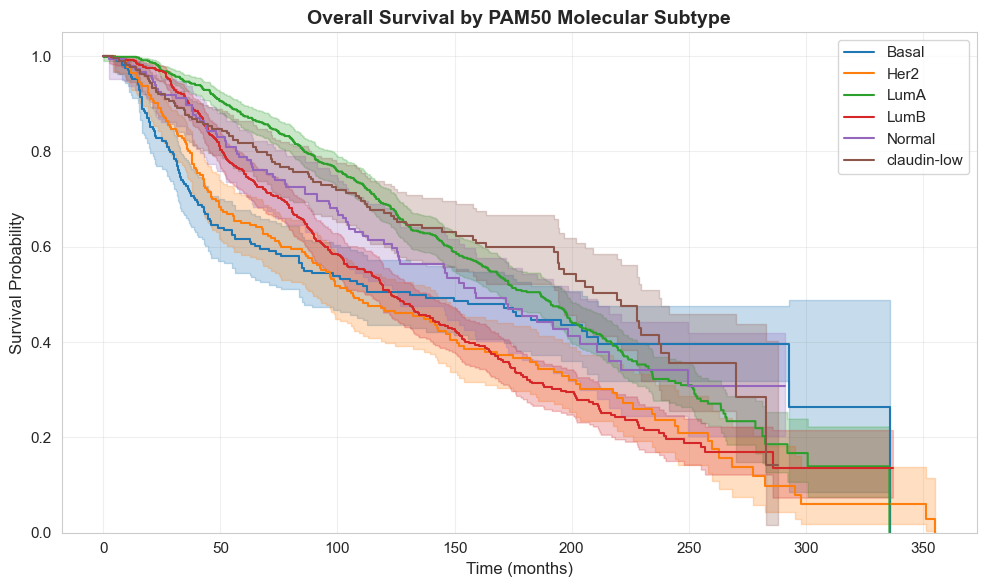

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [24]:
# PAM50 Molecular Subtype Comparison - Overall Survival (OS)
if 'Pam50 + Claudin-low subtype' in df.columns:
    # Check value counts
    print(f"\nPAM50 Subtype distribution:")
    print(df['Pam50 + Claudin-low subtype'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test (multigroup)
    km_by_group(df, 'Pam50 + Claudin-low subtype', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by PAM50 Molecular Subtype', 
                min_group_size=10)  # Require at least 10 patients per subtype
    
else:
    print("PAM50 + Claudin-low subtype column not found in dataset")


Survival varied significantly across PAM50 molecular subtypes (multigroup log-rank p < 0.001). The most favorable prognosis subtypes are **Claudin-low** with a median survival of 219.2 months, followed by **Luminal A** subtype with a median survival of 186.6 months, with the highest 5 year survival rate at 87.5%. Intermediate prognosis subtypes are Normal-like (median survival of 159.2 months) and No Class (NC) (median survival of 170.3 months). However, the poor prognosis subtypes by almost a 40-70 month difference are Basal-like (median survival of 130.9 months), Luminal B (median survival of 123.0 months), and lastly Her2-Enriched (median survival of 106.6 months).

There is a clear hierarchy of survival within these subtypes, with the highest survival rates in Claudin-low and Luminal A and the significantly poorer survival rates in Basal-like, Luminal B, and Her2-enriched subtypes. The poorer prognosis of Luminal B tumors justifies a more aggressive treatment (chemotherapy) compared to Luminal A tumors. Similarly, Her2-enriched and Basal-like subtypes require more intensive chemotherapy regimins and targeted therapies to combat their aggressive nature. However, this data does show that better prognosis, such as in Luminal A, still stands a risk as their survival prognosis declines after 10 years indicating a risk of late reaccurance in a hormone sensitive disease. 




### 6.4.5 Neoplasm Histologic Grade (Tumor Grade)


Neoplasm Histologic Grade distribution:
Neoplasm Histologic Grade
1.0    169
2.0    771
3.0    953
Name: count, dtype: int64


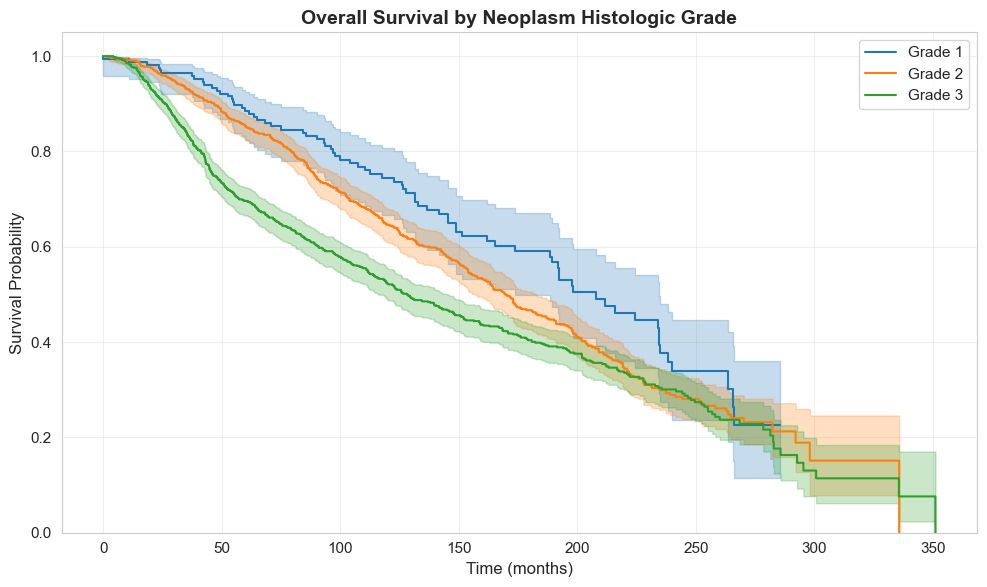

Multigroup log-rank test: p = 0.000002 (Highly significant)


In [25]:
# Neoplasm Histologic Grade Comparison - Overall Survival (OS)
if 'Neoplasm Histologic Grade' in df.columns:
    # Check value counts
    print(f"\nNeoplasm Histologic Grade distribution:")
    print(df['Neoplasm Histologic Grade'].value_counts().sort_index())
    
    label_map = {1.0: 'Grade 1', 2.0: 'Grade 2', 3.0: 'Grade 3'}
    
    # Create Kaplan-Meier curves and log-rank test (multigroup)
    km_by_group(df, 'Neoplasm Histologic Grade', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by Neoplasm Histologic Grade',
                label_map=label_map)
    
else:
    print("Neoplasm Histologic Grade column not found in dataset")


The OS by Neoplasm Histologic Grade results prove that the grade of tumors directly correlates with their clinical aggressiveness, with very different median survivals: Grade 1 (low grade) has 208 months, dropping to 169 months for Grade 2 (intermediate grade), then again in Grade 3 (high grade) tumors to 128 months. The 5 year survival benchmark highlights each grades differnces in the medium term prognosis, with Grade 1 and Grade 2 having exellent 5 year survival rates (88.5% and 85.2%), the rate is much lower for Grade 3 (69.6%). This gap widens at the 10 year benchmark, with almost 3/4 of Grade 1 patients surviving compared to just half of Grade 3 patients. 

This provides **strong evidence to justify treatment intensity**, as the poorer survival rate of Grade 3 is reason for consideration of chemotherapy. However, the prognosis for Grade 1 patients provides reason to de-escalate therapy or avoid chemotherapy. 


### 6.4.6 Lymph Node Examined Positive 


Lymph Node Group distribution:
lymph_node_group
0 nodes (N0)        993
1-3 nodes (N1)      604
4+ nodes (N2/N3)    307
Other                76
Name: count, dtype: int64


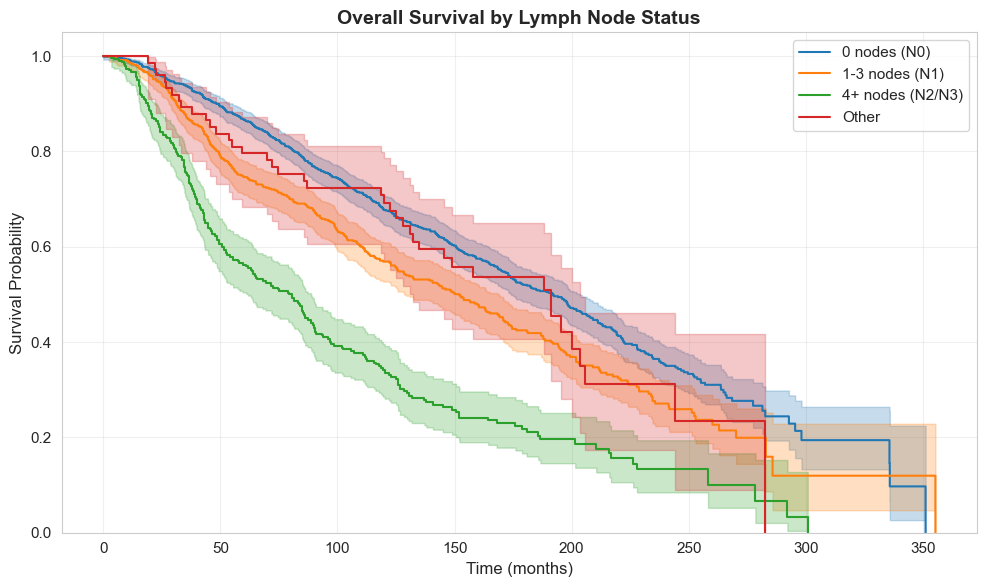

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [26]:
# Lymph Node Status Comparison - Overall Survival (OS)
if 'Lymph nodes examined positive' in df.columns:
    # Create a new column with clinically relevant lymph node status groups
    conditions = [
        (df['Lymph nodes examined positive'] == 0),
        (df['Lymph nodes examined positive'] >= 1) & (df['Lymph nodes examined positive'] <= 3),
        (df['Lymph nodes examined positive'] >= 4)
    ]
    choices = ['0 nodes (N0)', '1-3 nodes (N1)', '4+ nodes (N2/N3)']
    df['lymph_node_group'] = np.select(conditions, choices, default='Other')
    
    # Check value counts of the new groups
    print(f"\nLymph Node Group distribution:")
    print(df['lymph_node_group'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test using the new grouping column
    km_by_group(df, 'lymph_node_group', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by Lymph Node Status')
else:
    print("Lymph nodes examined positive column not found in dataset")


The OS by Lymph Node Status proves this variable is a significant predictor, with an extremely low p value (p < 0.0001) and a clear decrease in survival as the number of lymph nodes increases (once cancer has spread to lymph nodes, the worse the long term prognosis). 

The median survival of patients with 0 positive lymph nodes is 191.9 months, dropping to 152.1 months for patients with 1-3 positive lymph nodes, then again to 80.4 months (dropping ~6 years) for patients with 4+ positive lymph nodes. The 5 year survival benchmark illustrates this escalting risk, as 0 positive lymph's rate is excellent at 86.7%, then falling to 74.6% for 2-3 positive lymph nodes, then to a concerning 56.2% for 4+ positive lymph nodes (meaning nearly half of the patients have passed away by the 5 year mark).

This means that A patient's N-status is **one of the most powerful pieces of information a clinician has to determine prognosis and communicate risk to a patient**, justifying intensive treatment for the patients with more affected lymph nodes and increase the ikelihood of surgery and extra radiation therapy. 

### 6.4.7 Tumor Size 


Tumor Size Quartile distribution:
tumor_size_quartile
Q2               523
Q1 (Smallest)    501
Q3               496
Q4 (Largest)     435
Name: count, dtype: int64


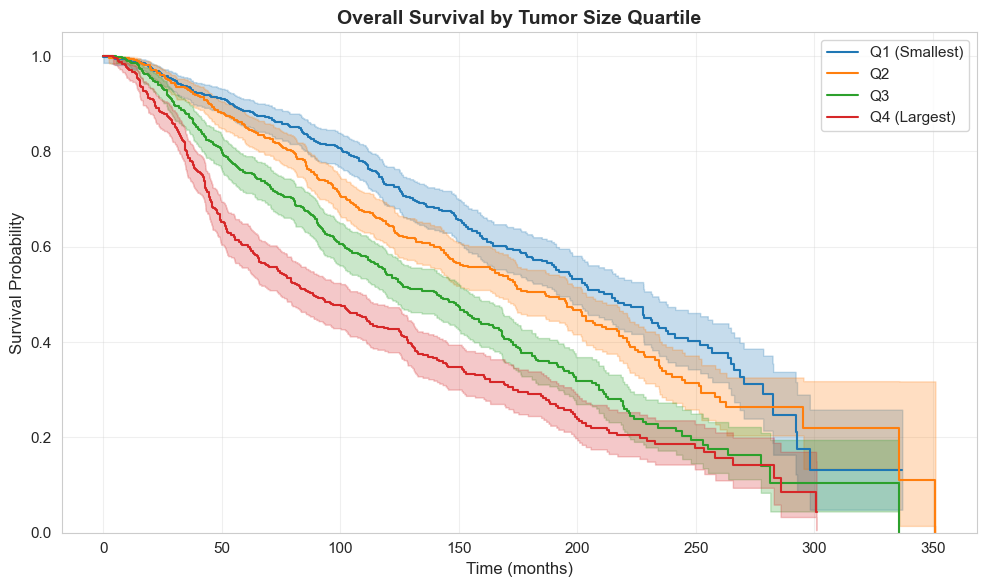

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [27]:
# Tumor Size Comparison - Overall Survival (OS)
if 'Tumor Size' in df.columns:
    try:     #grouping 
        df['tumor_size_quartile'] = pd.qcut(df['Tumor Size'], q=4, 
                                            labels=["Q1 (Smallest)", "Q2", "Q3", "Q4 (Largest)"])
        
        # Check value counts of the new groups
        print(f"\nTumor Size Quartile distribution:")
        print(df['tumor_size_quartile'].value_counts())
        
        # Create Kaplan-Meier curves and log-rank test using the new quartile column
        km_by_group(df, 'tumor_size_quartile', 
                    time_col='duration_os', event_col='event_os',
                    title='Overall Survival by Tumor Size Quartile')
    except Exception as e:
        print(f"Could not create quartiles for Tumor Size. Error: {e}")
else:
    print("Tumor Size column not found in dataset")


The OS by Tumor size proves it is another highly significant predictor, with an extremely low p-value and a clear decrease in survival as tumor size increases, proving is correlation to a patients long term prognosis. The median survival in Q1 (smallest quartile of tumor size) is excellent at 214.4 months, progressively worsening in each quartile until 88.7 months for Q4 (largest tumor sizes). This difference of over 10 years is highly concerning, highlighted especially at the 5 year survival benchmark where Q1 has a survival rate of 88.5% (excellent) and drops to 60.4% for Q4, meaning nearly 40% of patients die within 5 years. The 10 year survival benchmark widens this survival gap, with Q1 having 72.9% survival rate but Q4 hvaing a 42.6% survival rate. 

Tumor size is a critical compoennt of determinign a patients stage and overall risk, providing strong evidence to guide the intensity of treatment as Q1 tumors could be managed with less intensive treatment but larger size groups should be considered a high risk situation and considered for more invasice, intensive treatments. Detecting cancers when they are small (in Q1) translates directly into a massive survival benefit for patients.

### 6.4.8 Tumor Stage


Tumor Stage distribution:
(Note: This variable has 514 missing values which will be excluded)
Tumor Stage
0.0     12
1.0    501
2.0    825
3.0    118
4.0     10
Name: count, dtype: int64


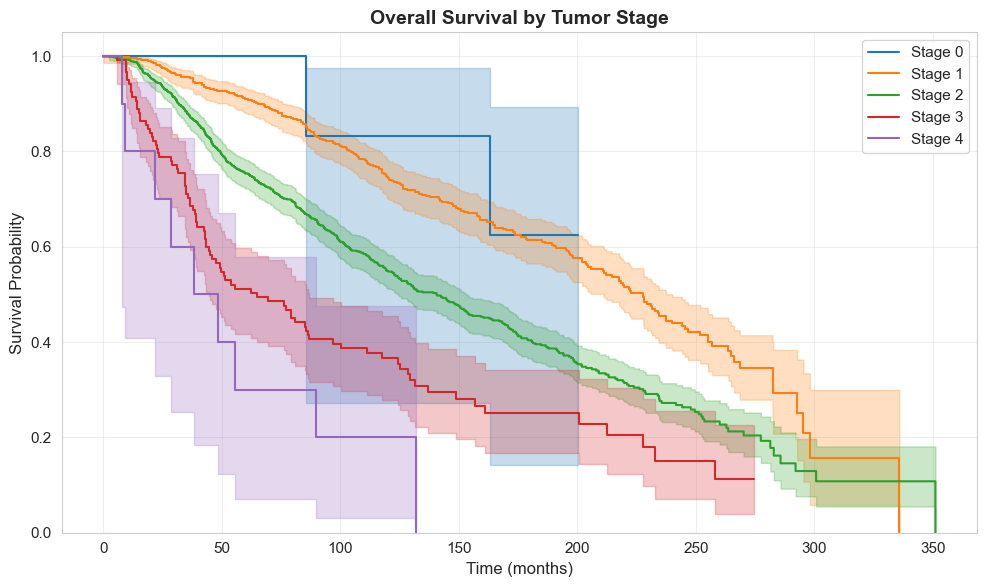

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [28]:
# Tumor Stage Comparison - Overall Survival (OS)
if 'Tumor Stage' in df.columns:
    # Check value counts
    print(f"\nTumor Stage distribution:")
    print(f"(Note: This variable has {df['Tumor Stage'].isnull().sum()} missing values which will be excluded)")
    print(df['Tumor Stage'].value_counts().sort_index())
    
    # Create a label map for a clearer legend
    unique_stages = sorted(df['Tumor Stage'].dropna().unique())
    label_map = {stage: f'Stage {int(stage)}' for stage in unique_stages}
    
    # Create Kaplan-Meier curves and log-rank test
    km_by_group(df, 'Tumor Stage', 
                time_col='duration_os', event_col='event_os',
                title='Overall Survival by Tumor Stage',
                label_map=label_map)
else:
    print("Tumor Stage column not found in dataset")


The OS by Tumor Stage is a final significant and extremely powerful indicator, with a low p-value and a clear stepwise decrease in survival as tumor stage at diagnosis increases. The median survival in Stage 0 is so long that it cannot be calculated by the data and Stage 1 is 227.8 months, both with excellent prognosis. Stage 2 remains with a good prognosis, but a noticable drop occurs to 140.6 months. By Stage 3/4, the median survival plummets to 64.9 months then again to 38.1 months. The 5 year survival benchmark reillustrates the same trendws, with survival rates in Stage 0 (100%), Stage 1 (90.9%), and Stage 2 (75.4%) all remaining high, while Stage 3 drops to 51.2% and Stage 4 plummets to 30% of patients remaining alive. 

This justifies Stage 3 treatment plans being more intensive (often combinations of chemo, surgery, radiation) in later stages to combat the more aggressive tumors while Stage 4 is considered "incurable" with a goal of managing symptoms/prolonging life. 


### Analysis for RFS for different treatments - LEAVE/ REMOVE ?



CHEMOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)

Chemotherapy distribution:
Chemotherapy
No     1567
Yes     412
Name: count, dtype: int64


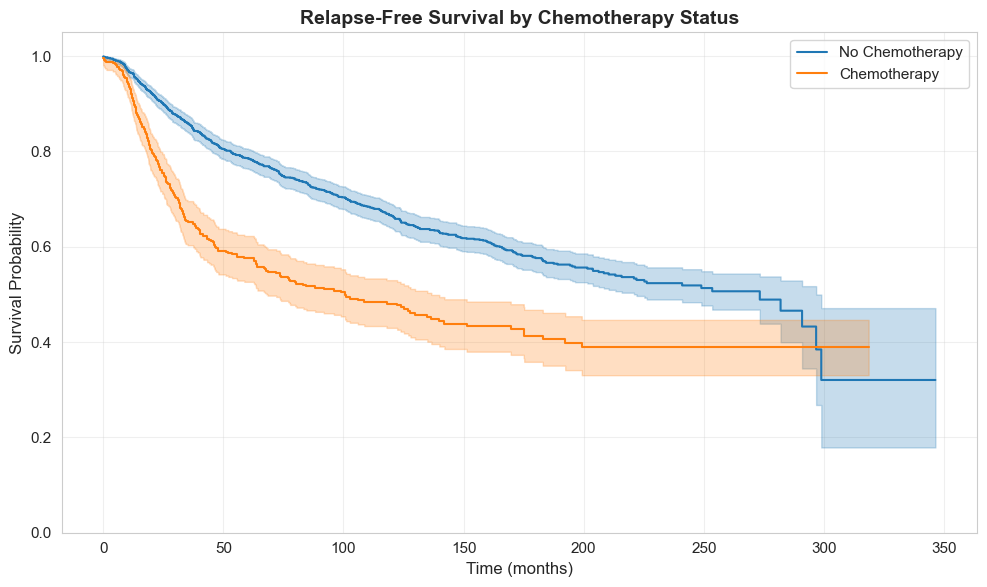

Log-rank test: p = 0.000000 (Highly significant)

HORMONE THERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)

Hormone Therapy distribution:
Hormone Therapy
Yes    1216
No      763
Name: count, dtype: int64


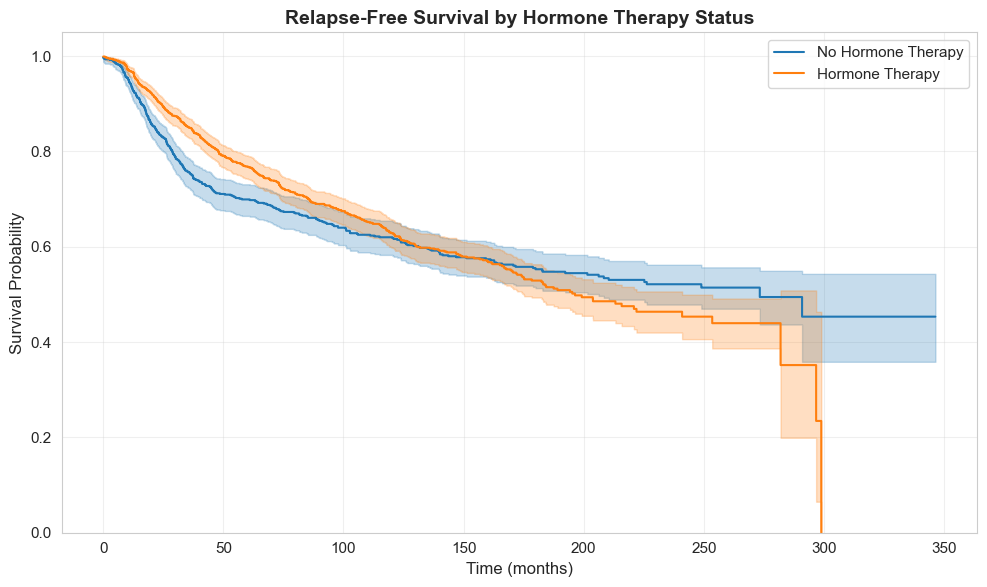

Log-rank test: p = 0.746255 (Not significant)

RADIOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)

Radio Therapy distribution:
Radio Therapy
Yes    1173
No      806
Name: count, dtype: int64


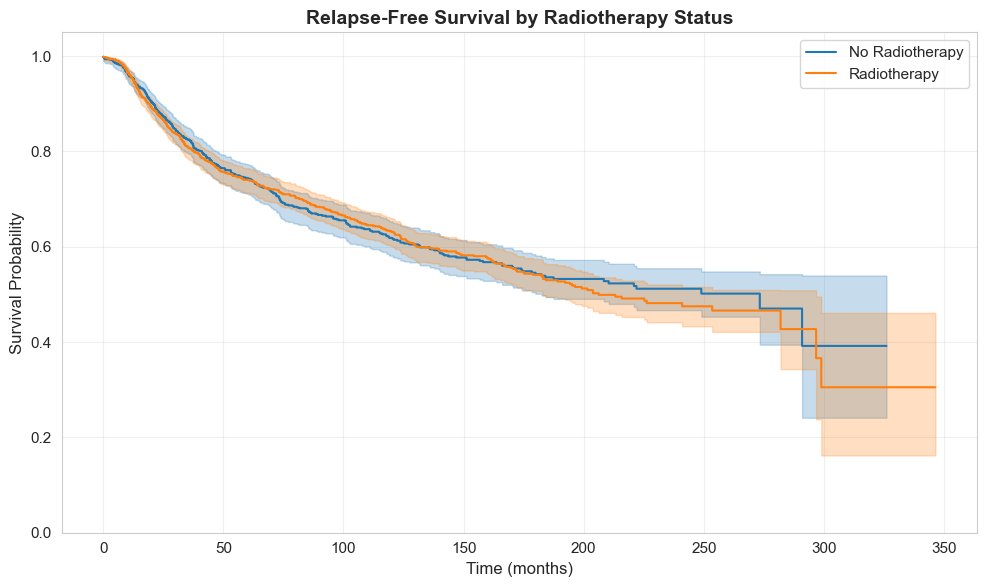

Log-rank test: p = 0.823569 (Not significant)


In [29]:
# 4.4.6 Treatment Comparisons - Relapse-Free Survival (RFS)


# Check if RFS data is available
if 'event_rfs' in df.columns and 'duration_rfs' in df.columns:
    # Chemotherapy
    if 'Chemotherapy' in df.columns:
        print("\n" + "="*60)
        print("CHEMOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)")
        print("="*60)
        print(f"\nChemotherapy distribution:")
        print(df['Chemotherapy'].value_counts())
        label_map = {'Yes': 'Chemotherapy', 'No': 'No Chemotherapy'}
        km_by_group(df, 'Chemotherapy', time_col='duration_rfs', event_col='event_rfs',
                    title='Relapse-Free Survival by Chemotherapy Status', label_map=label_map)
    else:
        print("Chemotherapy column not found in dataset")
    
    print("\n" + "="*60)
    
    # Hormone Therapy
    if 'Hormone Therapy' in df.columns:
        print("="*60)
        print("HORMONE THERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)")
        print("="*60)
        print(f"\nHormone Therapy distribution:")
        print(df['Hormone Therapy'].value_counts())
        label_map = {'Yes': 'Hormone Therapy', 'No': 'No Hormone Therapy'}
        km_by_group(df, 'Hormone Therapy', time_col='duration_rfs', event_col='event_rfs',
                    title='Relapse-Free Survival by Hormone Therapy Status', label_map=label_map)
    else:
        print("Hormone Therapy column not found in dataset")
    
    print("\n" + "="*60)
    
    # Radio Therapy
    if 'Radio Therapy' in df.columns:
        print("="*60)
        print("RADIOTHERAPY COMPARISON - RELAPSE-FREE SURVIVAL (RFS)")
        print("="*60)
        print(f"\nRadio Therapy distribution:")
        print(df['Radio Therapy'].value_counts())
        label_map = {'Yes': 'Radiotherapy', 'No': 'No Radiotherapy'}
        km_by_group(df, 'Radio Therapy', time_col='duration_rfs', event_col='event_rfs',
                    title='Relapse-Free Survival by Radiotherapy Status', label_map=label_map)
    else:
        print("Radio Therapy column not found in dataset")
else:
    print("RFS data (event_rfs, duration_rfs) not available for treatment comparisons")


AGE AT DIAGNOSIS COMPARISON - OVERALL SURVIVAL (OS)

Age Group distribution:
Age_Group
<50 years       424
50-70 years    1025
>70 years       531
Name: count, dtype: int64


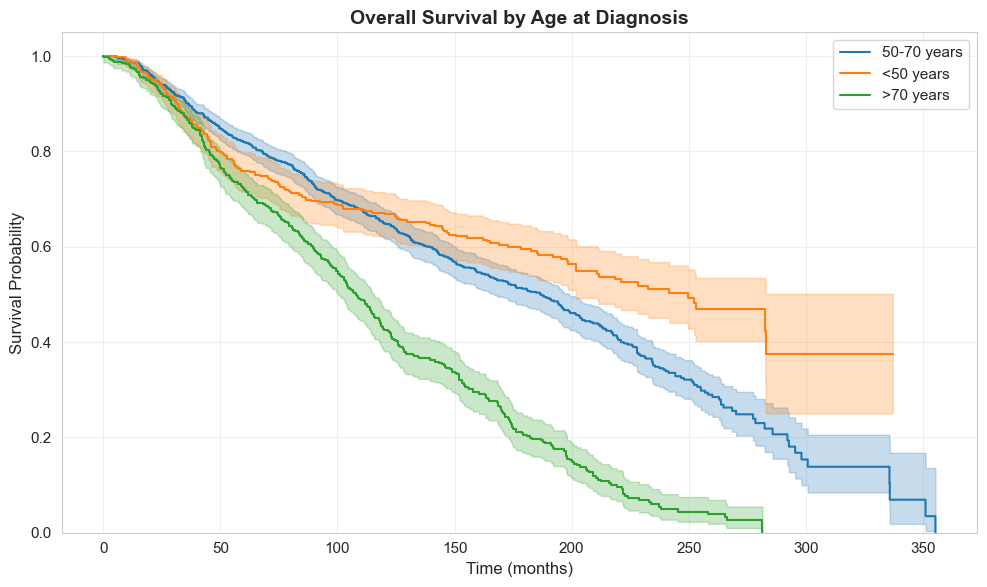

Multigroup log-rank test: p = 0.000000 (Highly significant)


In [30]:
# 4.4.8 Age at Diagnosis Comparison - Overall Survival (OS)

if 'Age at Diagnosis' in df.columns:
    print("="*60)
    print("AGE AT DIAGNOSIS COMPARISON - OVERALL SURVIVAL (OS)")
    print("="*60)
    
    # Create age groups
    df_age = df.copy()
    df_age['Age_Group'] = pd.cut(df_age['Age at Diagnosis'], 
                                  bins=[0, 50, 70, 100], 
                                  labels=['<50 years', '50-70 years', '>70 years'])
    
    # Check value counts
    print(f"\nAge Group distribution:")
    print(df_age['Age_Group'].value_counts().sort_index())
    
    # Create Kaplan-Meier curves and log-rank test (multigroup)
    km_by_group(df_age, 'Age_Group', time_col='duration_os', event_col='event_os',
                title='Overall Survival by Age at Diagnosis', 
                min_group_size=10)
else:
    print("Age at Diagnosis column not found in dataset")


A significant difference in overall survival was observed across age groups (multigroup log-rank test p < 0.001). Patients diagnosed under 50 years demonstrated the best survival outcomes across the follow-up period. Patients aged 50–70 years showed intermediate survival, while those diagnosed over 70 years had markedly poorer survival. These findings suggest that younger patients experience more favorable long-term survival following breast cancer diagnosis compared with older individuals.

INFERRED MENOPAUSAL STATE COMPARISON - OVERALL SURVIVAL (OS)

Menopausal State distribution:
Inferred Menopausal State
Post    1555
Pre      424
Name: count, dtype: int64


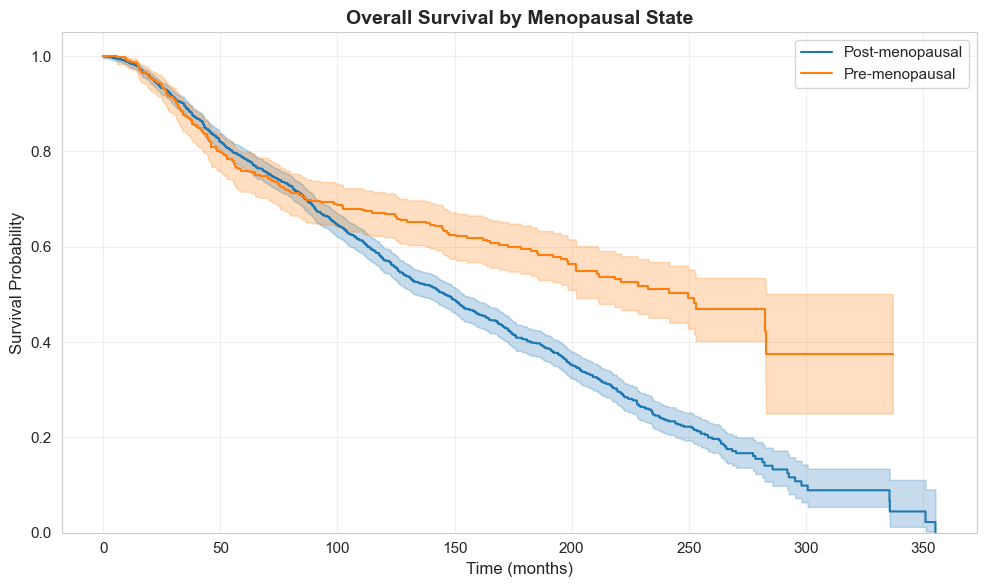

Log-rank test: p = 0.000000 (Highly significant)


In [31]:
# 4.4.10 Inferred Menopausal State Comparison - Overall Survival (OS)

if 'Inferred Menopausal State' in df.columns:
    print("="*60)
    print("INFERRED MENOPAUSAL STATE COMPARISON - OVERALL SURVIVAL (OS)")
    print("="*60)
    
    # Check value counts
    print(f"\nMenopausal State distribution:")
    print(df['Inferred Menopausal State'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Pre': 'Pre-menopausal', 'Post': 'Post-menopausal'}
    km_by_group(df, 'Inferred Menopausal State', time_col='duration_os', event_col='event_os',
                title='Overall Survival by Menopausal State', label_map=label_map)
else:
    print("Inferred Menopausal State column not found in dataset")


Pre-menopausal women had consistently better survival outcomes across the entire follow-up period compared to post-menopausal women. The log-rank test confirmed a highly significant difference between the two groups (p < 0.001), indicating that menopausal state is a meaningful prognostic factor for overall survival.

In [32]:
# 4.4.11 Primary Tumor Laterality Comparison - Overall Survival (OS)

if 'Primary Tumor Laterality' in df.columns:
    print("="*60)
    print("PRIMARY TUMOR LATERALITY COMPARISON - OVERALL SURVIVAL (OS)")
    print("="*60)
    
    # Check value counts
    print(f"\nTumor Laterality distribution:")
    print(df['Primary Tumor Laterality'].value_counts())
    
    # Create Kaplan-Meier curves and log-rank test
    label_map = {'Left': 'Left breast', 'Right': 'Right breast'}
    km_by_group(df, 'Primary Tumor Laterality', time_col='duration_os', event_col='event_os',
                title='Overall Survival by Primary Tumor Laterality', label_map=label_map)
else:
    print("Primary Tumor Laterality column not found in dataset")


Primary Tumor Laterality column not found in dataset


The two groups demonstrated nearly overlapping survival trajectories, indicating comparable overall survival regardless of tumor laterality. Since the variable does not contribute useful predictive information and does not affect survival, including it in further modelling would add noise rather than value. 

 -> Therefore, tumor laterality can be safely excluded from subsequent analyses.

In [33]:
# Drop Primary Tumor Laterality (non-predictive based on KM analysis above)
# The two groups demonstrated nearly overlapping survival trajectories, 
# indicating comparable overall survival regardless of tumor laterality.

if 'Primary Tumor Laterality' in df.columns:
    print("="*60)
    print("REMOVING PRIMARY TUMOR LATERALITY")
    print("="*60)
    print("\nReason: Overlapping survival trajectories observed in KM analysis above")
    print("       (comparable overall survival regardless of tumor laterality)")
    
    n_before = len(df.columns)
    df = df.drop(columns=['Primary Tumor Laterality'])
    n_after = len(df.columns)
    
    print(f"\n✓ Removed 'Primary Tumor Laterality' column")
    print(f"  Columns: {n_before} → {n_after}")
else:
    print("'Primary Tumor Laterality' column not found in dataset (may have been removed earlier)")


'Primary Tumor Laterality' column not found in dataset (may have been removed earlier)


## 6.5 Log-Minus-Log Plot (Bridge between CPH and KM models)

CPH models assume the hazard ratio between groups remains constant over time (known as the **proportional hazards assumption**). CPH gives us hazard ratios but if the relative risk between groups change over time, the hazard ratios can be misleading. We are using Log-minus-log survival plots to determine if the proportional hazards assumption is plausible, a necessary step before Cox modeling to ensure that the idea of a constant hazard ratio is reasonable. 

Parallel curves mean proportional hazards assumption are plausible (differences between groups stay stable) but if they cross/diverge, assumptions may not hold (risk differences change over time). 

In [34]:
# Assesses proportional hazards asusmption for a given prognosis variable using log-minus-log plot and numeric check
def check_proportional_hazards(df, prognostic_variable, duration_col, event_col, variable_type='continuous'):
    group_col = f"{prognostic_variable}_group"
    if prognostic_variable not in df.columns:
        print(f"Error: Column '{prognostic_variable}' not found in the dataframe.")
        return
        
    local_df = df.copy()
    
    if variable_type == 'continuous': 
        try:
            # Always use group_col for consistency
            local_df[group_col] = pd.qcut(local_df[prognostic_variable], q=3, labels=["low", "mid", "high"], duplicates='drop')
        except ValueError as e:   
            print(f"Could not create tertiles for '{prognostic_variable}'. Might have too few unique values. Error: {e}")
            return
    elif variable_type == 'ordinal':
        local_df[group_col] = local_df[prognostic_variable]
    elif variable_type == 'lymph_nodes':     #custom grouping for lymph nodes
        conditions = [
            (local_df[prognostic_variable] == 0),
            (local_df[prognostic_variable] >= 1) & (local_df[prognostic_variable] <= 3),
            (local_df[prognostic_variable] >= 4)
        ]
        choices = ['0 nodes', '1-3 nodes', '4+ nodes']
        local_df[group_col] = np.select(conditions, choices, default='Other')
    else:
        print(f"Error: Unknown variable_type '{variable_type}'.")
        return

    # Convert all group labels to strings before sorting to prevent TypeError
    groups = sorted([str(g) for g in local_df[group_col].unique() if pd.notna(g)])
    
    print(f"\nChecking Proportional Hazards for '{prognostic_variable}'")
    print("Group distribution:\n", local_df[group_col].value_counts())

    # log-minus-log plot
    fig, ax = plt.subplots(figsize=(8, 7))
    all_survival_probs = []
    median_survival_data = []
    key_times = [12, 36, 60, 120, 180, 240, 350]

    # Filter data for current group
    for group_name in groups:
        # Ensure we compare the string version of the group name
        kmf = KaplanMeierFitter()
        group_data = local_df.loc[local_df[group_col].astype(str) == group_name, [duration_col, event_col]].dropna()
        if len(group_data) < 20:
            print(f"Skipping group '{group_name}' due to small sample size (< 20).")
            continue  
        # Fit KM model, plot log-log transformation
        kmf.fit(group_data[duration_col], 
                group_data[event_col], 
                label=f"{prognostic_variable} ({group_name})")
        kmf.plot_loglogs(ax=ax)  

        survival_at_key_times = kmf.survival_function_at_times(key_times).rename(group_name)
        all_survival_probs.append(survival_at_key_times)
        median_survival_data.append({'Group': group_name, 'Median Survival (months)': kmf.median_survival_time_})     


    ax.set_title(f"Log-Minus-Log Survival Plot by {prognostic_variable} Group")
    ax.set_xlabel("log(Time in months)")  
    ax.set_ylabel("log(-log(Survival Probability))")
    ax.grid(True)
    ax.legend()  
    plt.tight_layout()
    plt.show()


    if median_survival_data:
        print("\nSurvival Metrics by Group")
        median_df = pd.DataFrame(median_survival_data).set_index('Group')
        print(median_df.round(1))
        
        print(f"\nSurvival Probability at Key Time Points")
        prob_df = pd.concat(all_survival_probs, axis=1)
        print((prob_df * 100).round(1))

    # Tiny numeric sanity check for proportionality (didactic)
    # Compare the gap between groups at an early and a later time
    # If the gap changes a lot, hazards may not be proportional
    if len(groups) > 1: 
        def lml_at(kmf_instance: KaplanMeierFitter, t: float) -> float:
            s = float(kmf_instance.predict(t))
            # Add a small epsilon to prevent log(0) or log(1) errors
            s = np.clip(s, 1e-9, 1 - 1e-9)
            return np.log(-np.log(s))
        
        # Define early and late time points for the check (in months)  - 25, 75% percentiles
        landmark_early, landmark_late = 36.0, 120.0
        
        # Compare the lowest and highest risk groups
        low_risk_group = groups[0]
        high_risk_group = groups[-1]

        fits = {}
        for group_name in [low_risk_group, high_risk_group]:
            # Ensure we compare the string version of the group name
            group_data = local_df.loc[local_df[group_col].astype(str) == group_name, [duration_col, event_col]].dropna()
            if not group_data.empty:
                kmf_instance = KaplanMeierFitter().fit(group_data[duration_col], group_data[event_col])
                fits[group_name] = {
                    "lml_early": lml_at(kmf_instance, landmark_early),
                    "lml_late":  lml_at(kmf_instance, landmark_late),  
                }

        if low_risk_group in fits and high_risk_group in fits:
            gap_early = fits[high_risk_group]["lml_early"] - fits[low_risk_group]["lml_early"]
            gap_late  = fits[high_risk_group]["lml_late"]  - fits[low_risk_group]["lml_late"]
            delta_gap = gap_late - gap_early
            
            print(f"\nProportionality Numeric Check for {prognostic_variable}")
            print(f"Comparing groups '{high_risk_group}' vs '{low_risk_group}'")
            print(f"Gap high−low at {int(landmark_early)} d: {gap_early:.3f}")
            print(f"Gap high−low at {int(landmark_late)} d:  {gap_late:.3f}")
            print(f"Change in gap (late − early): {delta_gap:.3f}")
            print("Rule of thumb: small change suggests proportional hazards is reasonable")
            print("Large change suggests exploring stratification or time-varying effects in the Cox model")
            print("\n---------------------\n")




In [35]:
# df.info()


Checking Proportional Hazards for 'Tumor Size'
Group distribution:
 Tumor Size_group
low     853
high    649
mid     453
Name: count, dtype: int64


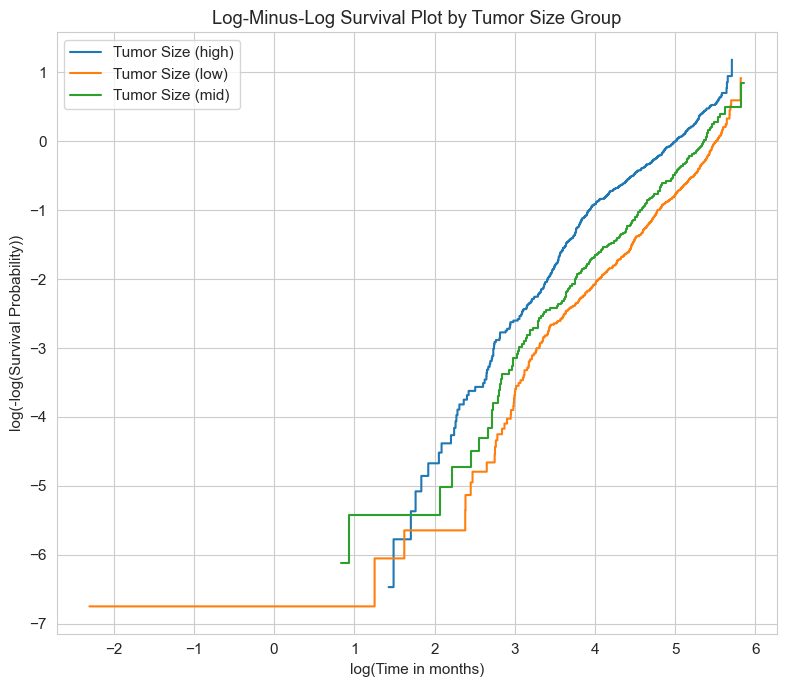


Survival Metrics by Group
       Median Survival (months)
Group                          
high                      102.1
low                       203.0
mid                       159.2

Survival Probability at Key Time Points
     high   low   mid
12   97.4  99.2  98.9
36   81.7  92.7  90.8
60   64.8  86.6  80.8
120  44.5  69.0  61.9
180  29.4  55.6  44.7
240  18.4  38.5  27.6
350   3.8   8.2   9.7

Proportionality Numeric Check for Tumor Size
Comparing groups 'mid' vs 'high'
Gap high−low at 36 d: -0.739
Gap high−low at 120 d:  -0.522
Change in gap (late − early): 0.217
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Nottingham prognostic index'
Group distribution:
 Nottingham prognostic index_group
mid     673
low     661
high    645
Name: count, dtype: int64


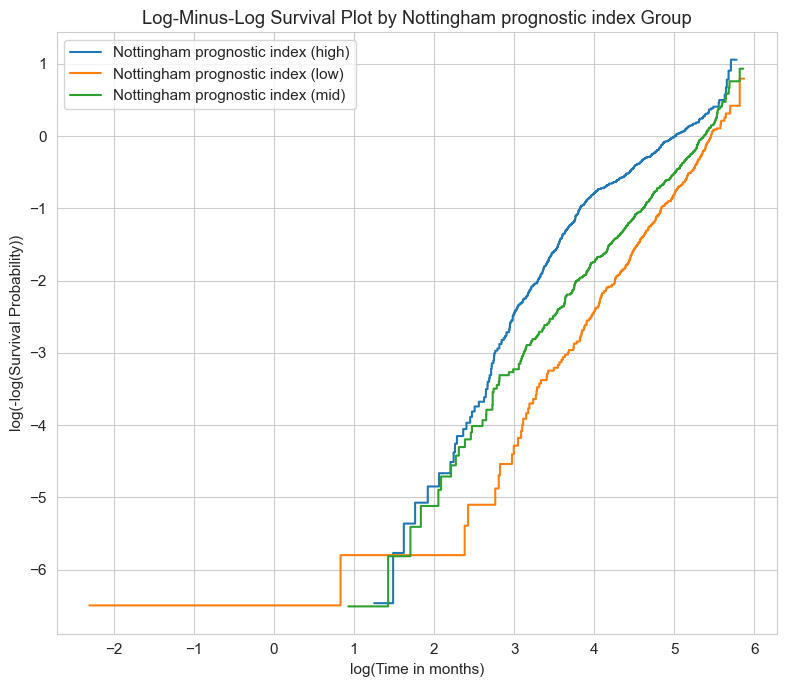


Survival Metrics by Group
       Median Survival (months)
Group                          
high                       97.0
low                       197.7
mid                       167.1

Survival Probability at Key Time Points
     high   low   mid
12   97.8  99.4  98.2
36   78.6  95.7  91.1
60   61.5  89.4  82.6
120  44.0  71.8  61.5
180  31.7  54.8  46.8
240  23.0  34.3  31.3
350   5.6  10.9   7.9

Proportionality Numeric Check for Nottingham prognostic index
Comparing groups 'mid' vs 'high'
Gap high−low at 36 d: -0.952
Gap high−low at 120 d:  -0.525
Change in gap (late − early): 0.427
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Lymph nodes examined positive'
Group distribution:
 Lymph nodes examined positive_group
0 nodes      993
1-3 nodes    604
4+ nodes     307
Other         76
Name: count, dtype: int64


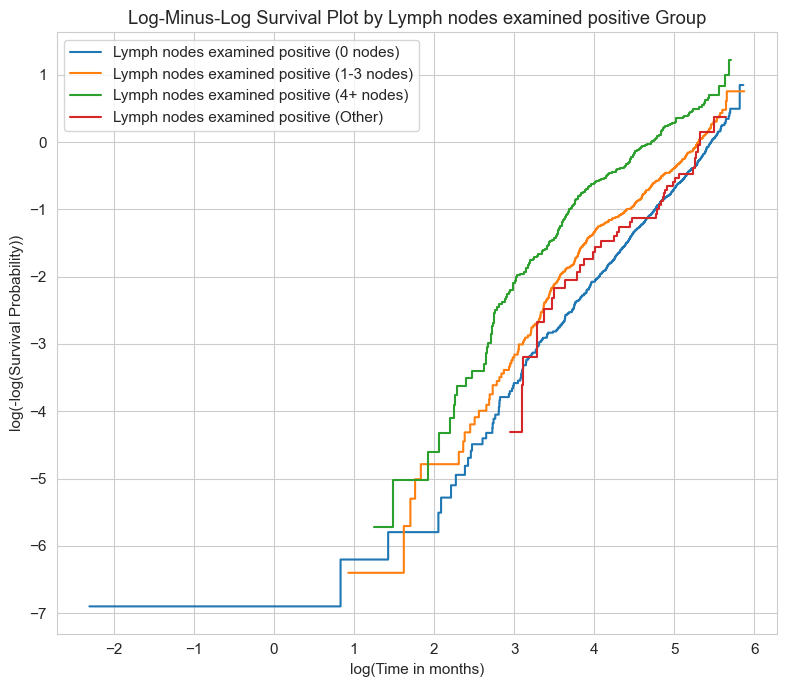


Survival Metrics by Group
           Median Survival (months)
Group                              
0 nodes                       191.9
1-3 nodes                     152.1
4+ nodes                       80.4
Other                         191.0

Survival Probability at Key Time Points
     0 nodes  1-3 nodes  4+ nodes  Other
12      98.9       98.5      96.7  100.0
36      93.7       87.0      75.1   89.2
60      86.7       74.6      56.2   79.6
120     67.7       56.9      34.0   69.2
180     52.0       42.5      21.7   53.6
240     35.3       27.1      13.4   31.1
350      9.7       11.9       0.0    0.0

Proportionality Numeric Check for Lymph nodes examined positive
Comparing groups 'Other' vs '0 nodes'
Gap high−low at 36 d: 0.554
Gap high−low at 120 d:  -0.056
Change in gap (late − early): -0.610
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Chec

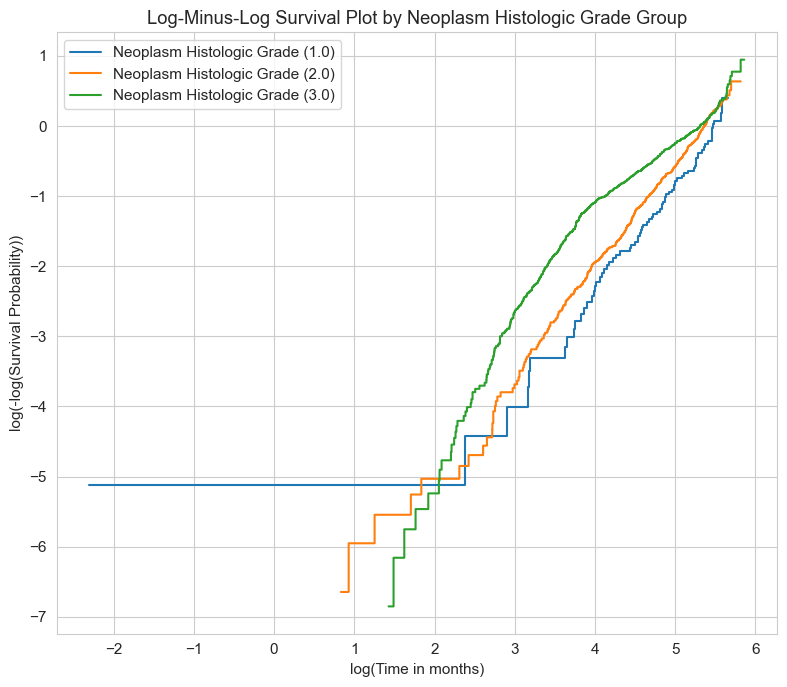


Survival Metrics by Group
       Median Survival (months)
Group                          
1.0                       208.0
2.0                       169.6
3.0                       128.4

Survival Probability at Key Time Points
      1.0   2.0   3.0
12   98.8  99.1  97.8
36   96.4  93.1  83.2
60   88.5  85.2  69.6
120  74.5  64.6  52.2
180  59.1  46.7  40.4
240  35.9  28.9  30.1
350  22.7   0.0   7.6

Proportionality Numeric Check for Neoplasm Histologic Grade
Comparing groups '3.0' vs '1.0'
Gap high−low at 36 d: 1.613
Gap high−low at 120 d:  0.791
Change in gap (late − early): -0.821
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'ER Status'
Group distribution:
 ER Status_group
Positive    1507
Negative     473
Name: count, dtype: int64


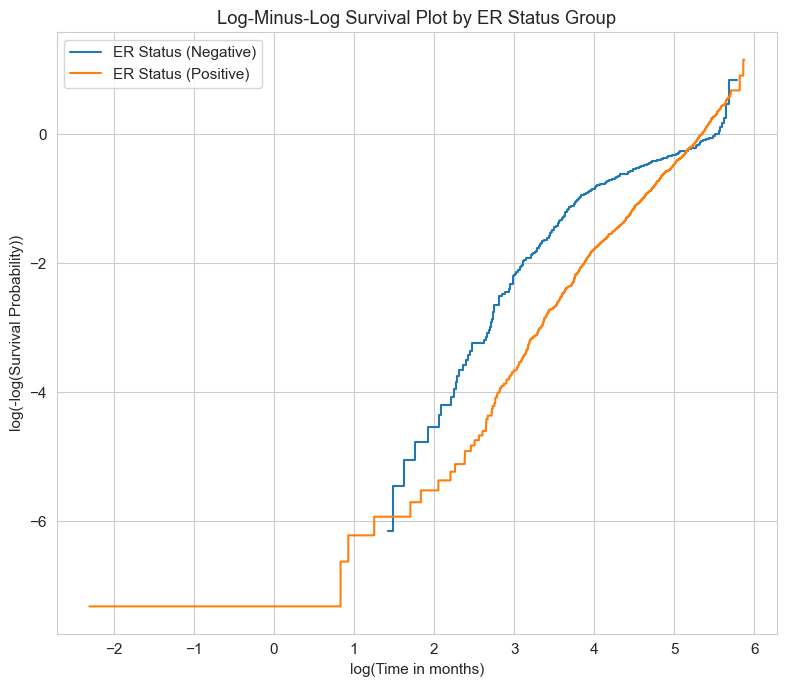


Survival Metrics by Group
          Median Survival (months)
Group                             
Negative                     130.9
Positive                     161.1

Survival Probability at Key Time Points
     Negative  Positive
12       96.2      99.2
36       76.6      92.3
60       62.9      82.8
120      51.5      61.7
180      44.9      44.5
240      38.6      27.4
350      10.0       8.3

Proportionality Numeric Check for ER Status
Comparing groups 'Positive' vs 'Negative'
Gap high−low at 36 d: -1.207
Gap high−low at 120 d:  -0.319
Change in gap (late − early): 0.887
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'HER2 Status'
Group distribution:
 HER2 Status_group
Negative    1732
Positive     247
Name: count, dtype: int64


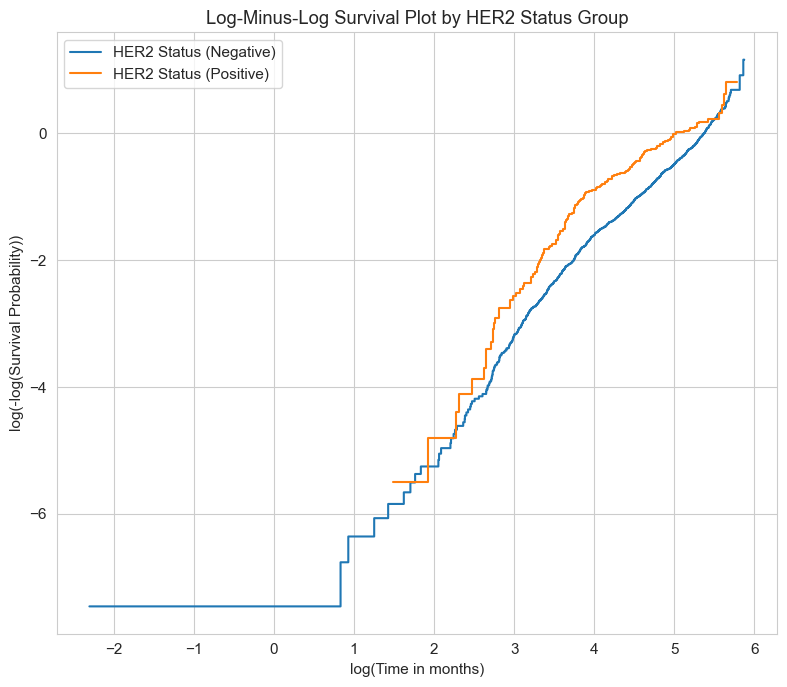


Survival Metrics by Group
          Median Survival (months)
Group                             
Negative                     164.6
Positive                      98.7

Survival Probability at Key Time Points
     Negative  Positive
12       98.5      98.0
36       89.7      80.6
60       80.0      64.2
120      61.3      44.6
180      46.0      34.7
240      29.8      28.4
350       8.3      10.5

Proportionality Numeric Check for HER2 Status
Comparing groups 'Positive' vs 'Negative'
Gap high−low at 36 d: 0.686
Gap high−low at 120 d:  0.501
Change in gap (late − early): -0.185
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Pam50 + Claudin-low subtype'
Group distribution:
 Pam50 + Claudin-low subtype_group
LumA           700
LumB           475
Her2           224
claudin-low    217
Basal          209
Normal         14

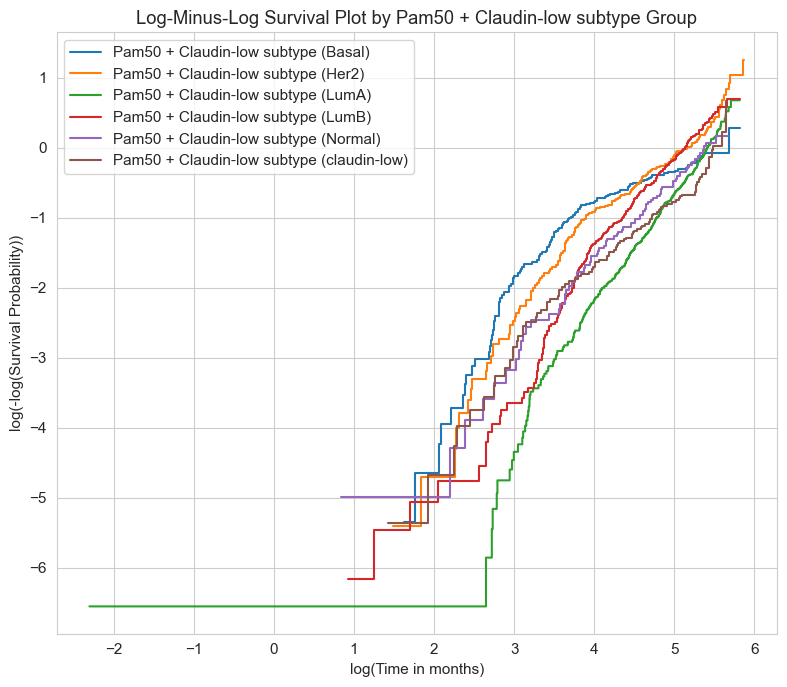


Survival Metrics by Group
             Median Survival (months)
Group                                
Basal                           130.9
Her2                            106.6
LumA                            186.6
LumB                            123.0
Normal                          159.2
claudin-low                     219.2

Survival Probability at Key Time Points
     Basal  Her2  LumA  LumB  Normal  claudin-low
12    95.7  96.4  99.9  99.1    98.0         97.7
36    72.7  80.6  94.7  90.5    89.8         87.7
60    61.6  65.0  87.5  75.4    78.8         81.8
120   50.6  47.1  69.0  51.0    60.6         67.1
180   45.5  36.6  50.7  32.7    45.6         59.9
240   39.7  23.6  32.2  20.2    34.2         37.8
350    0.0   5.9   0.0  13.5    30.8         14.3

Proportionality Numeric Check for Pam50 + Claudin-low subtype
Comparing groups 'claudin-low' vs 'Basal'
Gap high−low at 36 d: -0.887
Gap high−low at 120 d:  -0.536
Change in gap (late − early): 0.351
Rule of thumb: small change

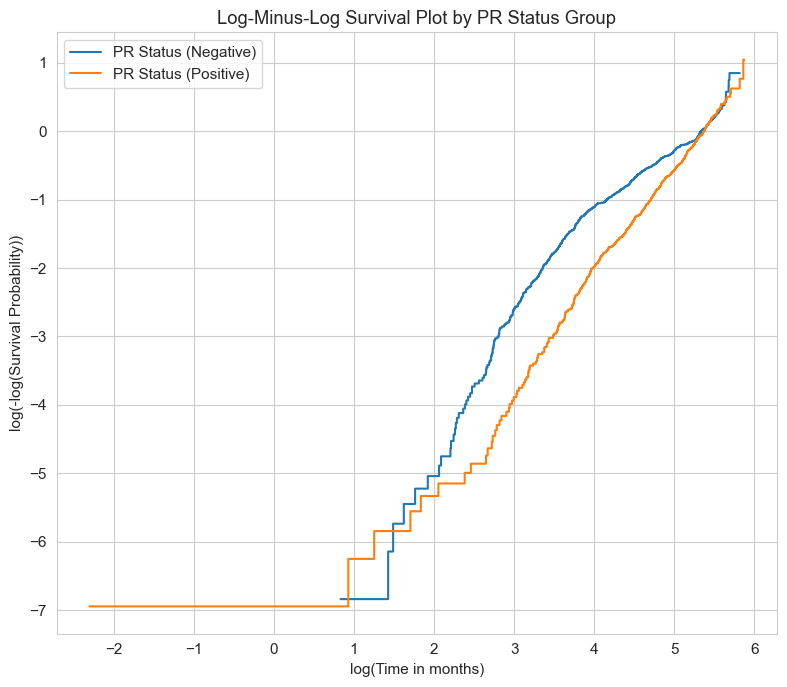


Survival Metrics by Group
          Median Survival (months)
Group                             
Negative                     132.3
Positive                     170.3

Survival Probability at Key Time Points
     Negative  Positive
12       97.6      99.2
36       82.5      94.1
60       70.3      84.9
120      52.7      65.1
180      42.6      46.5
240      29.9      29.3
350       0.0      11.6

Proportionality Numeric Check for PR Status
Comparing groups 'Positive' vs 'Negative'
Gap high−low at 36 d: -1.149
Gap high−low at 120 d:  -0.398
Change in gap (late − early): 0.750
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------


Checking Proportional Hazards for 'Tumor Stage'
Group distribution:
 Tumor Stage_group
2.0    825
1.0    501
3.0    118
0.0     12
4.0     10
Name: count, dtype: int64
Skipping group '0.0' due to small sample size (< 20).
Skipping g

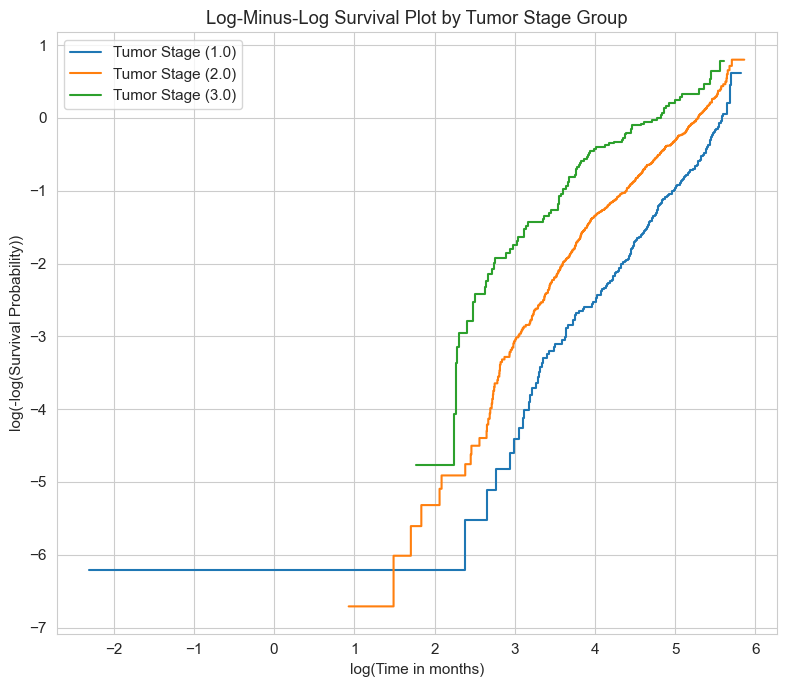


Survival Metrics by Group
       Median Survival (months)
Group                          
1.0                       227.8
2.0                       140.6
3.0                        64.9

Survival Probability at Key Time Points
      1.0   2.0   3.0
12   99.6  98.9  92.4
36   95.6  87.8  70.2
60   90.9  75.4  51.2
120  74.3  54.9  36.6
180  61.3  40.4  25.1
240  44.5  27.2  15.0
350   0.0  10.8  11.2

Proportionality Numeric Check for Tumor Stage
Comparing groups '4.0' vs '0.0'
Gap high−low at 36 d: 20.052
Gap high−low at 120 d:  2.178
Change in gap (late − early): -17.874
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------

PH assumption against RFS

Checking Proportional Hazards for 'Tumor Size'
Group distribution:
 Tumor Size_group
low     853
high    649
mid     453
Name: count, dtype: int64


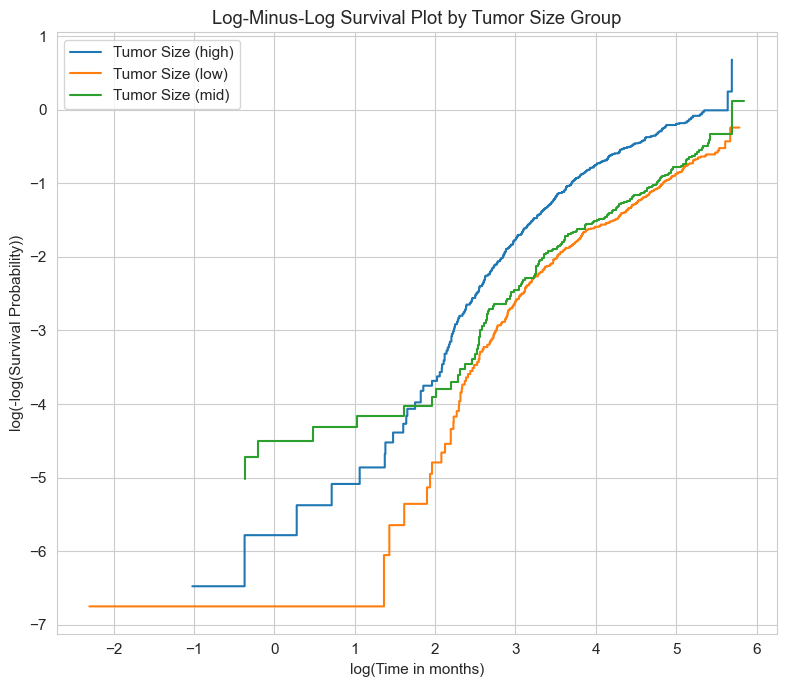


Survival Metrics by Group
       Median Survival (months)
Group                          
high                      108.6
low                       290.9
mid                       226.2

Survival Probability at Key Time Points
     high   low   mid
12   92.5  97.0  96.7
36   72.1  86.5  84.8
60   60.9  81.1  79.8
120  47.7  70.7  68.4
180  40.8  61.8  58.5
240  37.1  58.0  49.0
350  13.9  45.7  32.6

Proportionality Numeric Check for Tumor Size
Comparing groups 'mid' vs 'high'
Gap high−low at 36 d: -0.684
Gap high−low at 120 d:  -0.667
Change in gap (late − early): 0.017
Rule of thumb: small change suggests proportional hazards is reasonable
Large change suggests exploring stratification or time-varying effects in the Cox model

---------------------



In [36]:
variables_to_check = {
    'Tumor Size': 'continuous',
    'Nottingham prognostic index': 'continuous',
    'Lymph nodes examined positive': 'lymph_nodes',
    'Neoplasm Histologic Grade': 'ordinal', 
    'ER Status': 'ordinal',
    'HER2 Status': 'ordinal',
    'Pam50 + Claudin-low subtype': 'ordinal', 
    'PR Status': 'ordinal', 
    'Tumor Stage': 'ordinal'
}

for var_name, var_type in variables_to_check.items():
    # Check the PH assumption for chosen var against Overall Survival
    check_proportional_hazards(df, 
                            prognostic_variable=var_name, 
                            duration_col='Overall Survival (Months)', 
                            event_col='event_os', 
                            variable_type=var_type)


# Check the PH assumption for Tumor Size against RFS
print("PH assumption against RFS")
check_proportional_hazards(df, 
                           prognostic_variable='Tumor Size', 
                           duration_col='Relapse Free Status (Months)', 
                           event_col='event_rfs')      #just changed the col




Tumor size has a clear dose-response relationship, with larger tumors leading to significantly worse survival (median survival for "high" tumor size group is 102.1 months), almost half of the "low" tumor size group (median survival of 203.0 months). **The "change in gap" is 0.217 for OS and 0.017 for RSF, which allows us to to assume the PH assumption is reasonable for Tumor Size** and we can set it as a standard variable in the Cox model. 

Nottingham Prognostic Index (NPI) higher scores are strongly associated with worse outcomes, with the median survival dropping from 197.7 months for the low-NPI group to 97.0 months for the high-NPI group. The **"change in gap" is 0.427, suggesting some convergance of the lines over time but within an acceptable range, meaning the PH assumption is mostly reasonable** and we can include it as a standard variable within the Cox model (while noting prognostic power is stronger in earlier years). 

Lymph Nodes Examined Positive is a very strong predictor, as patients with 0 positive nodes have a median survival of 191.9 months, dropping to 80.4 months for patients with 4+ positive nodes. This is highlighting the extent of nodal involvement as a critical determinant of patients outcomes. The **"change in gap" is -0.610, which is a large change and indicates the hazard ratio between node-negative and node-positive gorups is not constant, meaning the PH assumption is questionable for lymph node status.** To include this in the Cox model, we will consider a special approach (stratification) for the varaible.

Neoplasm Histologic Grade shows a clear, stepwise impact on survival, with Grade 1 tumors having a median survival of 208.0 months, decreasing to 128.4 months by Grade 3, confirming the higher-grade tumors are more aggresive. The **"change in gap" is -0.821, violating the proportional hazards assumption with the plotlines for Grade 1 and Grade 3 not being parallel.** The relative risk of Grade 3 tumors are much higher early on but decrease after time compared to Grade 1 tumors. If, but likely not, this was set as a varaible in the Cox model, it would require stratification to address the issue. 

ER Status and PR Status show similar results, with ER-positive and PR-positive tumors having significantly better prognoses with median survival advantages between 2.5-3 years over their negative counterparts. Both markers have **large "change in gaps" (0.887 and 0.75) violating the PH assumption**. The ER/PR positive survival advantage is stronger in the first 10-15 years but it diminished over time, with the curves on the graph intersecting at 180 months representing the risk of late accurence in hormone sensitive cancers. These will not be included in the Cox model without stratification.

HER2 Status shows a drastically worse prognosis associated with HER2-positive status, with a median survival that is over 5 years shorter than HER2-negative, reflecting HER2-positive's aggressive nature. The **"change in gap" is 0.185, a small change that means the PH assumption is reasonable** and can be included within the Cox model.  

The PAM50 Subtypes reestablishes the heirarchy of BC subtypes, as Luminal A and Claudin-Low have the best prognosis while Luminal B,  Basal-like, and HER2-enriched have significantly worse. The **"change in gap" between Basal-like and Claudin-low is 0.351, a small to moderate change that means the PH assumption is mostly reasonable across the subtypes**. However, there are some non-proportionalities within specific pairs of subtypes (Luminal A and Basal-like) but as a whole, PAM50 can be included in the Cox model (could be considered a strong candidate for stratification).

Tumor Stage is a powerful predictor of survival, with a sharp decrease in survival when stages increase, with the median survival being 5.4 years. However, the **"change in gap" is huge, -17.874, skewed by the small sample sizes wihtin Stage 0 and Stage 4, meaning the PH assumption is severly violated**. This is the number 1 candidate for stratification and cannot be included within the Cox model without it. 


### Overall
#### Variables that Satisfy the PH Assumption 
These can be included directly in the CPH model 
* Tumor Size
* HER2 Status
* Nottingham prognostic index
* PAM50 (should consider stratification)

#### Variables that Violate the PH Assumption 
These require specific handling in the CPH model (need the strata arguement)
* Tumor Size (requires stratification)
* ER Status/ PR Status (require stratification)
* Neoplasm Histologic Grade (require stratification)
* Lymph Nodes examined positive (require stratification)



# 7.0 Cox Proportional Hazards (CPH)

A semi-parametric regression model for survival data that models the hazard of an event (death) based on predictor variables, allowing us to see the effect of multiple variables at once. It produces Hazard Ratios (HR) that **tell us how much the risk of an event is multiplied for each unit increase in a variable while holding the others constant**. CPH has a core assumption known as the Proportional Hazard Assumption, which assumes hat the ratio between any 2 groups remains constant over time. 

Here, we ask: **By how much does a variable increase risk while controlling other factors?**

Competing Risk Event Distribution:
competing_risk_event
1    803
0    744
2    433
Name: count, dtype: int64


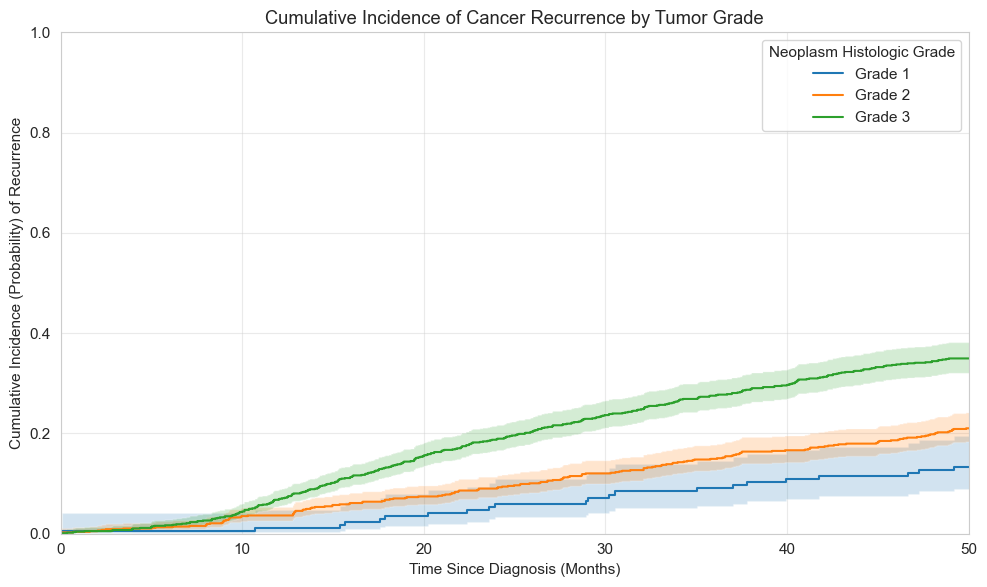

In [44]:
# Create the competing risk event type column
#event 0: censored, event 1: recurrence, event 2: death without recurrence
conditions = [
    (df['event_rfs'] == 1),         #event 1: recurrence 
    (df['event_os'] == 1) & (df['event_rfs'] == 0)      
]
choices = [1, 2]
df['competing_risk_event'] = np.select(conditions, choices, default=0)

# The relevant time is the duration until the first event (relapse or death), we use RFS for this
time_to_event = df['Relapse Free Status (Months)']
grouping_variable = df['Neoplasm Histologic Grade']

print("Competing Risk Event Distribution:")
print(df['competing_risk_event'].value_counts())


# --- 2. Calculate and Plot the Cumulative Incidence ---
fig, ax = plt.subplots(figsize=(10, 6))

for grade in sorted(grouping_variable.unique()):
    if pd.isna(grade):
        continue
    idx = (grouping_variable == grade)

    # Estimate CIF with pointwise confidence intervals
    time_points, cif, conf_int = cumulative_incidence_competing_risks(
        event=df.loc[idx, 'competing_risk_event'],
        time_exit=time_to_event[idx],
        conf_type="log-log"
    )
    
    # With our coding, the first row (index 0) of the output is for event 1 (death)
    ax.step(time_points, cif[0], where="post", label=f"Grade {int(grade)}")
    ax.fill_between(time_points, conf_int[0, 0], conf_int[0, 1], step="post", alpha=0.2)

ax.set_title("Cumulative Incidence of Cancer Recurrence by Tumor Grade")
ax.set_xlabel("Time Since Diagnosis (Months)")
ax.set_ylabel("Cumulative Incidence (Probability) of Recurrence")
ax.set_xlim(0, 50)
ax.set_ylim(0, 1.0)
ax.legend(title="Neoplasm Histologic Grade")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Grade 3 tumors (high grade) are more aggressive, high-risk tumors, reaching a ~38% incidence of recurrence by 50 months and ~60% by 150 months. This group has a constant and high rate of recurrence, especially within the first decade after diagnosis as the majority of occurences happening in early stages. This justifies aggressive treatment upfront to combat the early risk, with small CI bands proving our confidence in this high-risk assesment. 

Grade 2 tumors (intermediate grade) revealed a steady, persistant, and lifelong threat of recurrence, with the risk not being front-loaded. This means patients cannot be considered "cured" after 5-10 years and will require lifelong surveillance to ensure no recurrence. The narrow CI bands indicate that this steady risk is a very reliable finding for this group. 

Grade 1 tumors (low grade) overall have the lowest risk, increasing more noticably after 150 months and more so after 220, indicating an excellent short/meduim term prognosis but a risk of very late recurrence. An inital flatness confirms the tumors are slow growing with a low risk of recurrence, requiring less aggressive upfront treatment (patients can potentially avoid chemotherapy). The CI bands are the widest of all 3 groups, indicating our estimates for very late recurrence are less certain (expected, as less patients remain in the study after 15-20 years). The clinical challenge for this group is to identify which patients would benefit from extended therapy and monitoring beyond 5-10 years. 

## 7.1 Multivariate Cox Proportional Hazards Model

Estimates the effect of each predictor while controlling the effects of the others. 

In [38]:
import utils

In [60]:
age_bins = [0, 50, 65, 100]  # <50, 50-65, >65
age_labels = ['Age_L50', 'Age_M50_65', 'Age_G65']
npi_bins = [0, 2.4, 3.4, 5.4, 10]
npi_labels = ['NPI_Good', 'NPI_Moderate1', 'NPI_Moderate2', 'NPI_Poor']

# Add stratification columns back from original data
strat_cols = [
    'Tumor Stage', 
    'Neoplasm Histologic Grade', 
    'ER Status', 
    'PR Status', 
    'Pam50 + Claudin-low subtype',
    'Age_Stratum',          
    'NPI_Stratum'
]

cols_to_exclude_entirely = [ 
    'Age at Diagnosis',                    #redundant because stratified version is already used
    'Nottingham prognostic index',         #redundant because stratified version is already used
    'Tumor Size',                          #redundant because used in NPI
    'Cohort',                              #not needed
    'Lymph nodes examined positive'        #redundant because used in NPI
]


# Create new categorical columns in the training and validation sets
X_train_features = X_train.copy()
X_val_features = X_val.copy()
X_test_features = X_test.copy()
X_train_features['Age_Stratum'] = pd.cut(X_train_features['Age at Diagnosis'], bins=age_bins, labels=age_labels, right=False, include_lowest=True).astype('object')
X_val_features['Age_Stratum'] = pd.cut(X_val_features['Age at Diagnosis'], bins=age_bins, labels=age_labels, right=False, include_lowest=True).astype('object')
X_train_features['NPI_Stratum'] = pd.cut(X_train_features['Nottingham prognostic index'], bins=npi_bins, labels=npi_labels, right=False, include_lowest=True).astype('object')
X_val_features['NPI_Stratum'] = pd.cut(X_val_features['Nottingham prognostic index'], bins=npi_bins, labels=npi_labels, right=False, include_lowest=True).astype('object')
X_test_features['Age_Stratum'] = pd.cut(X_test_features['Age at Diagnosis'], bins=age_bins, labels=age_labels, right=False, include_lowest=True).astype('object')
X_test_features['NPI_Stratum'] = pd.cut(X_test_features['Nottingham prognostic index'], bins=npi_bins, labels=npi_labels, right=False, include_lowest=True).astype('object')

# all_cols_to_exclude = strat_cols + ['Age at Diagnosis', 'Nottingham prognostic index', 'Tumor Size','Cohort']
modeling_feature_cols = [col for col in X_train_features.columns if col not in strat_cols and col not in cols_to_exclude_entirely]
numeric_cols, categorical_cols = utils.detect_feature_types(X_train_features[modeling_feature_cols])


# Safety checks
required_cols = ['duration_os', 'event_os'] 
for col in required_cols:
    if col not in y_train.columns or col not in y_val.columns:
        raise NameError(f"Column '{col}' not found in y_train or y_val. Please check your data splits.")

# 1) Detect feature types and build preprocessor with utils
cox_preprocessor = utils.build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    num_strategy="median",
    cat_strategy="most_frequent"
)

# 2) Fit on TRAIN ONLY and transform splits
cox_preprocessor.fit(X_train_features[modeling_feature_cols])
X_train_cox_prep = utils.to_dataframe(cox_preprocessor, X_train_features[modeling_feature_cols])
X_val_cox_prep = utils.to_dataframe(cox_preprocessor, X_val_features[modeling_feature_cols])
X_test_cox_prep = utils.to_dataframe(cox_preprocessor, X_test_features[modeling_feature_cols])


X_train_cox = pd.concat([X_train_cox_prep, X_train_features[strat_cols].reset_index(drop=True)], axis=1)
X_val_cox = pd.concat([X_val_cox_prep, X_val_features[strat_cols].reset_index(drop=True)], axis=1)
X_test_cox  = pd.concat([X_test_cox_prep, X_test_features[strat_cols].reset_index(drop=True)],    axis=1)


# 3) Build modeling frames for lifelines
train_cox_df = pd.concat([X_train_cox, y_train[["duration_os", "event_os"]]], axis=1)
val_cox_df = pd.concat([X_val_cox, y_val[["duration_os", "event_os"]]],   axis=1)
test_cox_df = pd.concat([X_test_cox, y_test[["duration_os", "event_os"]]],   axis=1)

# train_cox_df = pd.concat([X_train_cox, y_train.reset_index(drop=True)], axis=1)
# val_cox_df   = pd.concat([X_val_cox,   y_val.reset_index(drop=True)],   axis=1)

nan_mask = train_cox_df.isnull().any(axis=1)
num_nans = nan_mask.sum()
if num_nans > 0:
    print(f"ATTENTION: {num_nans} rows found with NaN values in the final modeling data. Dropping them to proceed.")
    print(train_cox_df.isnull().sum())
    train_cox_df.dropna(inplace=True)
    val_cox_df.dropna(inplace=True)
    test_cox_df.dropna(inplace=True)



# 4) Fit Cox PH with Efron ties and a small L2 penalizer for stability
cph_model = CoxPHFitter(penalizer=0.1)
cph_model.fit(train_cox_df, 
              duration_col="duration_os", 
              event_col="event_os", 
              strata=strat_cols)

print("--- Multivariable Cox model summary ---")
cph_model.print_summary(
    decimals=3,
    columns=["coef", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
)

# 5) Concordance baseline
cindex_train = float(cph_model.concordance_index_)
cindex_val = float(cph_model.score(val_cox_df, scoring_method="concordance_index"))
print(f"\nConcordance | train {cindex_train:.3f} | validation {cindex_val:.3f}")

# Keep objects for next steps
cox_feature_names = X_train_cox.columns.tolist()

ATTENTION: 1162 rows found with NaN values in the final modeling data. Dropping them to proceed.
num__Mutation Count                                     479
cat__Type of Breast Surgery_Breast Conserving           479
cat__Type of Breast Surgery_Mastectomy                  479
cat__Cellularity_High                                   479
cat__Cellularity_Low                                    479
cat__Cellularity_Moderate                               479
cat__Chemotherapy_No                                    479
cat__Chemotherapy_Yes                                   479
cat__HER2 Status_Negative                               479
cat__HER2 Status_Positive                               479
cat__Hormone Therapy_No                                 479
cat__Hormone Therapy_Yes                                479
cat__Inferred Menopausal State_Post                     479
cat__Inferred Menopausal State_Pre                      479
cat__Integrative Cluster_1                              479
cat

model,lifelines.CoxPHFitter
duration col,'duration_os'
event col,'event_os'
penalizer,0.1
l1 ratio,0.0
strata,"[Tumor Stage, Neoplasm Histologic Grade, ER St..."
baseline estimation,breslow
number of observations,505
number of events observed,283
partial log-likelihood,-238.064
time fit was run,2025-11-26 00:24:51 UTC



Concordance | train 0.676 | validation 0.772


Over all, the Concordance Index is 0.676 and the validation C-index is 0.772 (a 0.5 is random choice and the 1.0 is perfect), suggesting it is reasonably good at ranking patients by their risk of death. A higher score in the validation set is explained by our using a smaller dataset, it is a sign our model is not overfitting. 

The strongest predictor is **num_Mutation Count**, with a p-value of 0.038 and EXP(COEF) = 1.053, meaning for every one-tear increase in age at diagnosis, the patients risk of death increases by 5.3%. These findings indicate that measuring mutation count would help clinicians identify patients with a worse prognosis who might benefit from more aggressive treatment. 

The predictor **Integrative Cluster_4ER**, while not statistically significant by p> 0.05 is still close. It has EXP(COEF) = 0.635. This result still provides a strong hypothesis that patients with this predictor subtype might have a better prognosis. 

Treatment indicators (Type of Breast Surgery, Chemotherapy, Hormone Therapy, Radio Therapy) show high p-values (>0.70) and extremely wide confidence intervals (CIs). Clinically, these are indicators of a treatment decision, not independent prognostic factors. Patients who receive treatments like Chemotherapy or Radiotherapy have a worse initial prognosis (higher risk stratification).


## 7.2 Proprotional Hazards Assumption Check

Models main assumption is that the effect of each variable (its Hazard Ratio) is constant over time. 

We use a built-in lifelines function that performs a statistical test for each variable and plots the "Schoenfeld residuals" for any that might violate the assumption.


**What we are looking for**

* Statistical Test: A p-value greater than 0.05 for a variable suggests it meets the assumption
* Residual Plot: The plot should look like random noise with no obvious trend. A clear slope or pattern in the plot is a red flag that the variable's effect changes over time

Running PH check on the independent covariates...
Checking PH assumption for:  ['num__Mutation Count', 'cat__Type of Breast Surgery_Breast Conserving', 'cat__Type of Breast Surgery_Mastectomy', 'cat__Cellularity_High', 'cat__Cellularity_Low', 'cat__Cellularity_Moderate', 'cat__Chemotherapy_No', 'cat__Chemotherapy_Yes', 'cat__HER2 Status_Negative', 'cat__HER2 Status_Positive', 'cat__Hormone Therapy_No', 'cat__Hormone Therapy_Yes', 'cat__Inferred Menopausal State_Post', 'cat__Inferred Menopausal State_Pre', 'cat__Integrative Cluster_1', 'cat__Integrative Cluster_10', 'cat__Integrative Cluster_2', 'cat__Integrative Cluster_3', 'cat__Integrative Cluster_4ER+', 'cat__Integrative Cluster_4ER-', 'cat__Integrative Cluster_5', 'cat__Integrative Cluster_6', 'cat__Integrative Cluster_7', 'cat__Integrative Cluster_8', 'cat__Integrative Cluster_9', 'cat__Oncotree Code_BRCA', 'cat__Oncotree Code_BREAST', 'cat__Oncotree Code_IDC', 'cat__Oncotree Code_ILC', 'cat__Oncotree Code_IMMC', 'cat__Oncotree Co

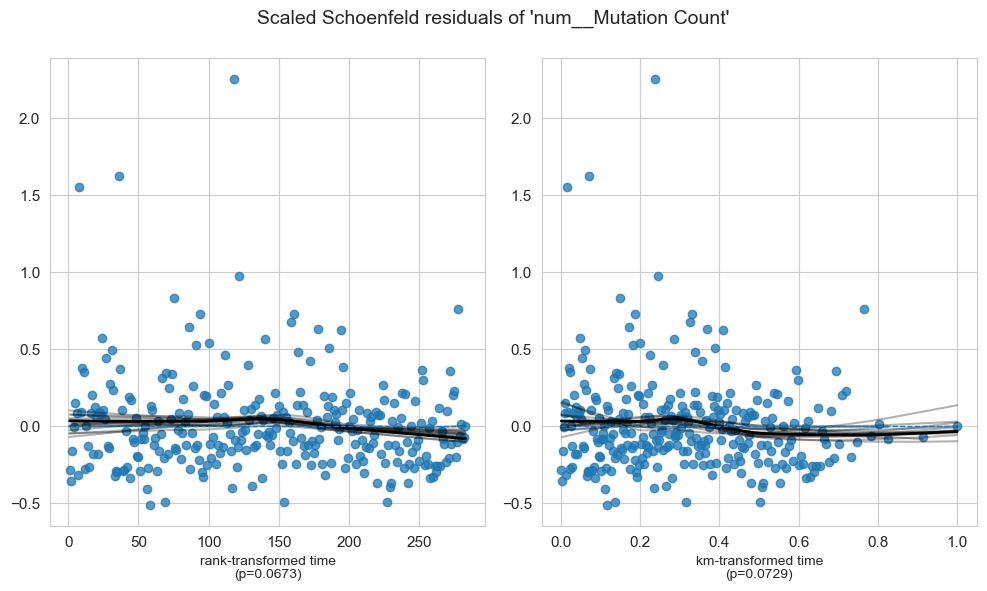

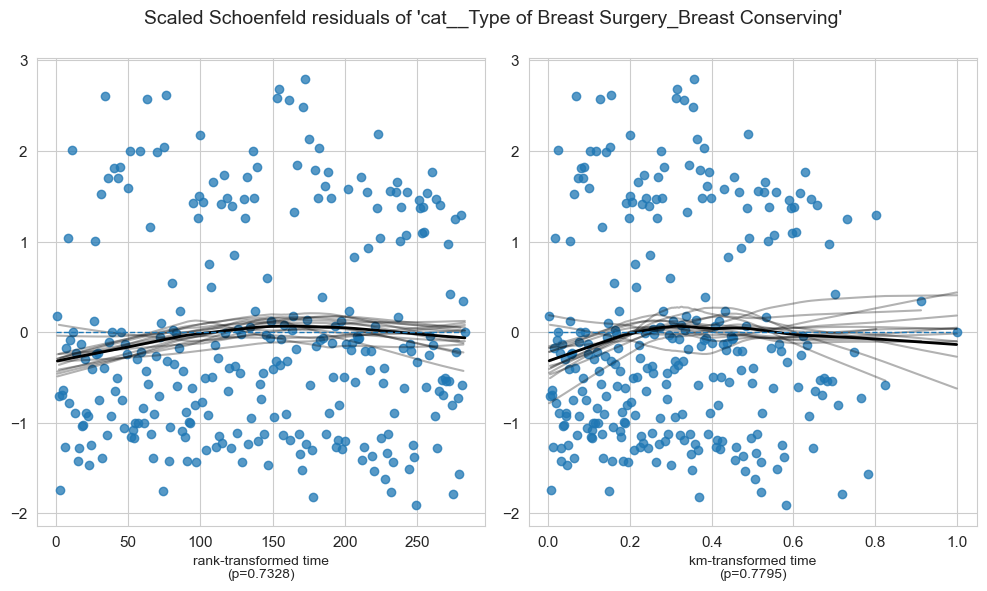

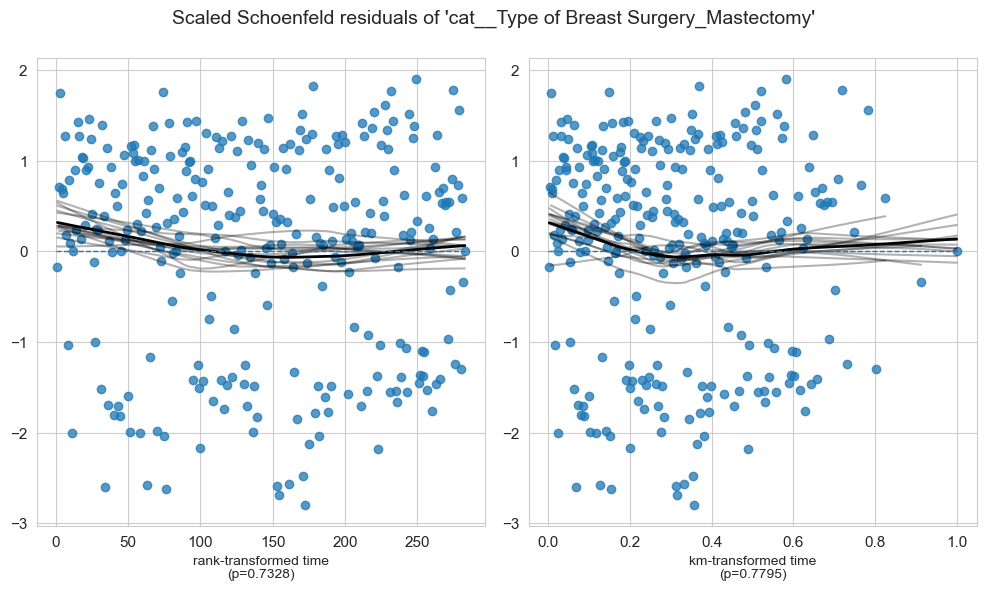

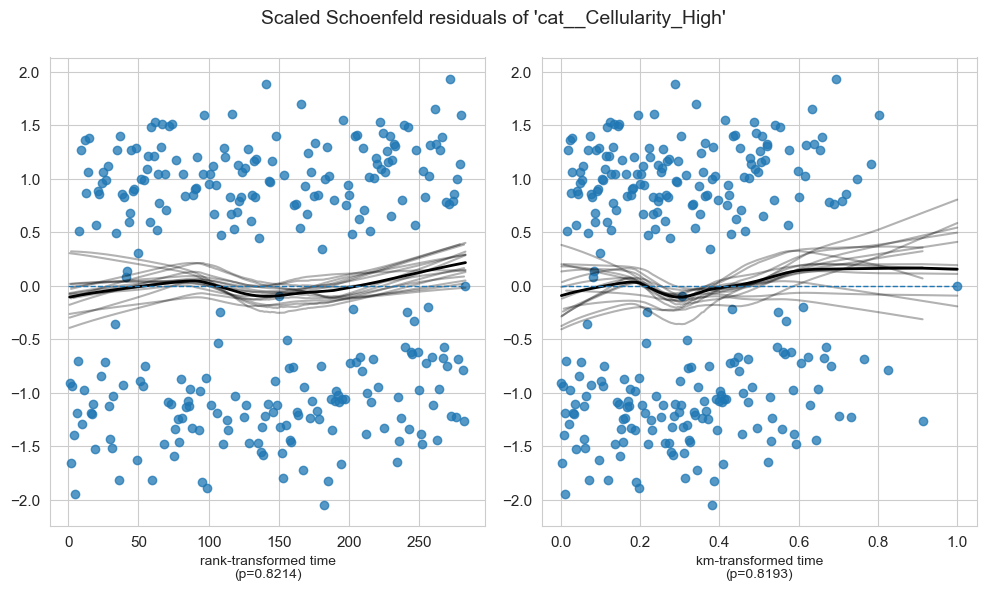

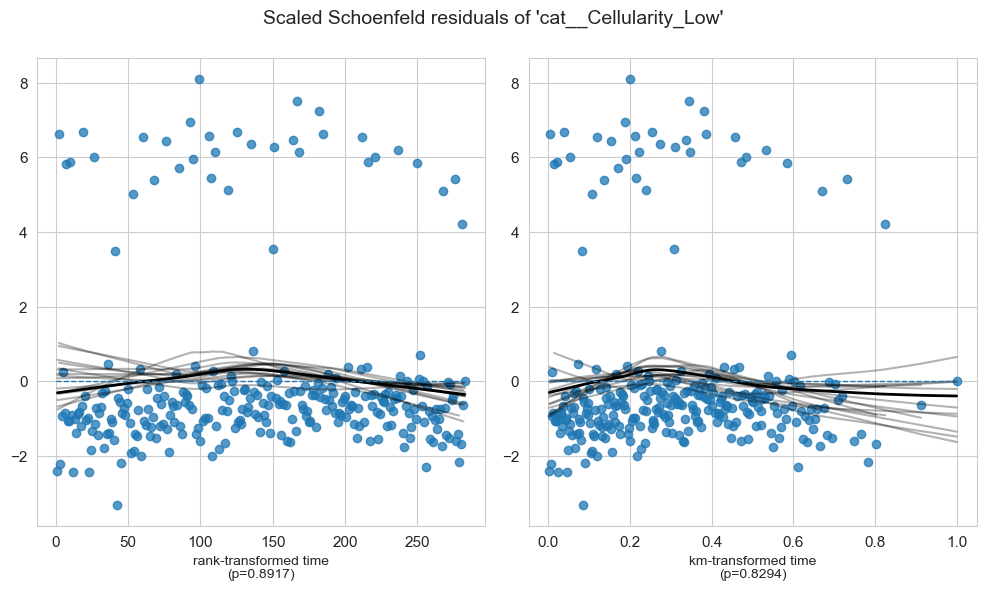

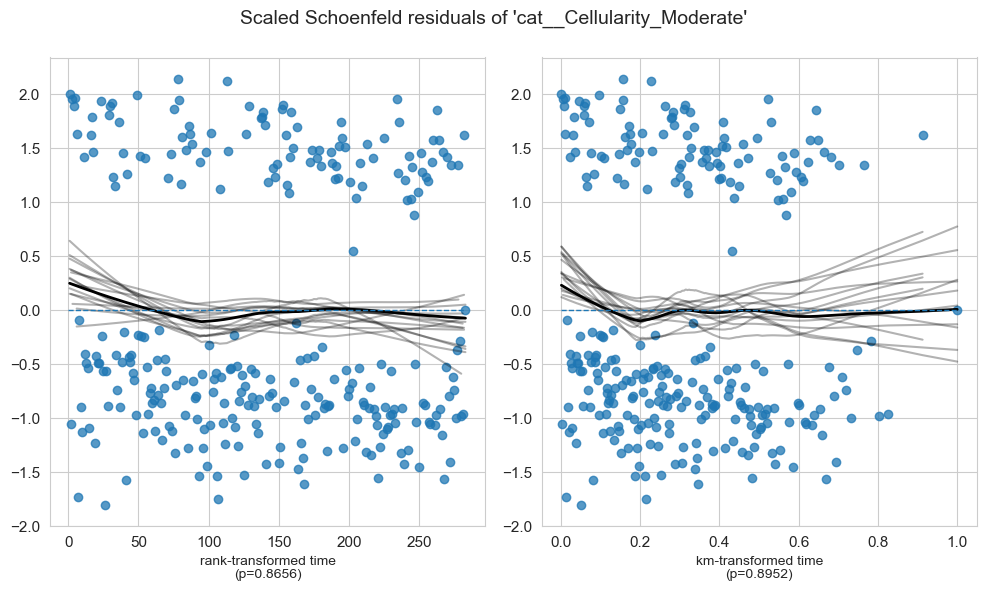

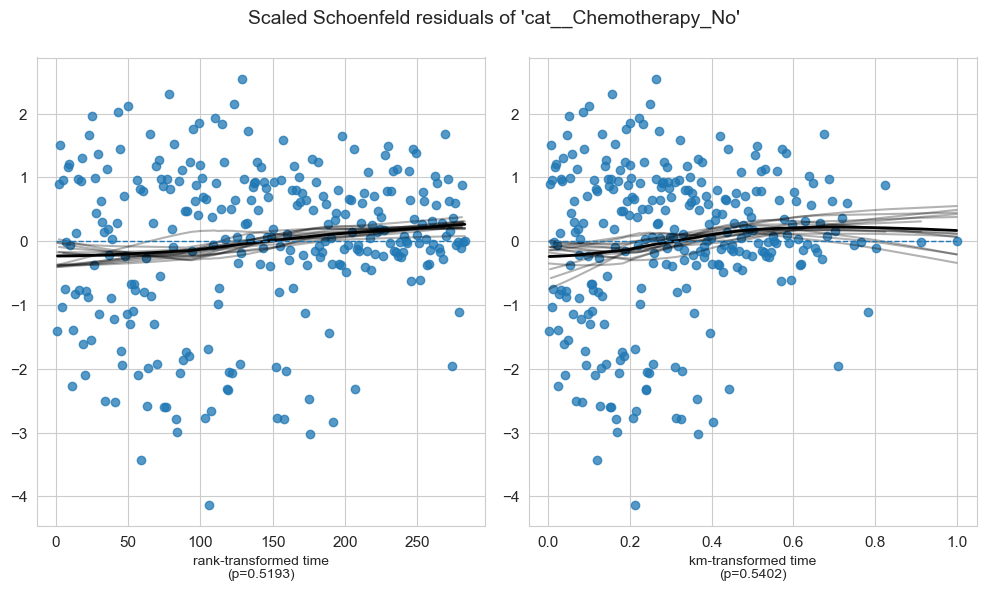

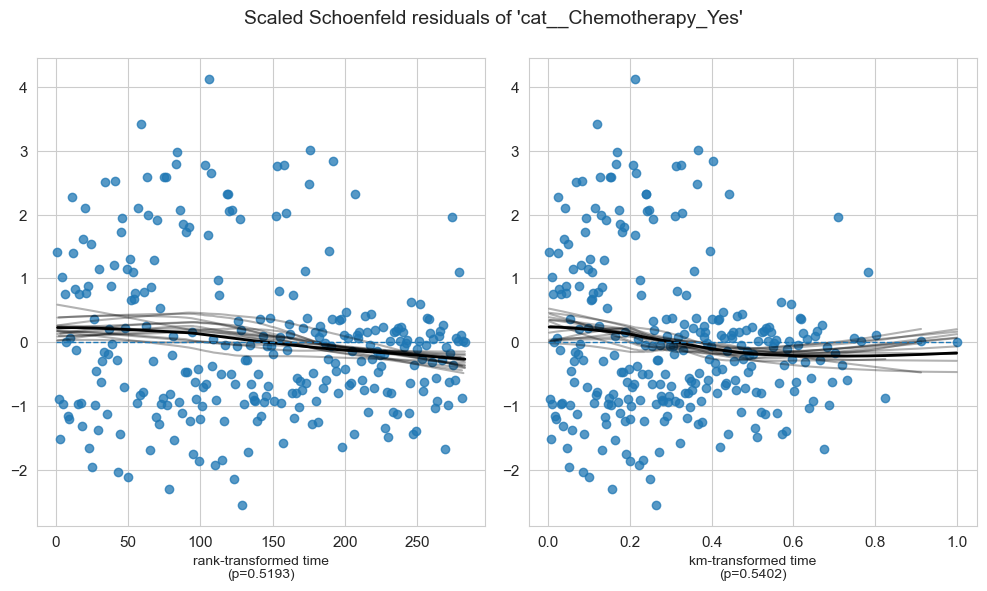

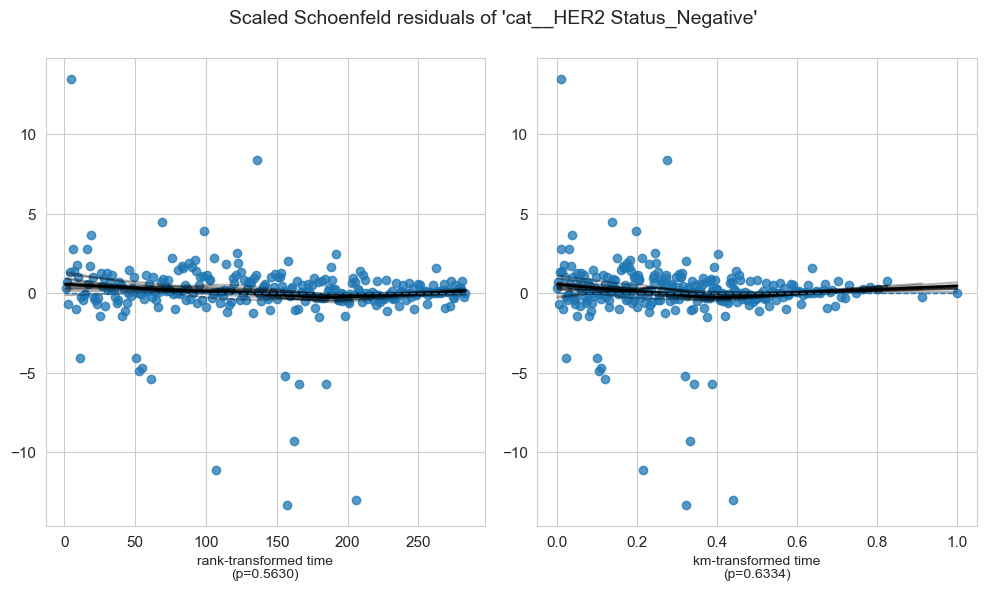

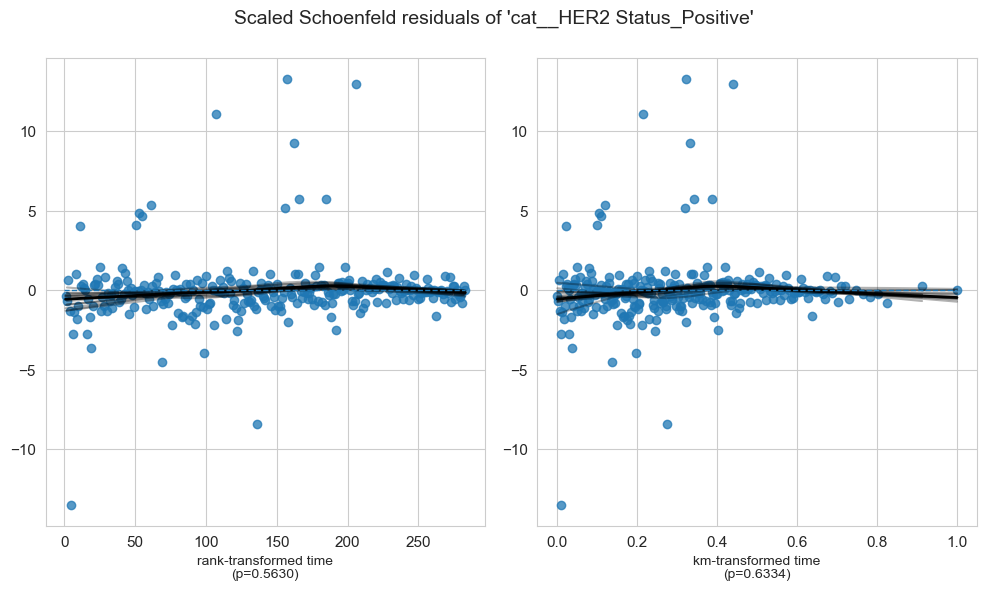

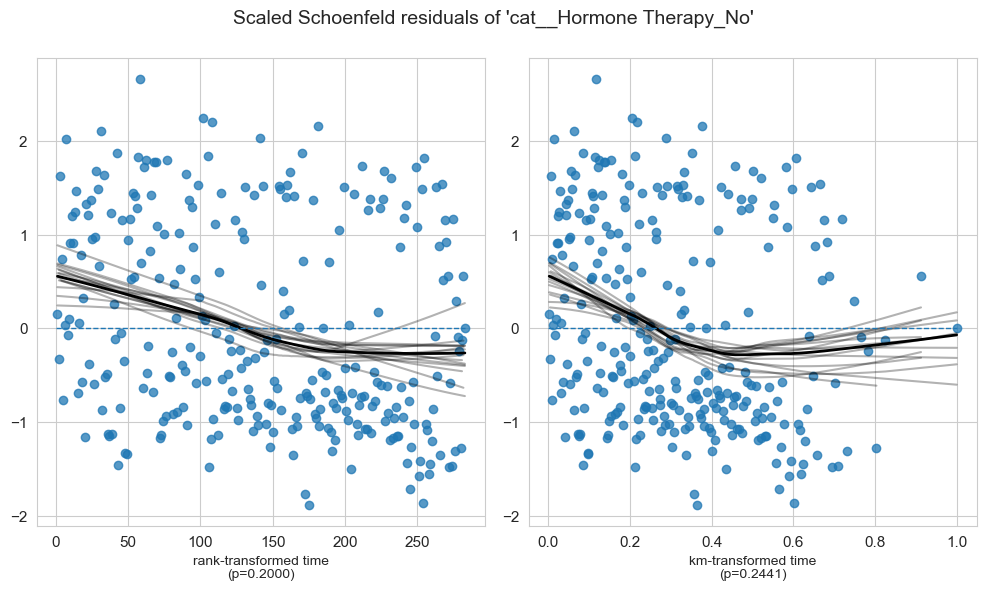

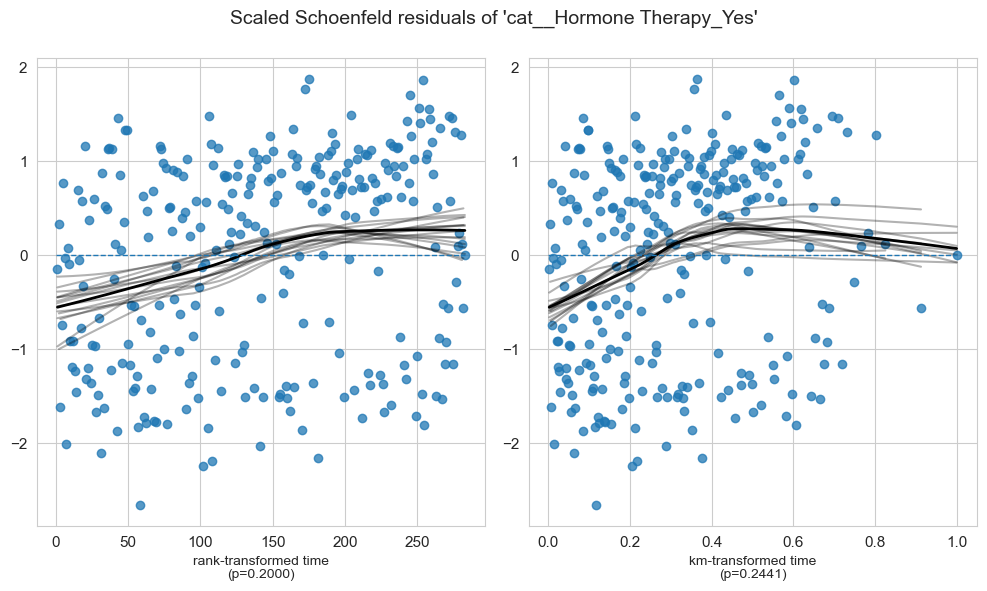

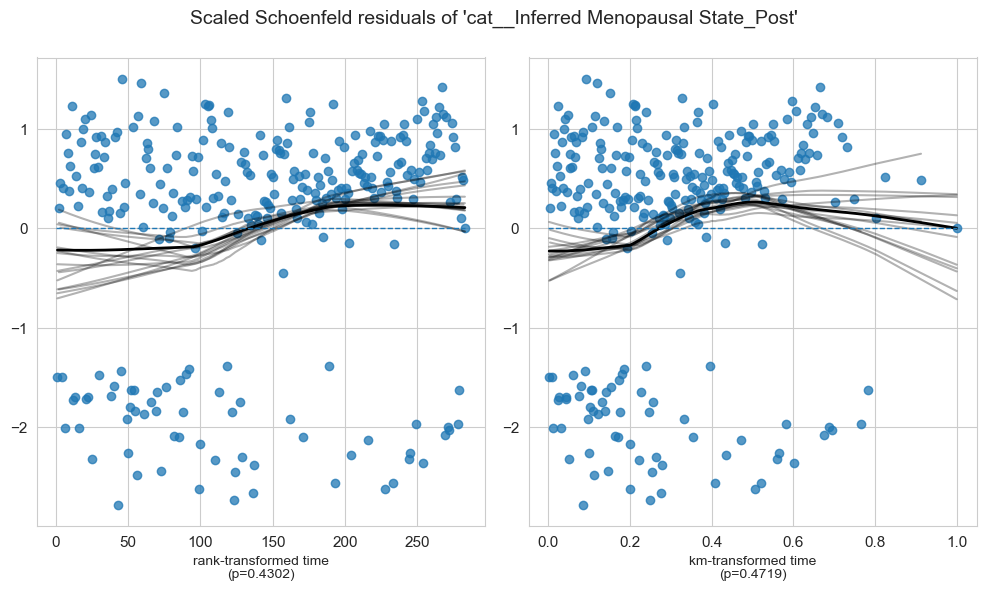

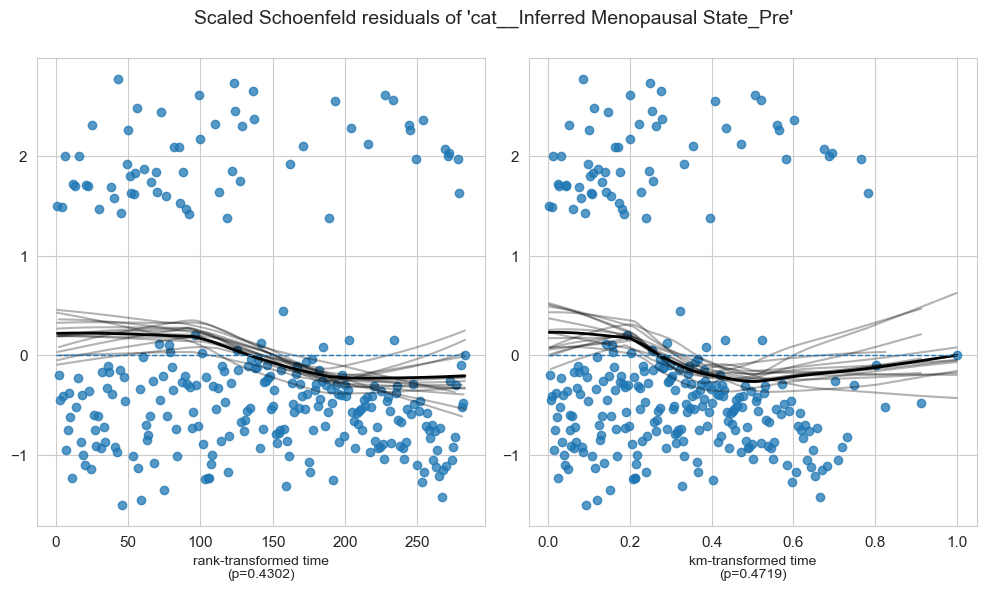

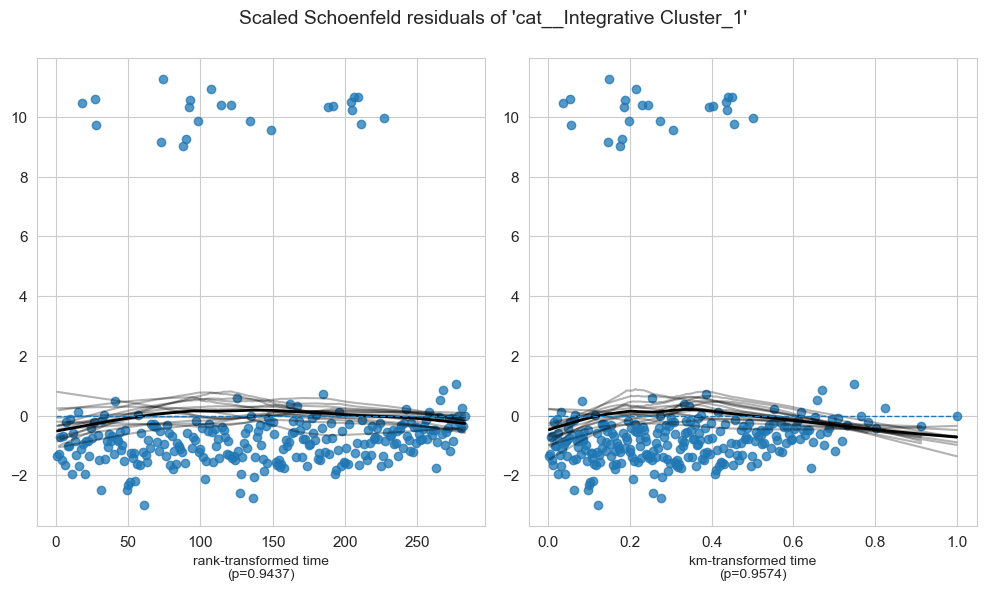

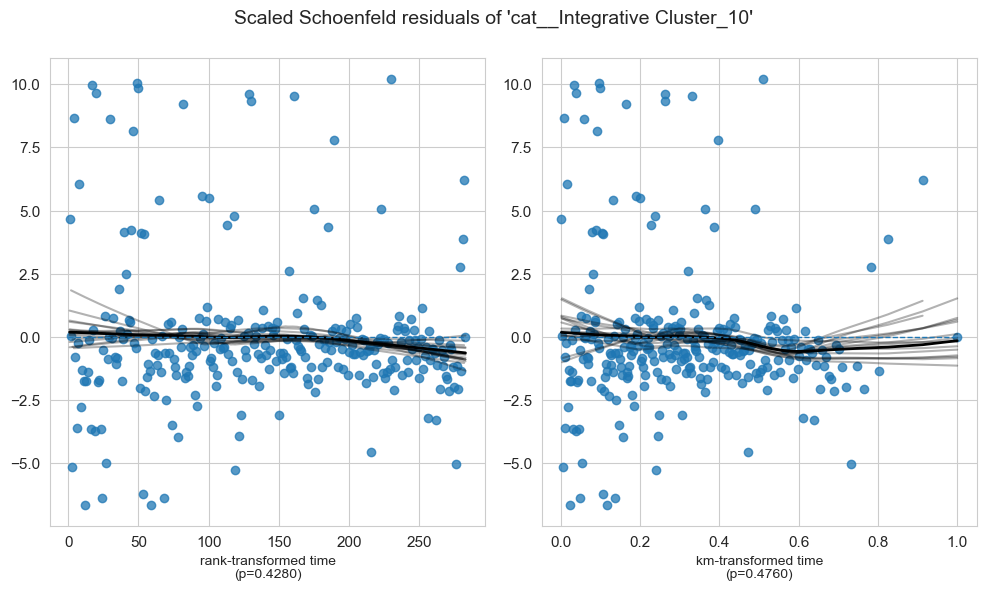

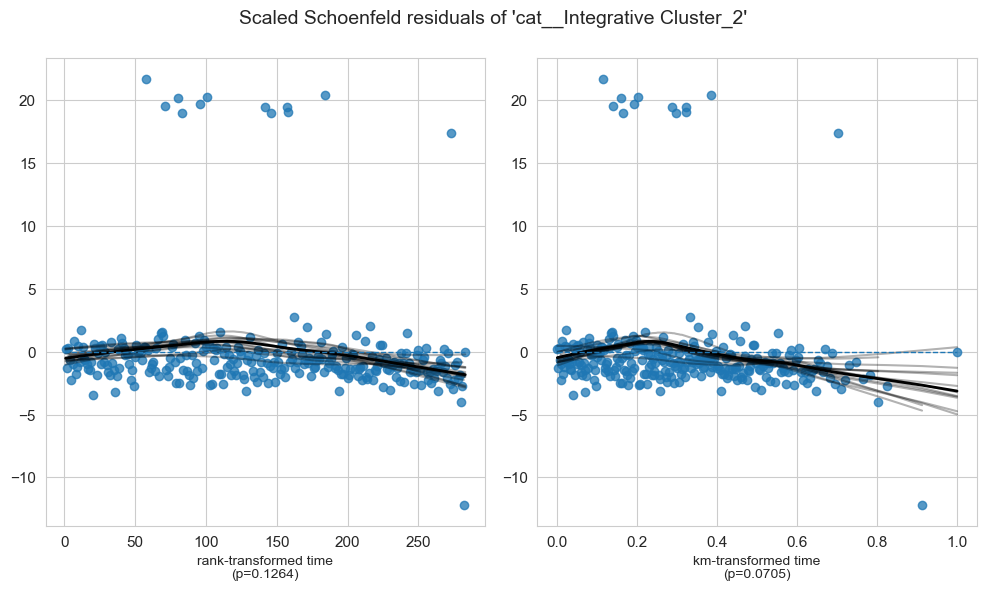

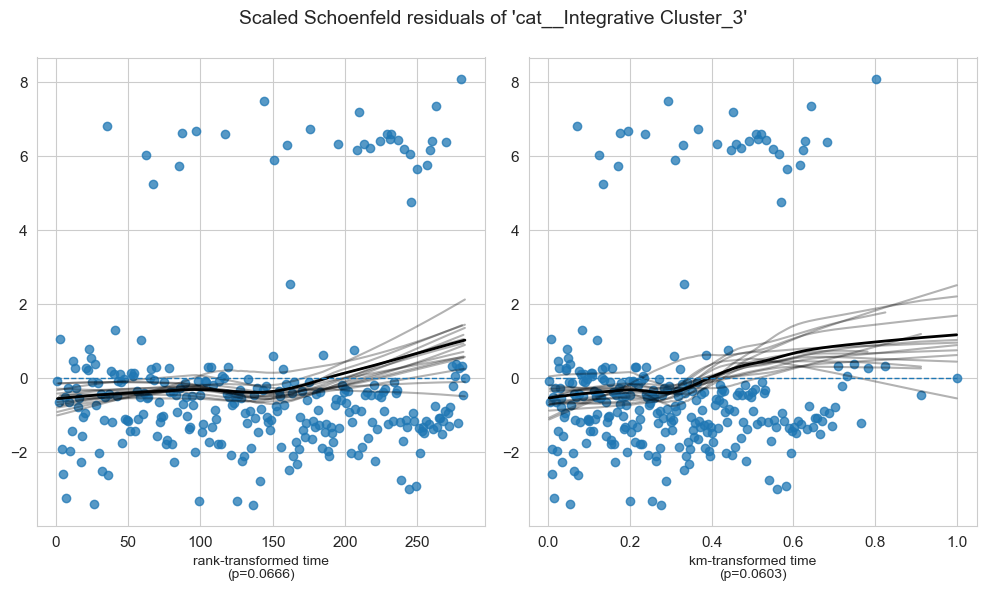

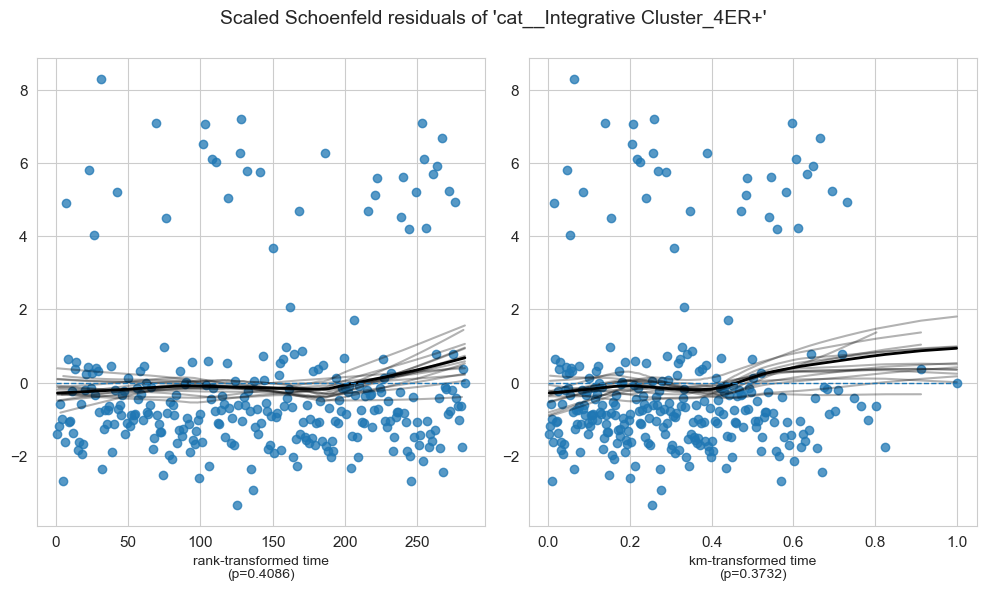

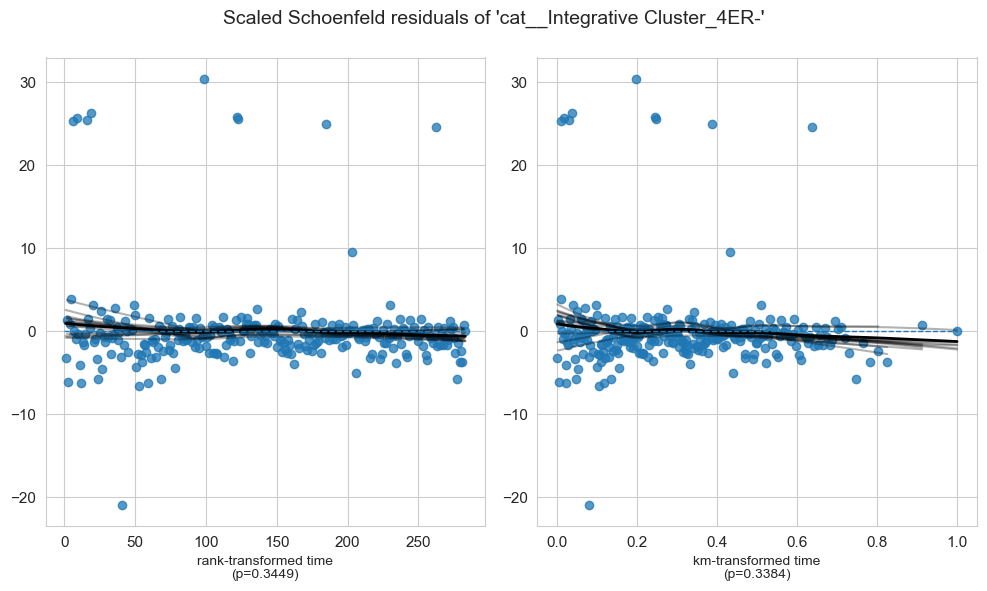

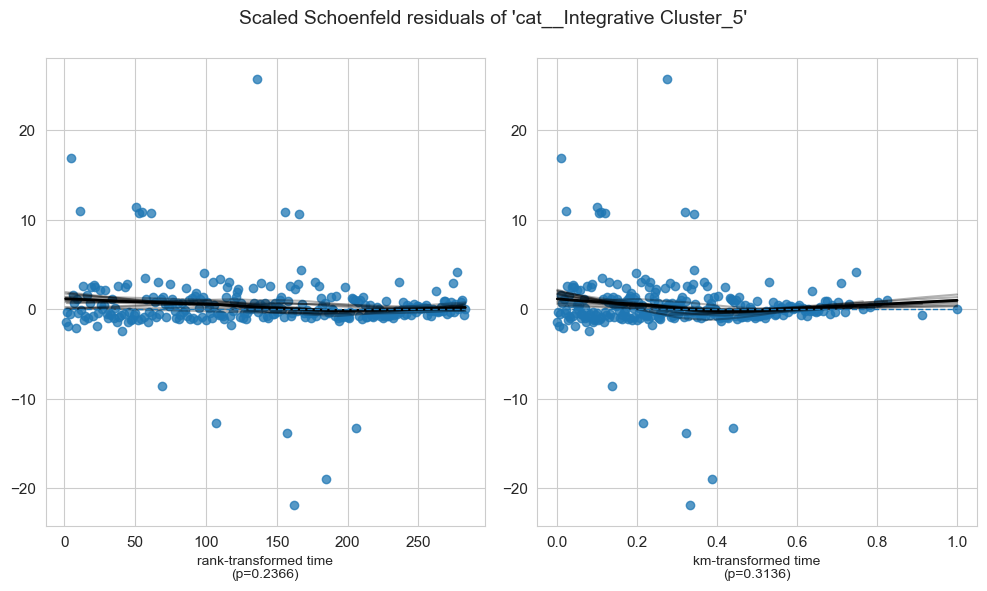

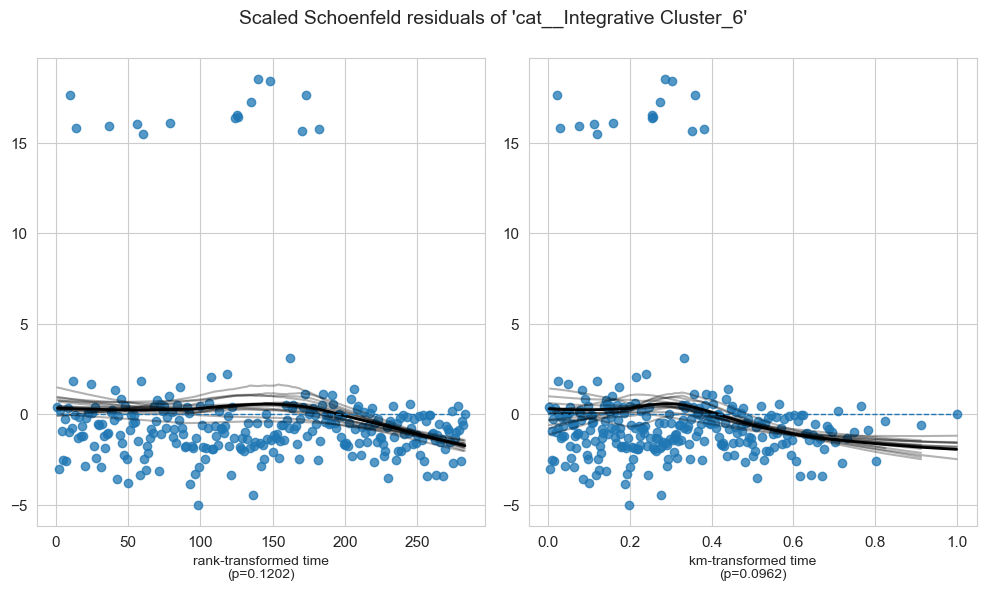

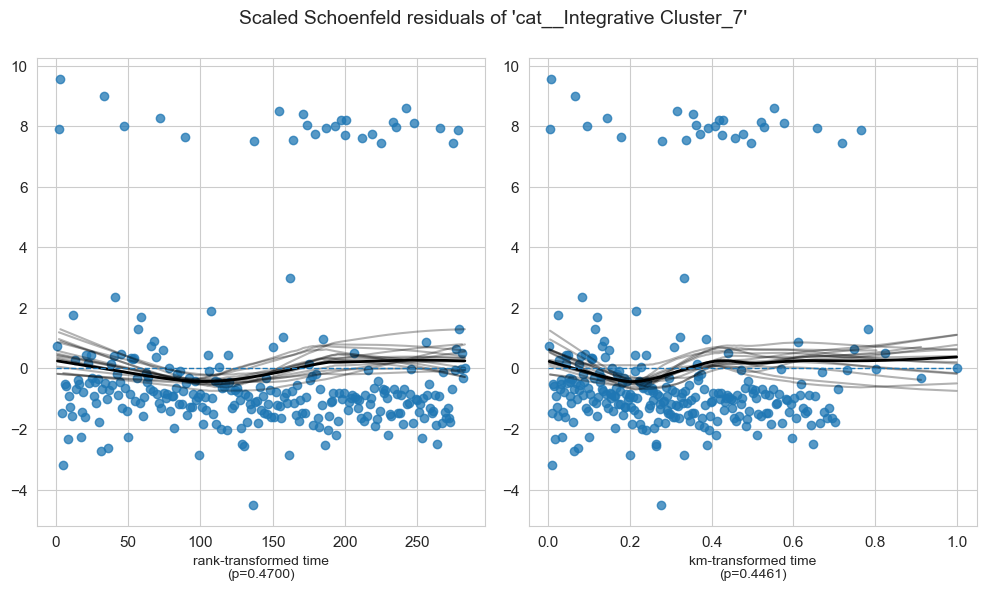

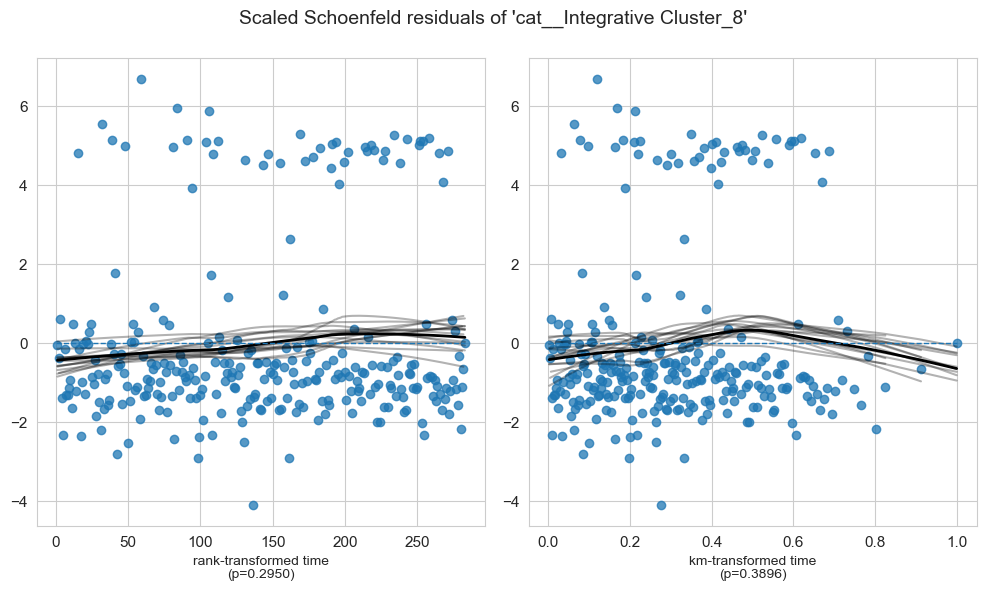

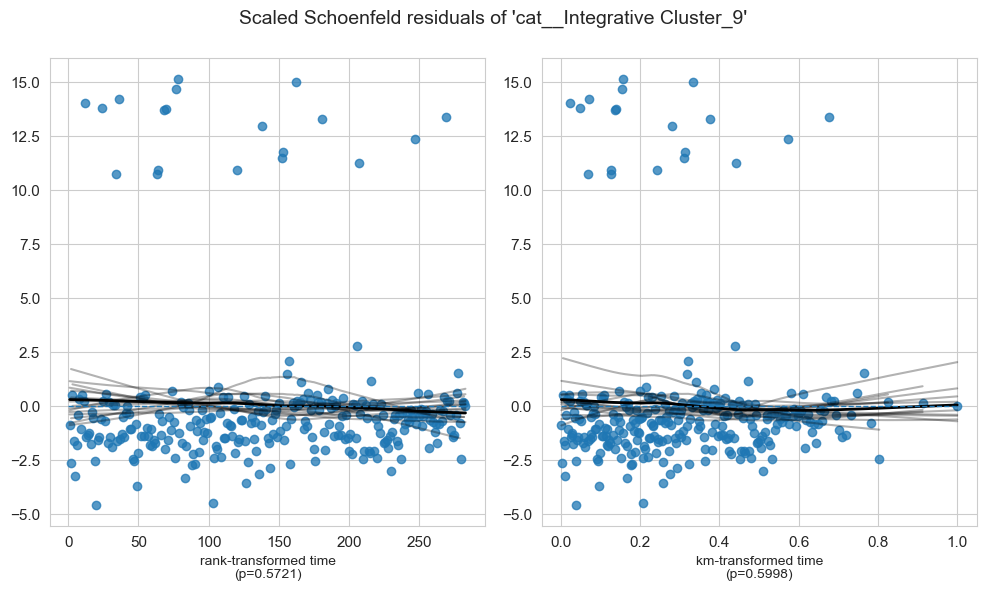

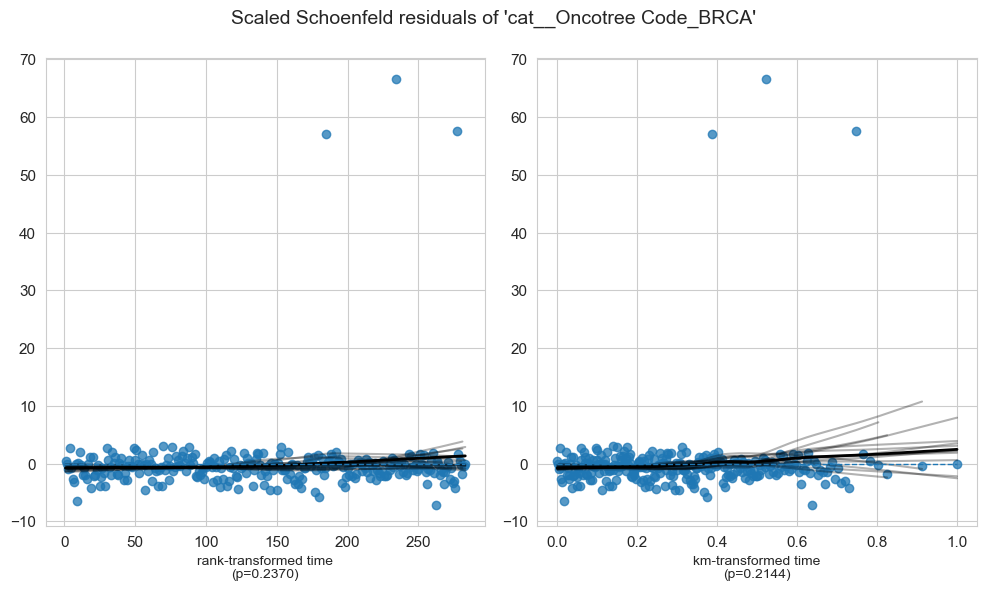

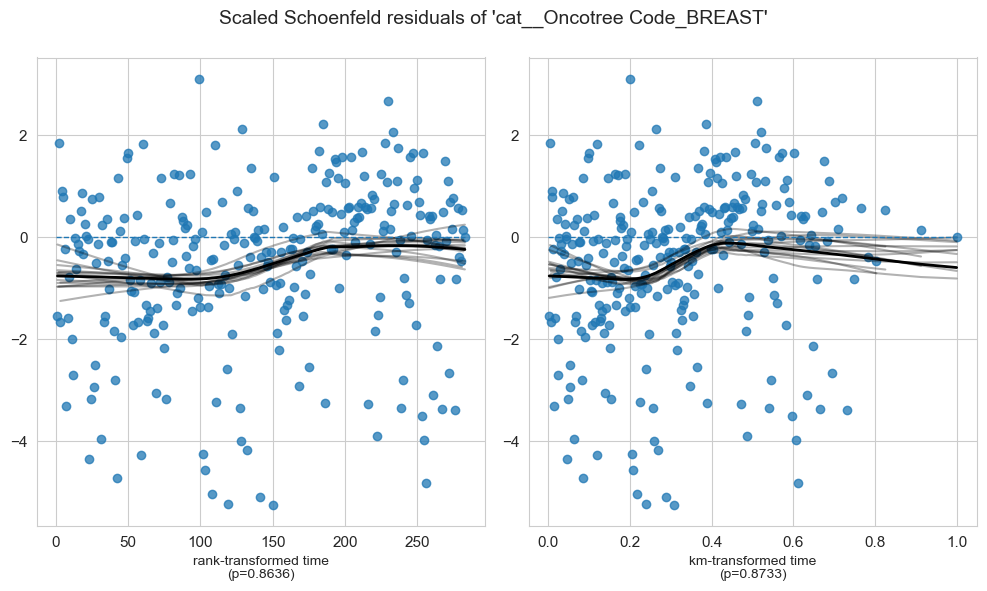

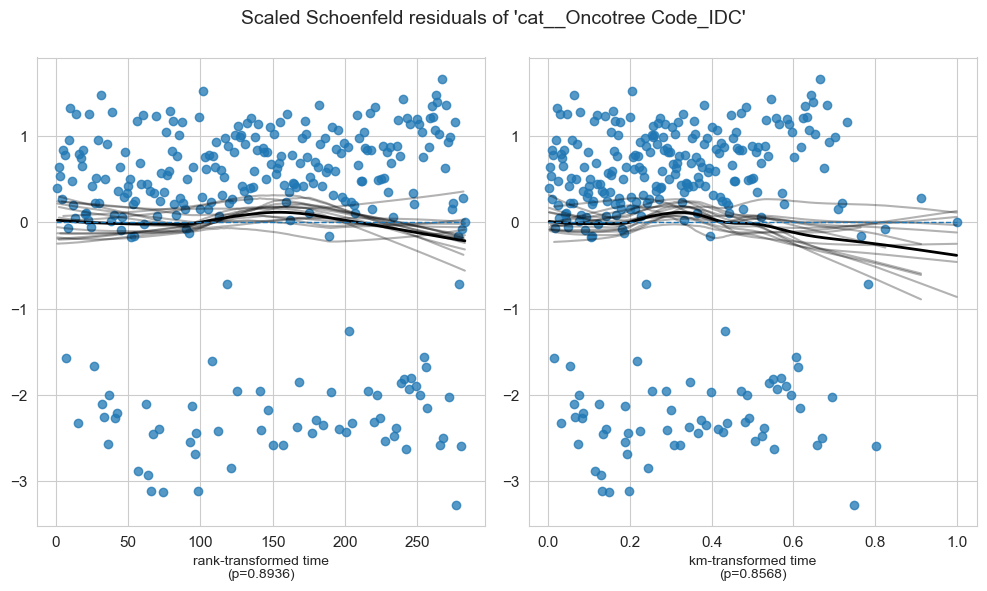

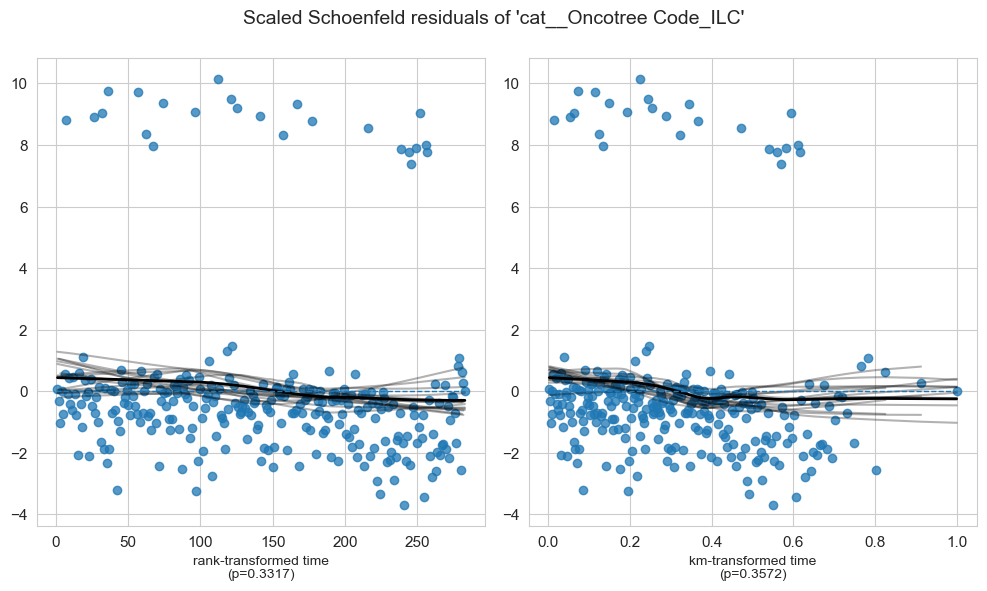

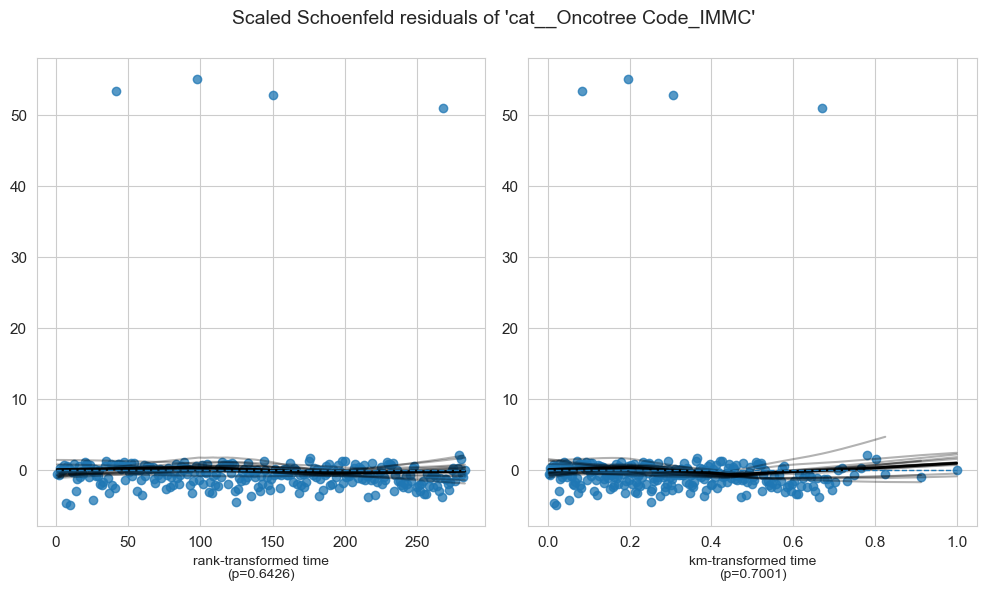

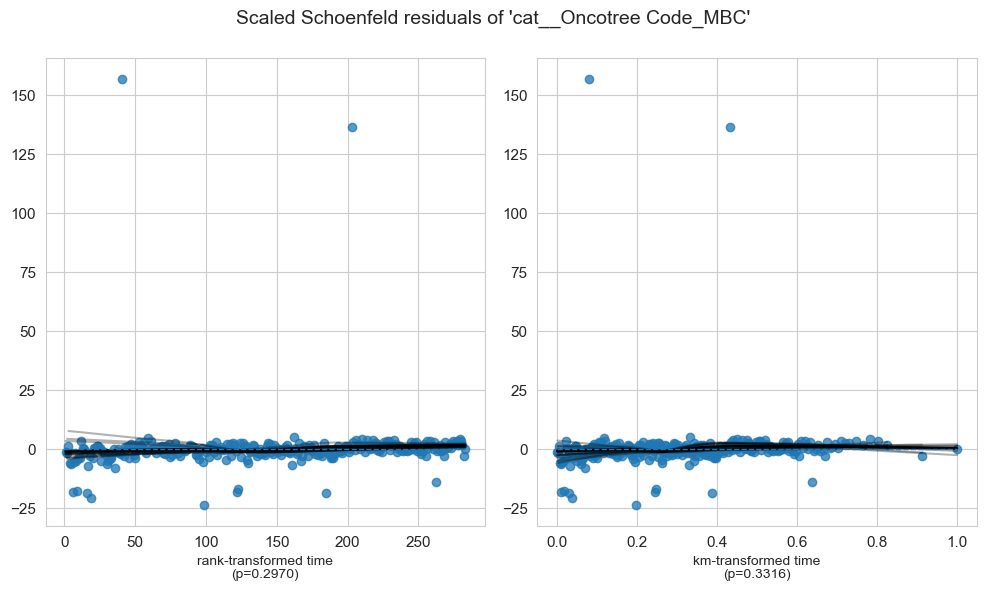

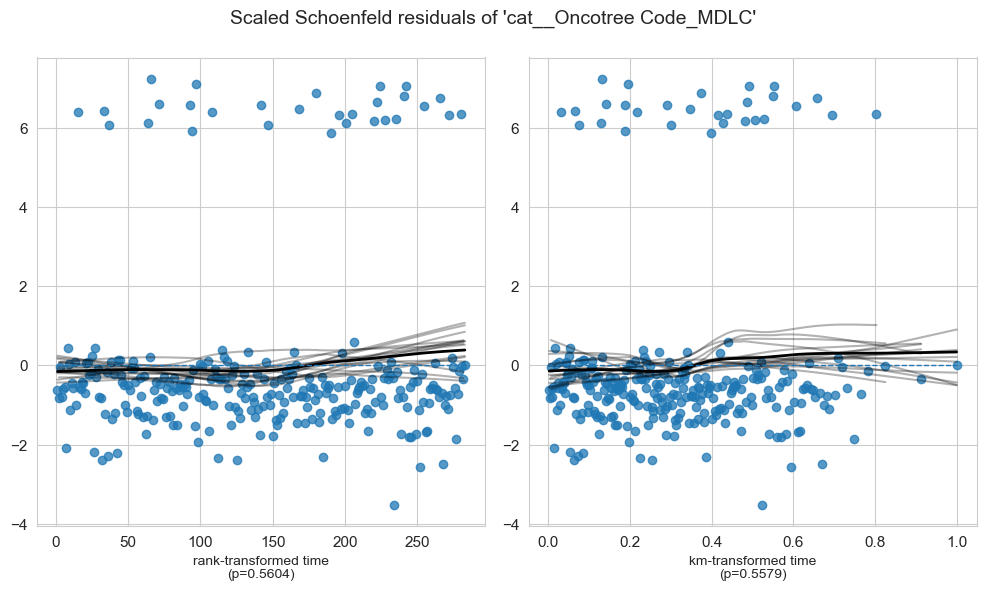

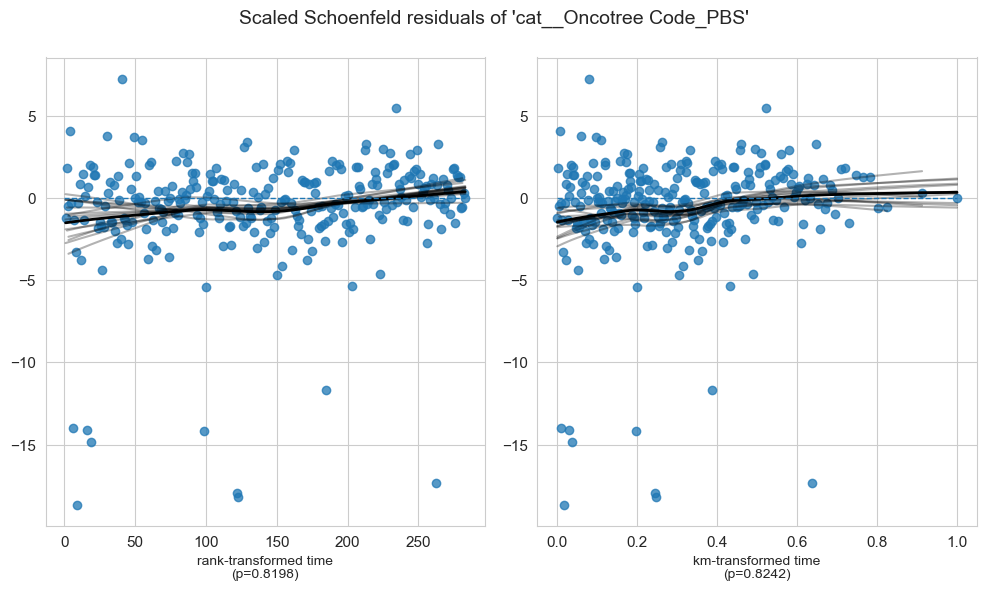

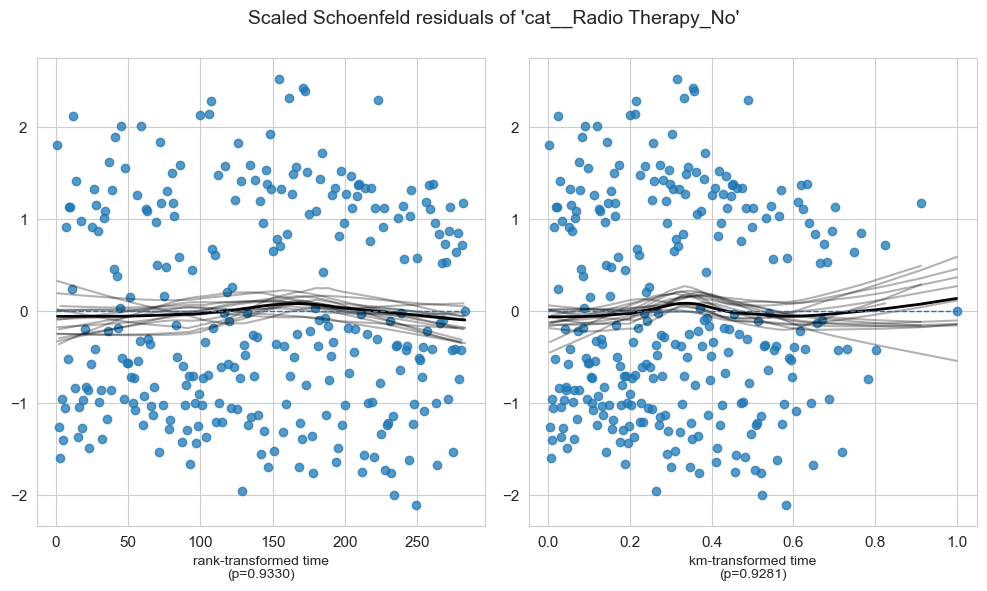

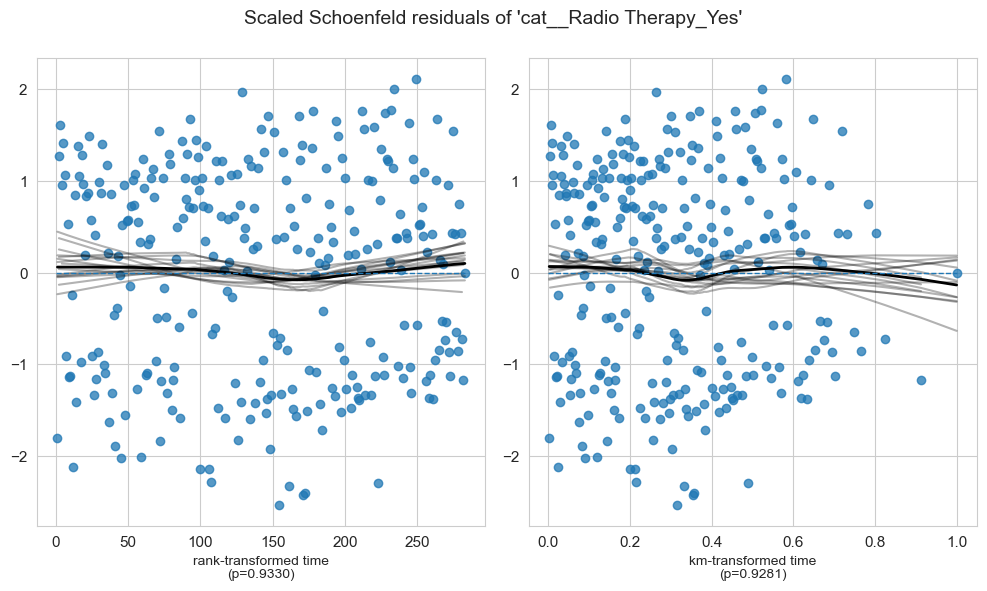

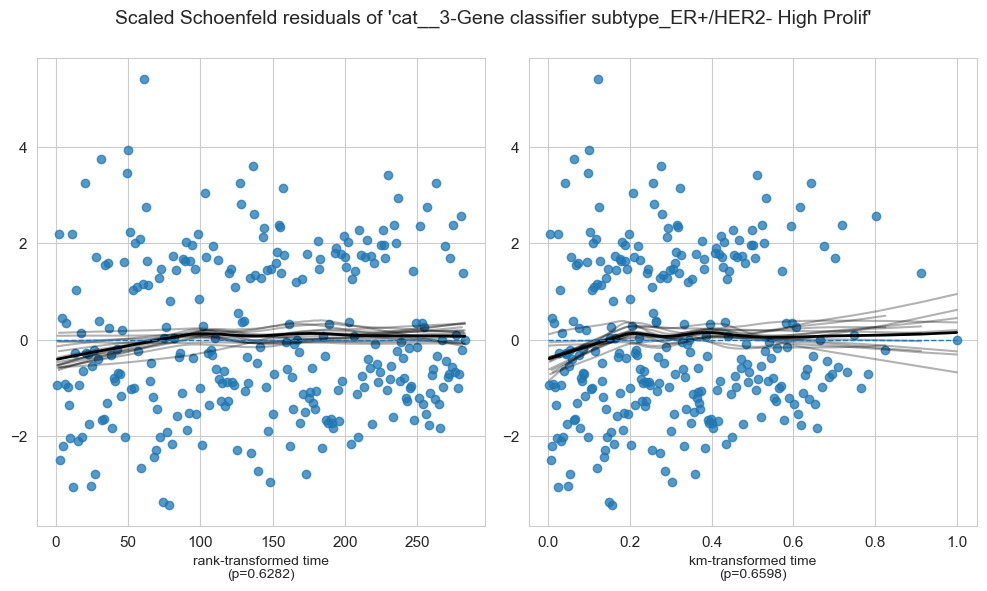

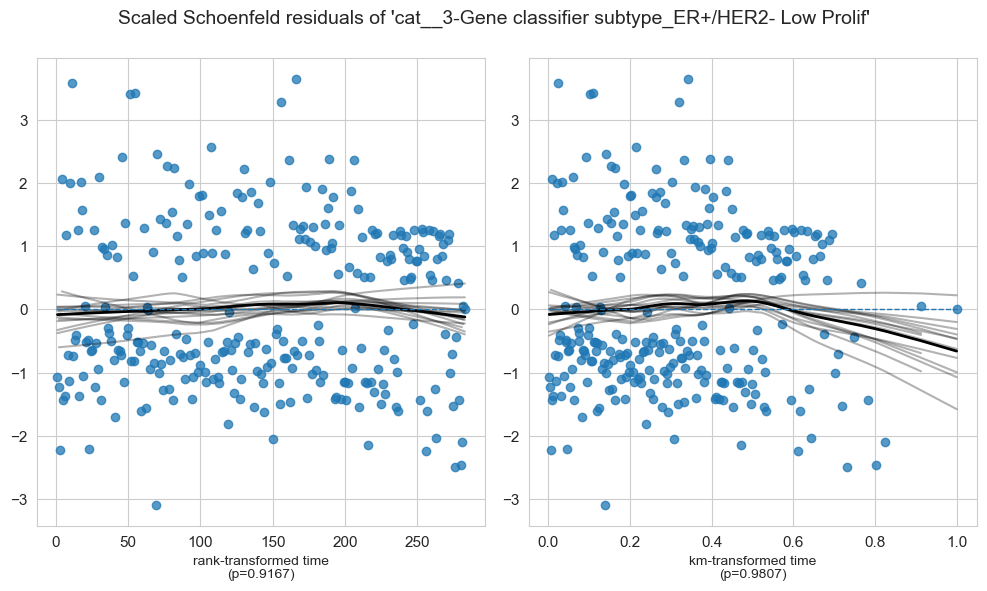

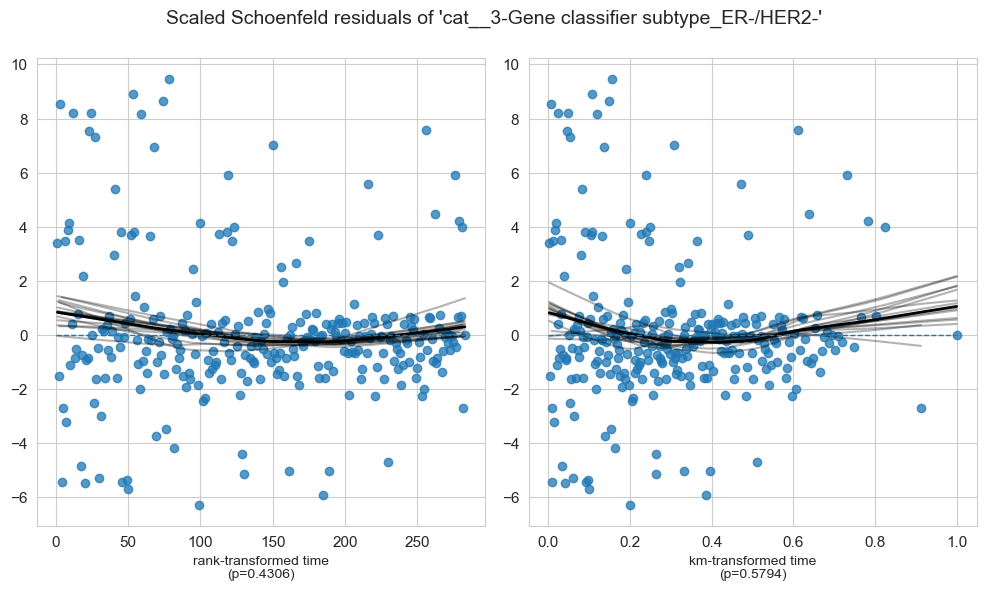

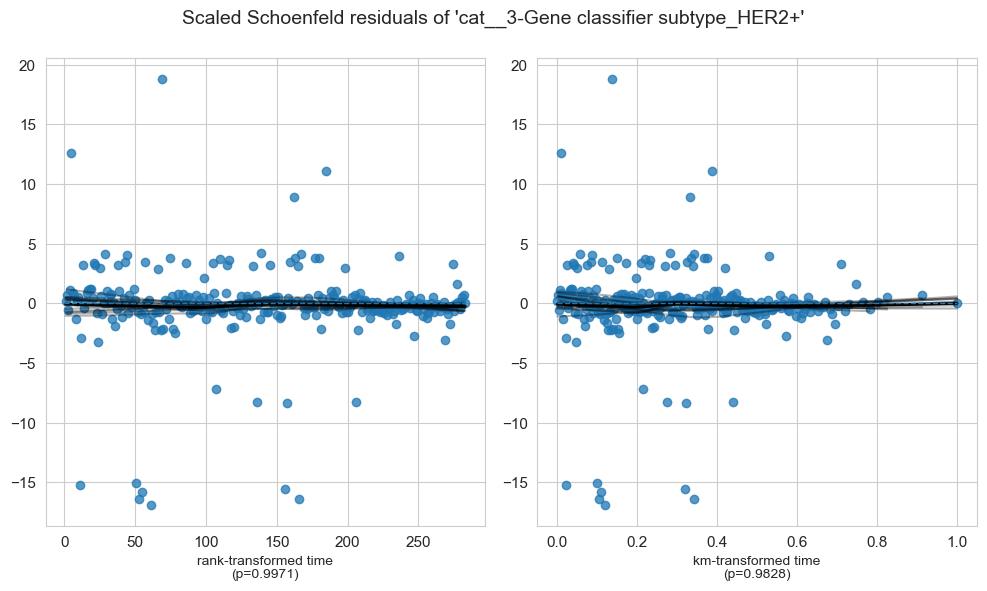

In [61]:
outcome_cols = [cph_model.duration_col, cph_model.event_col]
all_cols_to_exclude = strat_cols + outcome_cols

# DF will be used to fit a TEMPORARY, non-stratified CPH model
covariates_only_df = train_cox_df.drop(columns=strat_cols, errors='ignore')


# TEMPORARY CPH Model (w/out stratification)
# Used solely for the check_assumptions function. Only includes variables that have coefs in final model.
cph_model_for_ph_check = CoxPHFitter(penalizer=0.1)

# Fit the temporary model. No strata argument here!
cph_model_for_ph_check.fit(
    covariates_only_df, 
    duration_col=cph_model.duration_col, 
    event_col=cph_model.event_col
)

print("Running PH check on the independent covariates...")
print("Checking PH assumption for: ", cph_model_for_ph_check.params_.index.tolist())


# The function will automatically flag any variables that fail the test (p < 0.05)
cph_model_for_ph_check.check_assumptions(
    training_df=covariates_only_df,
    p_value_threshold=0.05,
    show_plots=True
) 

suspect_keywords = [
    'Grade', 'ER Status', 'PR Status', 'Tumor Stage', 'Lymph nodes'
]

# 2) Convenience: print the covariate names that might be most at risk of non-PH
suspect_terms = [c for c in train_cox_df.columns
                if any(keyword in col for keyword in suspect_keywords)]
print("\nCovariates to scrutinize first:", suspect_terms)



## 7.3 Forest Plot for Visualization of Models Results

--- Forest Plot of Multivariable Cox Model ---


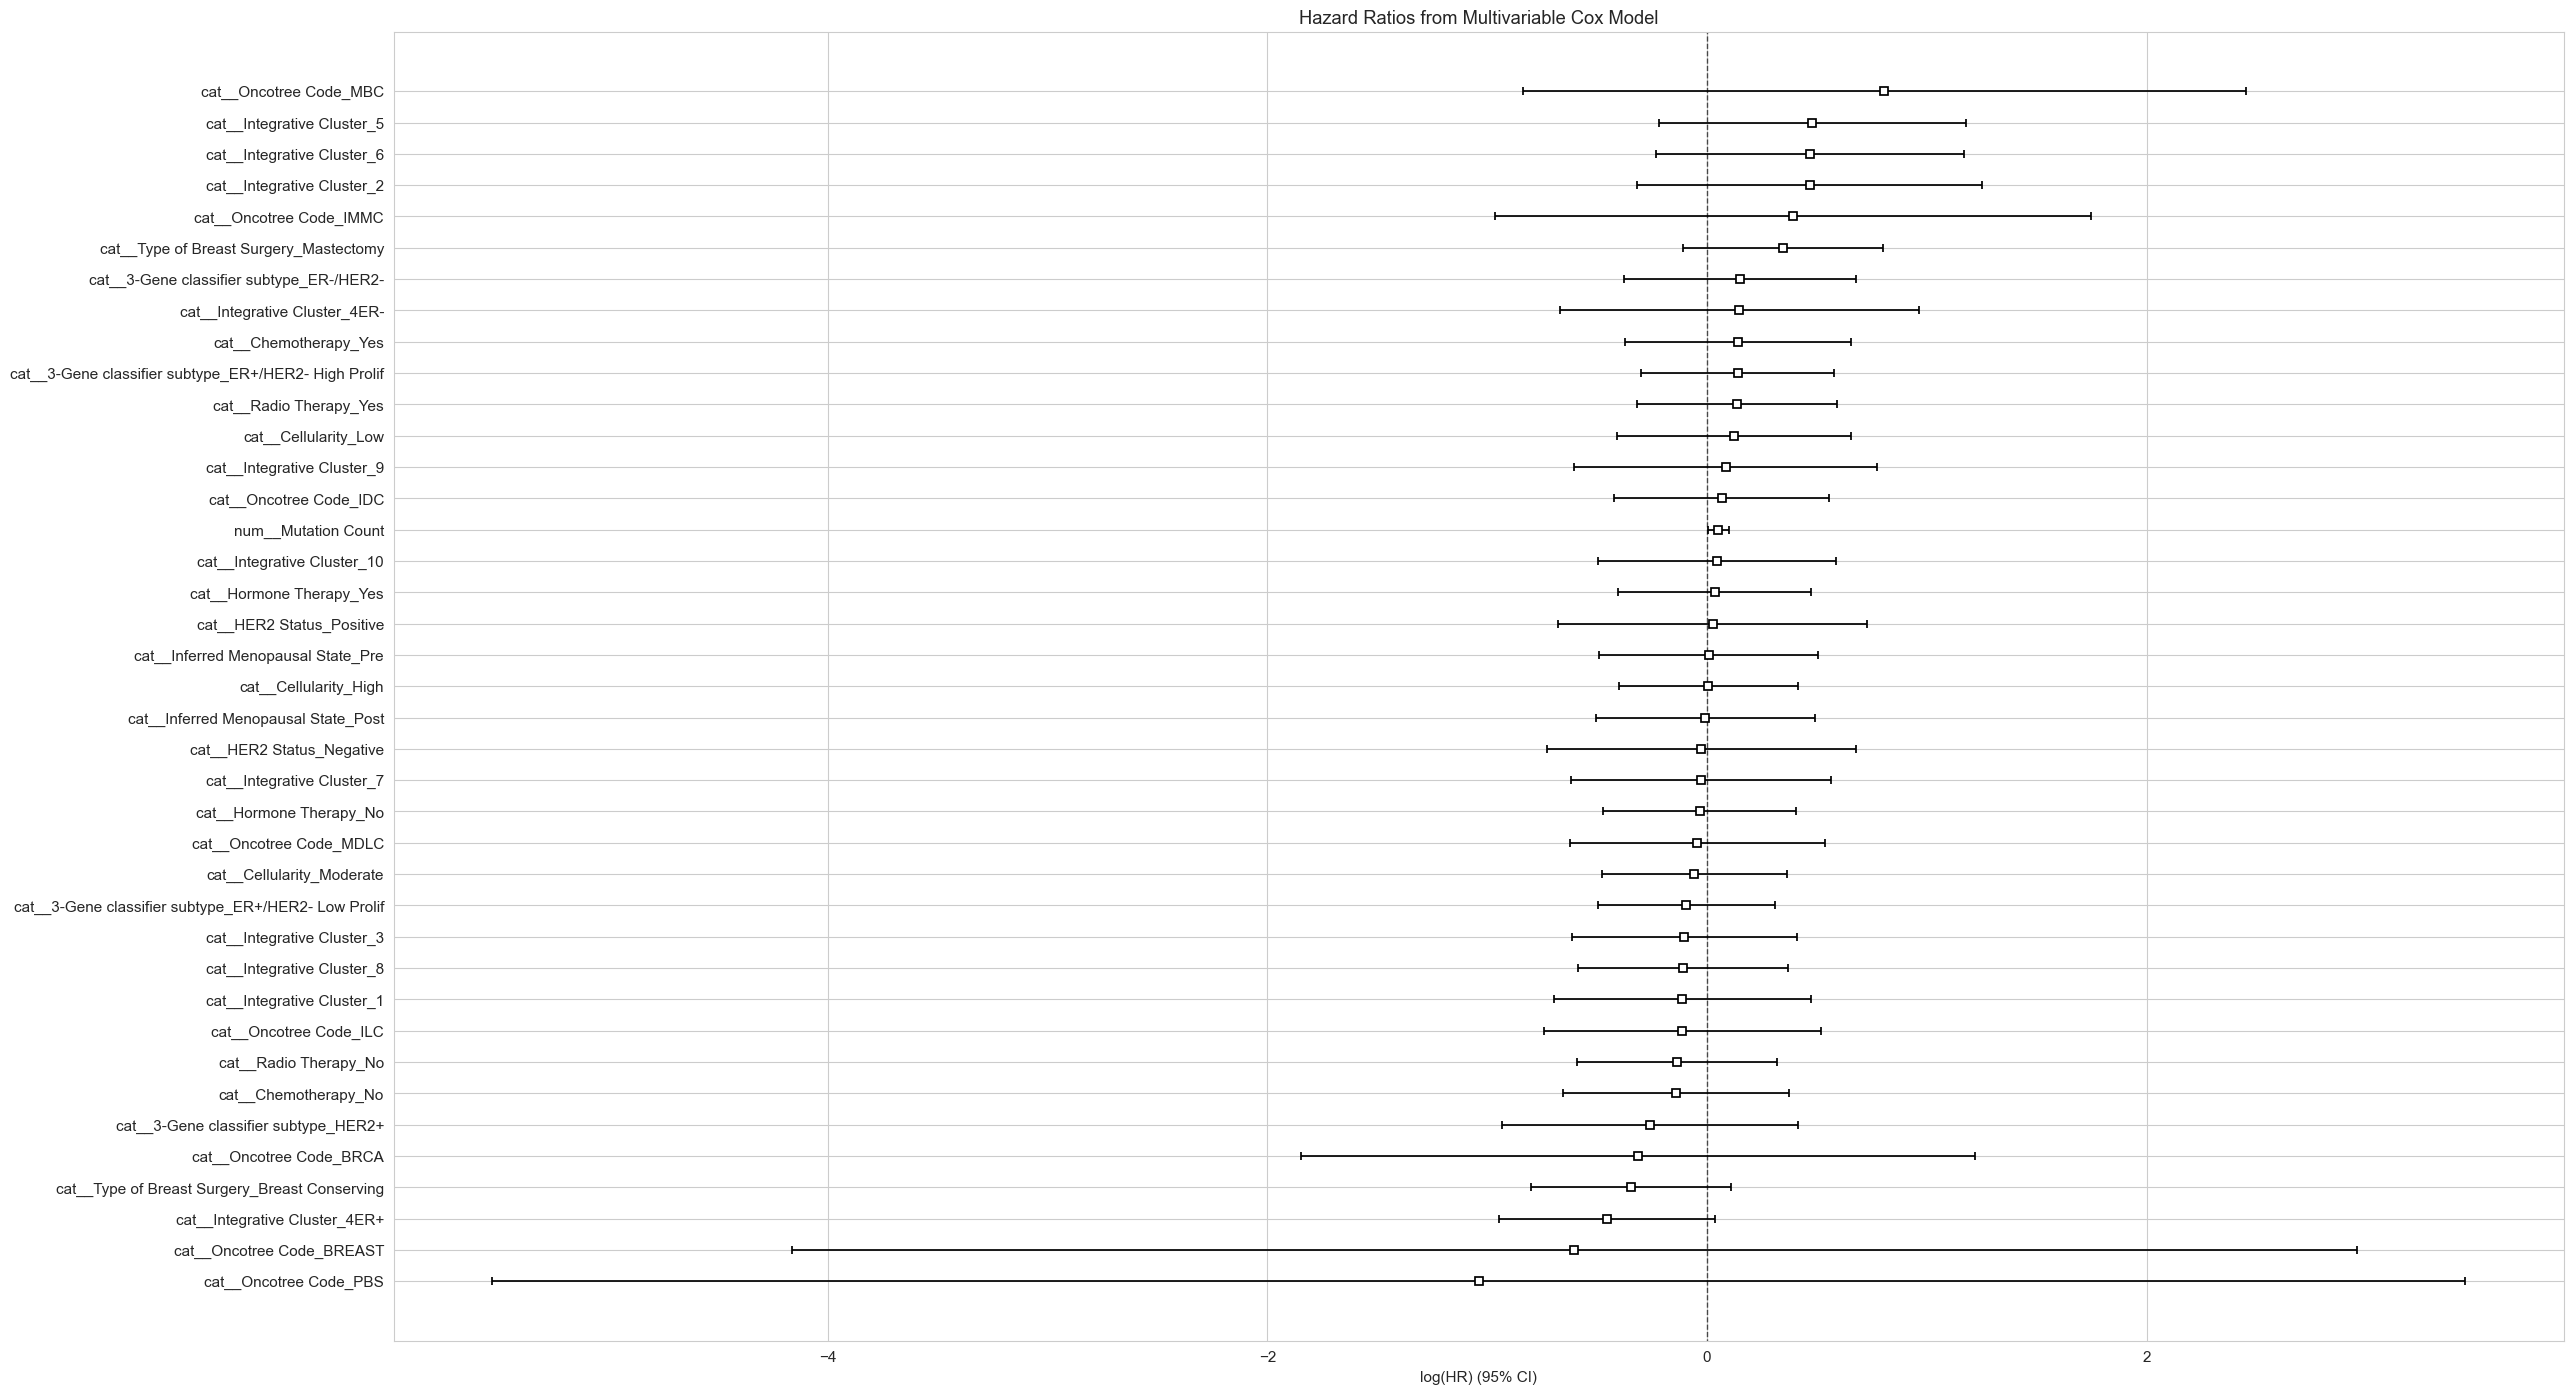

In [62]:
# The lifelines library has a convenient built-in function to create a forest plot.
# This is much simpler than building it manually.
summary_df = cph_model.summary
sorted_summary = summary_df.sort_values(by="exp(coef)", ascending=False)

print("--- Forest Plot of Multivariable Cox Model ---")
fig, ax = plt.subplots(figsize=(28, 17))

cph_model.plot(ax=ax)

ax.set_title("Hazard Ratios from Multivariable Cox Model")
plt.show()

## 7.4 Individual Predictions and Risk Seperation

Using our model to assign a risk score (hazard) to each patient and see how well it separates them into different risk groups (cohorts)

In [64]:
# Data preparation steps 1-3 remain the same
# 1) Transform features
# X_test_cox = utils.to_dataframe(cox_preprocessor, X_test)
# X_train_cox = utils.to_dataframe(cox_preprocessor, X_train)

# 2) Compute risk scores and define quartiles on the training set
risk_train = cph_model.predict_partial_hazard(X_train_cox).values
risk_test = cph_model.predict_partial_hazard(X_test_cox).values

q1, q2, q3 = np.quantile(risk_train, [0.25, 0.50, 0.75])
bins = np.unique([-np.inf, q1, q2, q3, np.inf])
if len(bins) - 1 < 4:
    # If fewer than 4 intervals, reduce the number of labels.
    labels = [f"Group {i+1}" for i in range(len(bins)-1)]
    print(f"Warning: Risk scores are not diverse enough for 4 quartiles. Using {len(labels)} groups instead.")
else:
    labels = ["Q1 (Lowest Risk)", "Q2", "Q3", "Q4 (Highest Risk)"]
test_groups = pd.cut(risk_test, bins=bins, labels=labels, include_lowest=True)

# 3) Prepare evaluation DataFrame for the test set
test_eval_df = pd.concat(
    [y_test[["duration_os", "event_os"]].copy().reset_index(drop=True),
     pd.Series(test_groups, name="risk_quartile")],
    axis=1
).rename(columns={"duration_os": "duration", "event_os": "event"})

# 4) Plot with a larger figure size
fig, ax, logrank = utils.km_by_group(
    df=test_eval_df,
    group_col="risk_quartile",
    time_col="duration",
    event_col="event",
    xmax=350,
    show_table=True,
    figsize=(10, 6)
)

ax.set_title("Test Set Survival by Cox Risk Quartile", fontsize=11)
ax.set_xlabel(ax.get_xlabel(), fontsize=10)
ax.set_ylabel(ax.get_ylabel(), fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=9)

for item in ax.texts:
    item.set_fontsize(9)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10
)

fig.subplots_adjust(right=0.75, bottom=0.2)
plt.show()

ValueError: bins must increase monotonically.

### 7.4.1 Personalized Survival Predictions

Visualizing the full survival curve for specific individuals. This transforms the model's abstract risk score into a tangible, time-dependent forecast for a given patient

**We will select two patients from the test set:**
* One with the lowest predicted risk
* One with the highest

Feature values for the selected low-risk and high-risk patients:


,num__Mutation Count,cat__Type of Breast Surgery_Breast Conserving,cat__Type of Breast Surgery_Mastectomy,cat__Cellularity_High,cat__Cellularity_Low,cat__Cellularity_Moderate,cat__Chemotherapy_No,cat__Chemotherapy_Yes,cat__HER2 Status_Negative,cat__HER2 Status_Positive,cat__Hormone Therapy_No,cat__Hormone Therapy_Yes,cat__Inferred Menopausal State_Post,cat__Inferred Menopausal State_Pre,cat__Integrative Cluster_1,cat__Integrative Cluster_10,cat__Integrative Cluster_2,cat__Integrative Cluster_3,cat__Integrative Cluster_4ER+,cat__Integrative Cluster_4ER-,cat__Integrative Cluster_5,cat__Integrative Cluster_6,cat__Integrative Cluster_7,cat__Integrative Cluster_8,cat__Integrative Cluster_9,cat__Oncotree Code_BRCA,cat__Oncotree Code_BREAST,cat__Oncotree Code_IDC,cat__Oncotree Code_ILC,cat__Oncotree Code_IMMC,cat__Oncotree Code_MBC,cat__Oncotree Code_MDLC,cat__Oncotree Code_PBS,cat__Radio Therapy_No,cat__Radio Therapy_Yes,cat__3-Gene classifier subtype_ER+/HER2- High Prolif,cat__3-Gene classifier subtype_ER+/HER2- Low Prolif,cat__3-Gene classifier subtype_ER-/HER2-,cat__3-Gene classifier subtype_HER2+,Tumor Stage,Neoplasm Histologic Grade,ER Status,PR Status,Pam50 + Claudin-low subtype,Age_Stratum,NPI_Stratum
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,Positive,Positive,LumA,Age_L50,NPI_Moderate2
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,Positive,Positive,LumA,Age_L50,NPI_Moderate2


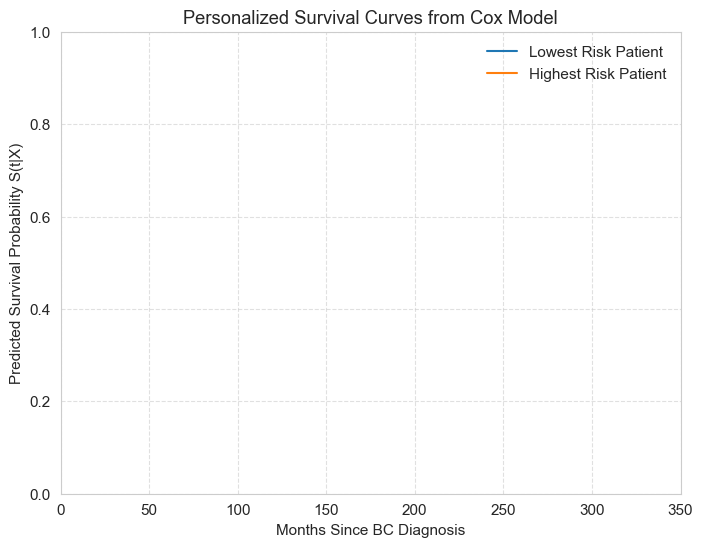


--- Fixed-Horizon Predictions ---



,Low-Risk Survival,Low-Risk Mortality,High-Risk Survival,High-Risk Mortality
50-Month,nan%,nan%,nan%,nan%
100-Month,nan%,nan%,nan%,nan%
120-Month,nan%,nan%,nan%,nan%
180-Month,nan%,nan%,nan%,nan%
240-Month,nan%,nan%,nan%,nan%
300-Month,nan%,nan%,nan%,nan%
350-Month,nan%,nan%,nan%,nan%


In [ ]:
# Requires: X_test_cox, risk_test, cph_multi from the previous cell
# Produces: A plot of survival curves for two example patients and their fixed-horizon survival probabilities

# 1. Find the index for the lowest and highest-risk patients in the TEST set
low_risk_idx  = np.argmin(risk_test)
high_risk_idx = np.argmax(risk_test)
patient_pair_df = X_test_cox.iloc[[low_risk_idx, high_risk_idx]]

print("Feature values for the selected low-risk and high-risk patients:")
display(patient_pair_df)

# 2. Predict the full survival functions for these two patients
# The result is a DataFrame with time-points as the index and patients as columns
survival_functions = cph_model.predict_survival_function(patient_pair_df)

# 3. Plot the personalized survival curves
plt.figure(figsize=(8, 6))
plt.step(survival_functions.index, survival_functions.iloc[:, 0], where="post", label="Lowest Risk Patient")
plt.step(survival_functions.index, survival_functions.iloc[:, 1], where="post", label="Highest Risk Patient")

plt.xlim(0, 350)
plt.ylim(0, 1)
plt.xlabel("Months Since BC Diagnosis")
plt.ylabel("Predicted Survival Probability S(t|X)")
plt.title("Personalized Survival Curves from Cox Model")
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Extract survival probabilities and display them in a formatted table
eval_times = [50.0, 100.0, 120.0, 180.0, 240.0, 300.0, 350.0]
sf_at_times = cph_model.predict_survival_function(patient_pair_df, times=eval_times)

# Create a clean DataFrame for the results
results_df = pd.DataFrame({
    'Low-Risk Patient': sf_at_times.iloc[:, 0].values,
    'High-Risk Patient': sf_at_times.iloc[:, 1].values
}, index=[f"{int(t)}-Month" for t in eval_times])

# Add mortality risk columns
results_df['Low-Risk Mortality'] = 1 - results_df['Low-Risk Patient']
results_df['High-Risk Mortality'] = 1 - results_df['High-Risk Patient']

# Rename survival columns for clarity
results_df.rename(columns={'Low-Risk Patient': 'Low-Risk Survival', 'High-Risk Patient': 'High-Risk Survival'}, inplace=True)

print("\n--- Fixed-Horizon Predictions ---\n")
# Display the styled DataFrame
display(results_df[['Low-Risk Survival', 'Low-Risk Mortality', 'High-Risk Survival', 'High-Risk Mortality']].style.format("{:.2%}").set_caption("Predicted Survival & Mortality Risk"))

### 7.4.2 Time-Dependent Model Performance 

The Concordance (C-index) gives us a single number for model performance over the entire follow-up period. However, in a clinical setting, performance at specific time points is often more important:

*"How well does our model predict the risk of Breast Cancer death at 50, 100, 180, 240, 300, 350, etc months for the set of patients at those times?"*

We are evaluating the cause-specific hazard performance at different points in time. 

In [ ]:
# --- 1. Setup ---
min_time = y_test['duration_os'].min()
max_time = y_test['duration_os'].max()
print(f"Valid time range for evaluation based on the test set: [{min_time:.2f}, {max_time:.2f})")

eval_times = np.array([50.0, 100.0, 120.0, 180.0, 240.0, 300.0, 350.0], dtype=float)
adjusted_eval_times = eval_times[eval_times < max_time]
print(f"Original eval_times: {eval_times}")
print(f"Adjusted eval_times to be used for Brier score: {adjusted_eval_times}")


y_train_surv = Surv.from_arrays(
    event=y_train["event_os"].astype(bool).to_numpy(),
    time=y_train["duration_os"].to_numpy(dtype=float)
)
y_test_surv = Surv.from_arrays(
    event=y_test["event_os"].astype(bool).to_numpy(),
    time=y_test["duration_os"].to_numpy(dtype=float)
)


# --- 2. Time-Dependent AUC (Corrected Logic) ---
def get_auc_at_time(t):
    """
    Robustly calculates AUC at a single time t, handling data insufficiency
    and varied output formats from the scikit-survival library.
    """
    # Check for sufficient data in both train and test sets
    events_train = y_train["event_os"].astype(bool)
    times_train = y_train["duration_os"]
    train_ok = (events_train & (times_train <= t)).any() and (times_train > t).any()
    
    events_test = y_test["event_os"].astype(bool)
    times_test = y_test["duration_os"]
    test_ok = (events_test & (times_test <= t)).any() and (times_test > t).any()
    
    if not (train_ok and test_ok):
        return np.nan
    
    # Calculate AUC
    raw_output = cumulative_dynamic_auc(y_train_surv, y_test_surv, risk_test, [t])
    
    # Handle inconsistent return formats from the library
    # Sometimes it returns a tuple (times, scores), sometimes just scores
    if isinstance(raw_output, tuple):
        auc_scores_array = raw_output[1]
    else:
        auc_scores_array = raw_output
        
    # Ensure the result is a 1D array and return the first (and only) score
    return np.atleast_1d(auc_scores_array)[0]

# Calculate AUC for each time point
auc_scores = [get_auc_at_time(t) for t in adjusted_eval_times]


# --- 3. Brier Score Calculation ---
sf_at_times = cph_model.predict_survival_function(X_test_cox, times=adjusted_eval_times)
survival_prob_matrix = sf_at_times.T.to_numpy()
_, brier_scores = brier_score(y_train_surv, y_test_surv, survival_prob_matrix, adjusted_eval_times)


# --- 4. Assemble and Display Results ---
performance_df = pd.DataFrame({
    "Time Horizon (Months)": adjusted_eval_times.astype(int),
    "Time-Dependent AUC": auc_scores,
    "Brier Score": brier_scores
})

print("\n--- Time-Dependent Model Performance ---\n")
display(performance_df.style.format({
    "Time-Dependent AUC": "{:.3f}",
    "Brier Score": "{:.3f}"
}).hide(axis="index"))

### 7.4.3 Comparing Model with Simple Baseline

A simple baseline model that ignores all patient-specific features. It predicts the same survival probability for every patient, based on the overall survival rate of the training cohort (calculated with a Kaplan-Meier estimator).

By comparing our Cox model to this naive baseline, we can calculate the Brier Skill Score (BSS). This tells us how much better our model is than simply guessing the population average. A positive BSS means our model has learned useful patterns from the patient data.



In [ ]:
# 1. Fit a Kaplan-Meier estimator on the TRAINING data to create the baseline
kmf_baseline = KaplanMeierFitter()
kmf_baseline.fit(y_train["duration_os"], y_train["event_os"])

# 2. Get the baseline survival probability predictions at our evaluation times
# This gives one probability for each time point, which we apply to all test patients
baseline_surv_probs = np.asarray(kmf_baseline.predict(adjusted_eval_times).values)

# 3. Create the prediction matrix required by brier_score
# We repeat the baseline predictions for every patient in the test set
n_test_patients = len(y_test_surv)
baseline_pred_matrix = np.tile(baseline_surv_probs, (n_test_patients, 1))

# 4. Calculate the Brier score for this baseline model
_ , baseline_brier_scores = brier_score(
    y_train_surv, y_test_surv, baseline_pred_matrix, adjusted_eval_times
)

# 5. Calculate the Brier Skill Score (BSS)
# 'brier_scores' is the brier score from our Cox model in the previous cell
brier_skill_scores = 1 - (brier_scores / baseline_brier_scores)

# 6. Display the results in a comparative table
results_df = pd.DataFrame({
    'Cox Model Brier Score': brier_scores,
    'Baseline Brier Score': baseline_brier_scores,
    'Brier Skill Score (BSS)': brier_skill_scores
}, index=[f"{int(t)}-Month" for t in adjusted_eval_times])

print("\n--- Brier Score Comparison ---\n")
display(results_df.style.format("{:.3f}"))

### 7.4.4 Estimating True Absolute Risk with a Competing Risks Model

We now address the competing risk of death directly in our analysis of recurrence. Our goal is to answer more precise and clinically relevant question:

"What is the actual probability that a breast cancer patient will have a recurrence, considering they could pass away from other causes first?"

The Cause-Specific Hazards Method To solve this, we will build two separate Cox models, as a standard/ robust approach:
* The Recurrence Model: Predicts the hazard of cancer recurrence (treating death without recurrence as a censored event).
* The Competing Death Model: Predicts the hazard of death without recurrence (treating recurrence as a censored event).

We will then combine the hazards from both models to calculate the Cumulative Incidence Function (CIF). Finally, we will check how well our model is calibrated by comparing its average predicted risk to the actual observed risk in the test set

In [ ]:
#Competing risks with cause-specific Cox focused on 
EVENT_OF_INTEREST_COL = "event_rfs"  
COMPETING_EVENT_COL = "event_competing_death"

# 0) Ensure we have an explicit discharge indicator
for df_name in ["y_train", "y_val", "y_test"]:
    if df_name in globals():
        df_y = globals()[df_name]
        if 'event_os' not in df_y.columns or 'event_rfs' not in df_y.columns:
             raise KeyError(f"The columns 'event_os' and 'event_rfs' must exist in {df_name}")
        df_y["event_competing_death"] = ((df_y["event_os"] == 1) & (df_y["event_rfs"] == 0)).astype(int)

COMPETING_EVENT_COL = "event_competing_death"
H = np.array([50.0, 100.0, 120.0, 180.0, 240.0, 300.0], dtype=float)  # we still compute all, but   is the focus

# 1) Preprocess features
X_tr = utils.to_dataframe(cox_preprocessor, X_train)
X_te = utils.to_dataframe(cox_preprocessor, X_test)

# 2) Cause-specific training frames
def _cs(X_df, y_df, event_col):
    out = pd.concat(
        [X_df.reset_index(drop=True),
         y_df[["duration_rfs", event_col]].reset_index(drop=True)],
        axis=1
    )
    out["event_for_model"] = (out[event_col] == 1).astype(int)
    return out[["duration_rfs", "event_for_model"] + list(X_df.columns)]

df_tr_recurrence = _cs(X_tr, y_train, EVENT_OF_INTEREST_COL)
df_tr_competing  = _cs(X_tr, y_train, COMPETING_EVENT_COL)

# 3) Fit cause-specific Cox models
cph_recurrence = CoxPHFitter().fit(df_tr_recurrence, "duration_rfs", "event_for_model", show_progress=False)
cph_competing  = CoxPHFitter().fit(df_tr_competing,  "duration_rfs", "event_for_model", show_progress=False)

# 4) Predict patient-level CIF of death on the TEST set
pred_cif_df = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_te, H)  # CIF_7d, CIF_30d, CIF_60d
display(pred_cif_df.round(3).head(10))

# 5) Calibration at 7 days using nonparametric CIF by quartile
calib_60mo_df = utils.check_calibration_competing_risk_at(
    y_true=y_test,
    predictions=pred_cif_df["CIF_60mo"],
    duration_col="duration_rfs",
    event_col=EVENT_OF_INTEREST_COL,
    competing_col=COMPETING_EVENT_COL,
    horizon_days=60.0,
    n_bins=4
).rename(columns={"pred_mean_risk": "pred_mean_risk_60mo", "obs_risk": "obs_risk_60mo"}).round(3)

display(calib_60mo_df)

### 7.4.5 Improving Predictions with Calibration

To recalibrate our model, and ensure further medical usefulness and reliability, we'll use Isotonic Regression.
* Fit isotonic regression on training evaluable patients
* Apply to test predictions
* Show quartile calibration and a familiar sklearn calibration plot

In [ ]:
# Isotonic calibration at 60 months
PRIMARY_HORIZON_MONTHS = 60.0

# 1) Raw 60 m probabilities from the same competing-risk models used above
p_train_raw_60mo = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_tr, np.array([PRIMARY_HORIZON_MONTHS]))[f"CIF_{int(PRIMARY_HORIZON_MONTHS)}mo"]
p_test_raw_60mo  = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_te, np.array([PRIMARY_HORIZON_MONTHS]))[f"CIF_{int(PRIMARY_HORIZON_MONTHS)}mo"]


# 2) Fixed-horizon labels and evaluable masks at 7 d
y_train_temp = y_train.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_test_temp = y_test.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
y_tr_60, eval_tr_60 = utils.get_fixed_horizon_labels(y_train_temp, PRIMARY_HORIZON_MONTHS)
y_te_60, eval_te_60 = utils.get_fixed_horizon_labels(y_test_temp, PRIMARY_HORIZON_MONTHS)

# 3) Fit isotonic on TRAIN evaluable and apply to TEST
iso_60 = IsotonicRegression(out_of_bounds="clip")
iso_60.fit(p_train_raw_60mo[eval_tr_60], y_tr_60[eval_tr_60])

p_test_cal_60mo = pd.Series(iso_60.transform(p_test_raw_60mo), index=p_test_raw_60mo.index, name="p_cal_60mo")

# 4) Calibration by quartile on TEST at 7 d: before vs after vs observed
cal_raw_60 = utils.check_calibration_competing_risk_at(
    y_true=y_test,
    predictions=p_test_raw_60mo,
    duration_col="duration_rfs",
    event_col="event_rfs",
    competing_col="event_competing_death",
    horizon_days=PRIMARY_HORIZON_MONTHS
).rename(columns={"pred_mean_risk": "pred_raw_60mo", "obs_risk": "observed_60mo"})

cal_cal_60 = utils.check_calibration_competing_risk_at(
    y_true=y_test,
    predictions=p_test_cal_60mo,
    duration_col="duration_rfs",
    event_col="event_rfs",
    competing_col="event_competing_death",
    horizon_days=PRIMARY_HORIZON_MONTHS
).rename(columns={"pred_mean_risk": "pred_cal_60mo"})

calibr_table_60mo = (
    cal_raw_60.merge(cal_cal_60[["risk_quartile", "pred_cal_60mo"]], on="risk_quartile")
             .loc[:, ["risk_quartile", "n", "pred_raw_60mo", "pred_cal_60mo", "observed_60mo"]]
             .round(3)
)
display(calibr_table_60mo)
# 5) Brier score on TEST evaluable patients at 7 d: before vs after
brier_60mo_df = pd.DataFrame({
    "Model": [f"Cox-CIF raw {int(PRIMARY_HORIZON_MONTHS)}mo", f"Cox-CIF calibrated {int(PRIMARY_HORIZON_MONTHS)}mo"],
    "Brier Score": [
        brier_score_loss(y_te_60[eval_te_60], p_test_raw_60mo[eval_te_60]),
        brier_score_loss(y_te_60[eval_te_60], p_test_cal_60mo[eval_te_60])
    ],
    "N Test Evaluable": int(eval_te_60.sum())
}).round({"Brier Score": 4})
display(brier_60mo_df)

# 6) Familiar sklearn visualization for evaluable TEST patients at 7 d
utils.plot_calibration_at_horizon(
    y_true_bin=y_te_60,
    y_prob_raw=p_test_raw_60mo.to_numpy(copy=False),
    y_prob_cal=p_test_cal_60mo.to_numpy(copy=False),
    mask=eval_te_60,
    horizon_days=PRIMARY_HORIZON_MONTHS,
    n_bins=8
)

In [ ]:
# Calibration plots at 36 months and 120 months using the utils helper
# Horizons to visualize
H = [36.0, 120.0]

for h in H:
    cph_pred_train = utils.predict_fixed_horizon_risk_from_cox(cph, Xt_train, [7, 30, 60])
    cph_pred_val   = utils.predict_fixed_horizon_risk_from_cox(cph, Xt_val,   [7, 30, 60])
    cph_pred_test  = utils.predict_fixed_horizon_risk_from_cox(cph, Xt_test,  [7, 30, 60])

    # 1) Raw probabilities from the competing-risk Cox models
    p_train_raw_h = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_tr, np.array([h]))[f"CIF_{int(h)}mo"]
    p_test_raw_h  = utils.predict_cif_from_csh(cph_recurrence, cph_competing, X_te, np.array([h]))[f"CIF_{int(h)}mo"]

    # 2) Fixed-horizon labels and evaluable mask
    y_train_temp_h = y_train.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
    y_test_temp_h = y_test.rename(columns={"duration_rfs": "duration_days", "event_rfs": "event_death"})
    y_tr_h, eval_tr_h = utils.get_fixed_horizon_labels(y_train_temp_h, h)
    y_te_h, eval_te_h = utils.get_fixed_horizon_labels(y_test_temp_h,  h)

    labels_train[h] = {"y_true": pd.Series(yb_tr, index=y_train.index).astype(int),
                       "mask":   pd.Series(m_tr,  index=y_train.index).astype(bool)}
    labels_val[h]   = {"y_true": pd.Series(yb_va, index=y_val.index).astype(int),
                       "mask":   pd.Series(m_va, index=y_val.index).astype(bool)}
    labels_test[h]  = {"y_true": pd.Series(yb_te, index=y_test.index).astype(int),
                       "mask":   pd.Series(m_te, index=y_test.index).astype(bool)}

    # 3) Horizon-specific isotonic calibration fitted on TRAIN evaluable patients
    iso_h = IsotonicRegression(out_of_bounds="clip")
    iso_h.fit(p_train_raw_h[eval_tr_h], y_tr_h[eval_tr_h])

    # 4) Plot sklearn-style calibration on TEST evaluable patients
    p_test_cal_h = iso_h.transform(p_test_raw_h)
    utils.plot_calibration_at_horizon(
        y_true_bin=y_te_h,
        y_prob_raw=p_test_raw_h.to_numpy(copy=False),
        y_prob_cal=p_test_cal_h,
        mask=eval_te_h,
        horizon_days=h,
        n_bins=8
    )


# 5) Metrics per horizon on identical evaluable cohorts
for set_name, preds, labels in [
    ("train", cph_pred_train, labels_train),
    ("val",   cph_pred_val,   labels_val),
    ("test",  cph_pred_test,  labels_test),
]:
    for h in [7, 30, 60]:
        col = f"Risk_{h}d"              # use utils naming
        m = labels[h]["mask"]
        y = labels[h]["y_true"][m].to_numpy()
        p = preds[col][m].to_numpy()
        if y.size == 0 or len(np.unique(y)) < 2:
            auroc = np.nan; auprc = np.nan; brier = np.nan
        else:
            auroc = roc_auc_score(y, p)
            auprc = average_precision_score(y, p)
            brier = brier_score_loss(y, p)
        records.append({
            "model": "Cox",
            "set": set_name,
            "horizon_days": h,
            "auroc": float(auroc) if np.isfinite(auroc) else np.nan,
            "auprc": float(auprc) if np.isfinite(auprc) else np.nan,
            "brier": float(brier) if np.isfinite(brier) else np.nan,
            "n_evaluable": int(m.sum())
        })

cph_metrics = pd.DataFrame.from_records(records).sort_values(["set", "horizon_days"])
display(cph_metrics.style)

# Optional compact calibration summaries on test using sklearn-style bins
calib_cph_test = {}
for h in [7, 30, 60]:
    m = labels_test[h]["mask"]
    y = labels_test[h]["y_true"][m].to_numpy()
    p = cph_pred_test[f"Risk_{h}d"][m].to_numpy()
    if y.size == 0 or len(np.unique(y)) < 2:
        calib_cph_test[h] = pd.DataFrame({"prob_mean": [], "event_rate": []})
    else:
        frac_pos, prob_mean = calibration_curve(y, p, n_bins=10, strategy="quantile")
        calib_cph_test[h] = pd.DataFrame({"prob_mean": prob_mean, "event_rate": frac_pos})

# Store artifacts unchanged
ARTIFACTS = {
    "cph_model": cph,
    "cph_pred_train": cph_pred_train,
    "cph_pred_val":   cph_pred_val,
    "cph_pred_test":  cph_pred_test,
    "labels_train": labels_train,
    "labels_val":   labels_val,
    "labels_test":  labels_test,
    "cph_metrics":  cph_metrics,
    "calib_cph_test": calib_cph_test,
    "horizons_days": [7, 30, 60],
}

# 8.0 Model Comparison 

## 8.1 Decision Tree 
While the Cox model looks at the rate of events over time, a Decision Tree works differently. It learns a series of simple "if-then" rules from the data to predict a binary outcome, like "will this patient faces BC recurrence within 60 months?"

In [ ]:
HORIZONS = ARTIFACTS["horizons_days"]
labels_train = ARTIFACTS["labels_train"]
labels_val   = ARTIFACTS["labels_val"]
labels_test  = ARTIFACTS["labels_test"]

# We wrap our already-fitted preprocessor in a FunctionTransformer.
# This prevents the pipeline from trying to re-fit it, which would cause data leakage.
# All models MUST use the exact same preprocessing rules learned only from the original training set.
frozen_pre = FunctionTransformer(lambda X: preprocessor.transform(X))

# Define a simple pipeline and a small grid for hyperparameter tuning.
pipe_tree = Pipeline(steps=[
    ("pre", frozen_pre),
    ("clf", DecisionTreeClassifier(random_state=SEED, class_weight="balanced"))
])

# These are the "knobs" we'll turn to find the best, simplest tree.
param_grid = {
    "clf__max_depth": [3, 4, 5, 6],
    "clf__min_samples_leaf": [25, 50, 100]
}

# Containers for predictions and metrics
dt_pred_train = pd.DataFrame(index=X_train.index)
dt_pred_val   = pd.DataFrame(index=X_val.index)
dt_pred_test  = pd.DataFrame(index=X_test.index)
rows = []

print("Training Decision Tree for each horizon...")
for h in HORIZONS:
    # Get the correct labels and masks for this specific horizon
    m_tr = labels_train[h]["mask"]
    m_va = labels_val[h]["mask"]
    m_te = labels_test[h]["mask"]

    y_tr = labels_train[h]["y_true"][m_tr].to_numpy()
    y_va = labels_val[h]["y_true"][m_va].to_numpy()
    y_te = labels_test[h]["y_true"][m_te].to_numpy()

    # We fit the grid search ONLY on the patients who are "evaluable" for this horizon.
    # This ensures the model learns from the most relevant data.
    grid = GridSearchCV(
        estimator=pipe_tree,
        param_grid=param_grid,
        scoring="roc_auc", # We'll judge the best tree based on its ranking ability
        cv=3,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    grid.fit(X_train.loc[m_tr], y_tr)

    # Store a compact view of the chosen hyperparameters
    best_params = grid.best_params_
    print(f"Horizon {h}d best params: {best_params}")

    # Predict probabilities for ALL patients using the best model found
    p_tr = grid.predict_proba(X_train)[:, 1]
    p_va = grid.predict_proba(X_val)[:, 1]
    p_te = grid.predict_proba(X_test)[:, 1]

    colname = f"DT_Risk_{h}d"
    dt_pred_train[colname] = p_tr
    dt_pred_val[colname]   = p_va
    dt_pred_test[colname]  = p_te

    # Helper to calculate metrics safely on the evaluable cohorts
    def _safe_metrics(y, p):
        if y.size == 0 or len(np.unique(y)) < 2:
            return np.nan, np.nan, np.nan
        return roc_auc_score(y, p), average_precision_score(y, p), brier_score_loss(y, p)

    au_tr, ap_tr, br_tr = _safe_metrics(y_tr, p_tr[m_tr])
    au_va, ap_va, br_va = _safe_metrics(y_va, p_va[m_va])
    au_te, ap_te, br_te = _safe_metrics(y_te, p_te[m_te])

    rows += [
        {"model": "DecisionTree", "set": "train", "horizon_days": h,
         "auroc": au_tr, "auprc": ap_tr, "brier": br_tr, "n_evaluable": int(m_tr.sum()),
         "best_max_depth": best_params["clf__max_depth"], "best_min_samples_leaf": best_params["clf__min_samples_leaf"]},
        {"model": "DecisionTree", "set": "val",   "horizon_days": h,
         "auroc": au_va, "auprc": ap_va, "brier": br_va, "n_evaluable": int(m_va.sum()),
         "best_max_depth": best_params["clf__max_depth"], "best_min_samples_leaf": best_params["clf__min_samples_leaf"]},
        {"model": "DecisionTree", "set": "test",  "horizon_days": h,
         "auroc": au_te, "auprc": ap_te, "brier": br_te, "n_evaluable": int(m_te.sum()),
         "best_max_depth": best_params["clf__max_depth"], "best_min_samples_leaf": best_params["clf__min_samples_leaf"]},
    ]

# Tidy metrics table for the tree
dt_metrics = pd.DataFrame(rows).sort_values(["set", "horizon_days"]).reset_index(drop=True)

# Round for readability
for c in ["auroc", "auprc", "brier"]:
    dt_metrics[c] = pd.to_numeric(dt_metrics[c], errors="coerce").round(3)

order_sets = pd.CategoricalDtype(["train", "val", "test"], ordered=True)
dt_metrics["set"] = dt_metrics["set"].astype(order_sets)

display(dt_metrics.style)

# Persist into ARTIFACTS for later side-by-side plots and tables
ARTIFACTS["dt_model_cv"] = "per-horizon GridSearchCV objects not stored to keep memory light"
ARTIFACTS["dt_pred_train"] = dt_pred_train
ARTIFACTS["dt_pred_val"]   = dt_pred_val
ARTIFACTS["dt_pred_test"]  = dt_pred_test
ARTIFACTS["dt_metrics"]    = dt_metrics

### 8.1.1 Predicting Risk at 60 month Horizon

In [ ]:

HORIZON = 7 # Focus on the 7-day model

# Get the best parameters from our previous results
best_params_row = ARTIFACTS["dt_metrics"].query("set == 'val' and horizon_days == @HORIZON").iloc[0]
best_depth = int(best_params_row["best_max_depth"])
best_leaf_samples = int(best_params_row["best_min_samples_leaf"])

print(f"Refitting 7-day tree with max_depth={best_depth} and min_samples_leaf={best_leaf_samples}\\n")

# Get the correct "evaluable" data for this horizon
mask_train = ARTIFACTS["labels_train"][HORIZON]["mask"]
y_train_h = ARTIFACTS["labels_train"][HORIZON]["y_true"][mask_train].to_numpy()

# Use the already preprocessed data
Xt_train_h = Xt_train.loc[mask_train]

# Fit the final Decision Tree model
final_tree = DecisionTreeClassifier(
    random_state=SEED,
    class_weight="balanced", # Helps the model pay attention to the rare "death" event
    max_depth=best_depth,
    min_samples_leaf=best_leaf_samples
)
final_tree.fit(Xt_train_h, y_train_h)

# --- Step 2: Plot the tree to visualize the rules ---
plt.figure(figsize=(18, 10))
plot_tree(
    final_tree,
    feature_names=Xt_train_h.columns.tolist(),
    class_names=["Survived", "Died"], # Label for clarity
    filled=True,       # Color nodes by majority class
    impurity=False,    # Hide Gini impurity for a cleaner look
    proportion=True,   # Show percentage of samples in each class
    rounded=True,      # Use rounded boxes
    fontsize=10
)
plt.title(f"Decision Tree Rules for {HORIZON}-Day In-Hospital Death", fontsize=16)
plt.show()

# --- Step 3: Export the same rules as text ---
# This can be useful for documentation.
rules_text = export_text(final_tree, feature_names=list(Xt_train_h.columns))
print("--- Decision Rules as Text ---\\n")
print(rules_text)

In [ ]:
# --- Step 4: Feature Importance (which variables did the tree use?) ---

# The default 'Gini importance' measures how much a feature helps to create "pure" nodes.
feature_importances = pd.DataFrame({
    "feature": Xt_train_h.columns,
    "importance": final_tree.feature_importances_
}).sort_values("importance", ascending=False).head(15)

print("--- Top 15 Features (Gini Importance) ---")
display(feature_importances.style)


# --- Step 5: Auditing the tree's rules (leaves) on the test set ---
# This is the most critical step: do the rules that predict high risk actually
# correspond to groups of patients with high death rates in the unseen test data?

# Get the correct "evaluable" test data for this horizon
mask_test = ARTIFACTS["labels_test"][HORIZON]["mask"]
y_test_h = ARTIFACTS["labels_test"][HORIZON]["y_true"][mask_test].to_numpy()
Xt_test_h = Xt_test.loc[mask_test]

# Find out which leaf each test patient ends up in
leaf_ids_test = final_tree.apply(Xt_test_h)
# Get the predicted probability for each test patient
probabilities_test = final_tree.predict_proba(Xt_test_h)[:, 1]

# Create a summary table
leaf_audit_df = pd.DataFrame({
    "leaf_id": leaf_ids_test,
    "true_outcome": y_test_h,
    "predicted_risk": probabilities_test
})

leaf_summary = (
    leaf_audit_df
    .groupby("leaf_id")
    .agg(
        num_patients=("true_outcome", "size"),
        observed_death_rate=("true_outcome", "mean"),
        avg_predicted_risk=("predicted_risk", "mean")
    )
    .sort_values("avg_predicted_risk", ascending=False)
)

print("\\n--- Leaf Performance Audit on Test Set ---")
display(leaf_summary.style)

### 8.1.2 Partial Dependence of Predicted Risk at 60 Month Horizon

In [ ]:
H = 7  # horizon to visualize

# 1) Recreate the evaluable training slice and labels
m_tr = ARTIFACTS["labels_train"][H]["mask"]
Xtr_t = Xt_train.loc[m_tr]
y_tr  = ARTIFACTS["labels_train"][H]["y_true"][m_tr].to_numpy()

# 2) Pull the best hyperparameters we selected for this horizon
best_row  = ARTIFACTS["dt_metrics"].query("set == 'val' and horizon_days == @H").iloc[0]
best_depth = int(best_row["best_max_depth"])
best_leaf  = int(best_row["best_min_samples_leaf"])

# 3) Fit the shallow tree on the same transformed data
dt = DecisionTreeClassifier(
    random_state=SEED,
    class_weight="balanced",
    max_depth=best_depth,
    min_samples_leaf=best_leaf
).fit(Xtr_t, y_tr)

# 4) Pick features the tree actually used (nonzero importance) and prefer continuous ones
imp = pd.Series(dt.feature_importances_, index=Xtr_t.columns)
used = imp[imp > 0].sort_values(ascending=False).index.tolist()

# Heuristic: continuous features created by the preprocessor often start with "num__"
cont_used = [f for f in used if f.startswith("num__")]
targets = cont_used[:3] if len(cont_used) > 0 else used[:3]

if len(targets) == 0:
    print("No features with nonzero importance were found for PDP")
else:
    print("Plotting PDP for:", targets)
    PartialDependenceDisplay.from_estimator(
        dt, Xtr_t, targets, kind="average", grid_resolution=50
    )
    plt.suptitle(f"Partial Dependence of Predicted Risk at {H}-Day Horizon")
    plt.show()

## 8.2 Random Forest at Fixed Horizons

In [ ]:
# Horizons and labels from our central ARTIFACTS store
HORIZONS = ARTIFACTS["horizons_days"]
labels_train = ARTIFACTS["labels_train"]
labels_val   = ARTIFACTS["labels_val"]
labels_test  = ARTIFACTS["labels_test"]

# Use the same frozen preprocessor to prevent data leakage
frozen_pre = FunctionTransformer(lambda X: preprocessor.transform(X))

# --- Define the Pipeline and Search Grid ---
pipe_rf = Pipeline(steps=[
    ("pre", frozen_pre),
    ("clf", RandomForestClassifier(
        random_state=SEED,
        # 'balanced_subsample' adjusts weights for the minority class in each bootstrap sample.
        # This is a robust way to handle the low death rate in our data.
        class_weight="balanced_subsample",
        n_jobs=-1 # Use all available CPU cores for faster training
    ))
])

# A small, practical grid for hyperparameter tuning
param_grid = {
    "clf__n_estimators": [100, 200],      # How many trees in the forest
    "clf__max_depth": [4, 6, 8],          # Max depth of each tree
    "clf__min_samples_leaf": [25, 50]   # Min patients in a final leaf
}

# --- Containers for predictions and metrics ---
rf_pred_train = pd.DataFrame(index=X_train.index)
rf_pred_val   = pd.DataFrame(index=X_val.index)
rf_pred_test  = pd.DataFrame(index=X_test.index)
records = []

print("Training Random Forest for each horizon...")
for h in HORIZONS:
    # Get the correct evaluable cohorts for this horizon
    m_tr = labels_train[h]["mask"]
    m_va = labels_val[h]["mask"]
    m_te = labels_test[h]["mask"]

    y_tr = labels_train[h]["y_true"][m_tr].to_numpy()
    y_va = labels_val[h]["y_true"][m_va].to_numpy()
    y_te = labels_test[h]["y_true"][m_te].to_numpy()

    # Fit GridSearchCV only on the evaluable training data for this horizon
    grid = GridSearchCV(
        estimator=pipe_rf,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train.loc[m_tr], y_tr)

    best_params = grid.best_params_
    print(f"Horizon {h}d best params: {best_params}")

    # Get predictions from the best model
    p_tr = grid.predict_proba(X_train)[:, 1]
    p_va = grid.predict_proba(X_val)[:, 1]
    p_te = grid.predict_proba(X_test)[:, 1]

    # Store predictions
    colname = f"RF_Risk_{h}d"
    rf_pred_train[colname] = p_tr
    rf_pred_val[colname]   = p_va
    rf_pred_test[colname]  = p_te

    # Calculate metrics on the identical evaluable cohorts
    def _safe_metrics(y, p):
        if y.size == 0 or len(np.unique(y)) < 2:
            return np.nan, np.nan, np.nan
        return roc_auc_score(y, p), average_precision_score(y, p), brier_score_loss(y, p)

    au_tr, ap_tr, br_tr = _safe_metrics(y_tr, p_tr[m_tr])
    au_va, ap_va, br_va = _safe_metrics(y_va, p_va[m_va])
    au_te, ap_te, br_te = _safe_metrics(y_te, p_te[m_te])

    # Append results for all sets to our records list
    for s, au, ap, br, mask in [
        ("train", au_tr, ap_tr, br_tr, m_tr),
        ("val",   au_va, ap_va, br_va, m_va),
        ("test",  au_te, ap_te, br_te, m_te),
    ]:
        records.append({
            "model": "RandomForest",
            "set": s,
            "horizon_days": h,
            "auroc": float(au),
            "auprc": float(ap),
            "brier": float(br),
            "n_evaluable": int(mask.sum()),
            "best_n_estimators": best_params["clf__n_estimators"],
            "best_max_depth": best_params["clf__max_depth"],
            "best_min_samples_leaf": best_params["clf__min_samples_leaf"]
        })

# --- Create and display the final metrics table ---
rf_metrics = pd.DataFrame.from_records(records).sort_values(["set", "horizon_days"]).reset_index(drop=True)
for c in ["auroc", "auprc", "brier"]:
    rf_metrics[c] = pd.to_numeric(rf_metrics[c], errors="coerce").round(3)

order_sets = pd.CategoricalDtype(["train", "val", "test"], ordered=True)
rf_metrics["set"] = rf_metrics["set"].astype(order_sets)

display(rf_metrics.style)

# --- Store results for our final comparison ---
ARTIFACTS["rf_pred_train"] = rf_pred_train
ARTIFACTS["rf_pred_val"]   = rf_pred_val
ARTIFACTS["rf_pred_test"]  = rf_pred_test
ARTIFACTS["rf_metrics"]    = rf_metrics

In [ ]:
# Top 6 features by impurity importance as a bar chart

# Use the fitted random forest for the 7-day horizon from the grid search
# This is the best estimator from the grid search for H=7
H = 7
m_tr = ARTIFACTS["labels_train"][H]["mask"]
Xtr_t = Xt_train.loc[m_tr]
y_tr = ARTIFACTS["labels_train"][H]["y_true"][m_tr].to_numpy()

# Refit the random forest for the 7-day horizon using the best hyperparameters
best_row = ARTIFACTS["rf_metrics"].query("set == 'test' and horizon_days == @H").iloc[0]
rf = RandomForestClassifier(
    random_state=SEED,
    class_weight="balanced_subsample",
    n_estimators=int(best_row["best_n_estimators"]),
    max_depth=int(best_row["best_max_depth"]),
    min_samples_leaf=int(best_row["best_min_samples_leaf"]),
    n_jobs=-1
)
rf.fit(Xtr_t, y_tr)

imp_series = pd.Series(rf.feature_importances_, index=Xtr_t.columns).sort_values(ascending=False).head(6)
feat_names = [f if len(f) <= 28 else f[:25] + "..." for f in imp_series.index]

plt.figure(figsize=(8, 4))
ypos = np.arange(len(imp_series))
plt.barh(ypos, imp_series.values)
plt.gca().invert_yaxis()
plt.yticks(ypos, feat_names)
for i, v in enumerate(imp_series.values):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center")
plt.xlabel("Impurity importance")
plt.title(f"Random Forest top 6 features by impurity importance at {H} days")
plt.tight_layout()
plt.show()

In [ ]:
# Use the correct validation transformed features and evaluable mask for the 7-day horizon
H = 7
m_va = ARTIFACTS["labels_val"][H]["mask"]
y_va = ARTIFACTS["labels_val"][H]["y_true"][m_va].to_numpy()
Xva_t = Xt_val.loc[m_va].reindex(columns=Xtr_t.columns, fill_value=0)

# Pick top 6 features by impurity importance for plotting
top_feats = (
    pd.Series(rf.feature_importances_, index=Xtr_t.columns)
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

# Compute ΔAUROC per feature by shuffling that column n_repeats times
def permutation_deltas(estimator, X, y, features, n_repeats=30, seed=SEED):
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, estimator.predict_proba(X)[:, 1])
    deltas = []
    for f in features:
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[f] = Xp[f].sample(frac=1.0, random_state=int(rng.integers(1 << 31))).to_numpy()
            score = roc_auc_score(y, estimator.predict_proba(Xp)[:, 1])
            drops.append(base - score)  # positive means AUROC dropped when f was shuffled
        deltas.append(np.array(drops))
    return deltas

box_data = permutation_deltas(rf, Xva_t, y_va, top_feats, n_repeats=30, seed=SEED)
labels = [f if len(f) <= 28 else f[:25] + "..." for f in top_feats]

plt.figure(figsize=(8, 4))
plt.boxplot(box_data, vert=True, labels=labels, manage_ticks=True)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Δ AUROC when permuted")
plt.title(f"Permutation importance distribution at {H} days")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()